# A Universal Qudit Quantum Processor with Trapped Ions

**Reproducing:** M. Ringbauer, M. Meth, L. Postler, R. Stricker, R. Blatt, P. Schindler, T. Monz,
*"A universal qudit quantum processor with trapped ions"*, [arXiv:2109.06903v1](https://arxiv.org/abs/2109.06903) (2021).

---

## 0.1 Aim and approach

The aim of this notebook is to reconstruct the Innsbruck trapped-ion qudit processor from first
principles and then use it for a small application. Rather than reading the paper passively, the
processor is rebuilt in code and its behaviour is checked against the paper's own numbers. Everything
is built on `qiskit.quantum_info`, which — unlike `QuantumCircuit` — works in any dimension and can
therefore serve as a genuine qutrit/ququint simulator. Once the processor is reconstructed, it is
applied to the task the paper names as its motivation:

> *"This will particularly benefit applications that are natively formulated in terms of higher spin
> models, such as quantum chemistry and quantum simulation of lattice gauge theories."*

The lattice gauge theory that is *already* a spin model is the **Quantum Link Model (QLM)** of
Chandrasekharan and Wiese, in which the usual infinite-dimensional gauge link is replaced by a finite
spin-$S$ representation. For $S=1$ the link is a **three-level system — a qutrit**, so the match to
the hardware is dimensional rather than an encoding choice. Section 8 develops this.

### Quantities checked against the paper

| Paper object | Section | Paper value |
|---|---|---|
| Fig. 1 level scheme, $\Delta m=0,\pm1,\pm2$ selection rules, 10 allowed transitions | §2 | 10 transitions |
| Eq. (3) Gell-Mann algebra + three $SU(2)$ subalgebras | §1 | — |
| Eqs. (4)–(8) generalised Pauli / Clifford / $T_3$ gates | §1 | — |
| Algorithm 1: $SU(d)\to$ two-level rotations, $O(d^2)$ | §3 | $\sim$10 pulses ($d{=}3$) |
| Table SI: single-qutrit process fidelities via SDP tomography | §4 | $\mathcal F = 0.945$–$0.994$ |
| Fig. 2: qutrit / ququint randomized benchmarking | §5 | $2(2)\cdot10^{-3}$, $1.0(2)\cdot10^{-2}$ |
| Fig. S6/S7/S8: phase-compensated MS, Cex, Cinc synthesis | §6 | 2, $2(d{-}1)$ MS($\pi/2$) equiv. |
| Fig. 3: Cinc truth table, Cex/Cinc fidelity decay | §6 | $\mathcal F = 97.5\%,\ 93.8\%$ |
| Eq. (S2) / Fig. S4: AC-Stark shifts in a ququart | §7 | — |
| Fig. 4c: readout error optimum | §7 | $3\cdot10^{-3}$ at $500\,\mu$s |
| **QLM real-time dynamics on the reconstructed hardware** | §8–9 | *new* |

### What is modelled rather than reproduced

The paper *measures* its error rates, which cannot be re-measured here. The approach taken is the
inverse: the paper's *microscopic* numbers (error per laser pulse, per MS gate, the lifetime
$\tau_1$, the coherence time) are used as **inputs**, propagated through independently reconstructed
gate decompositions, and the paper's *aggregate* results (error per Clifford, Cex/Cinc fidelities,
the readout optimum) are checked to fall out. Agreement is then a consistency test of both the paper
and the reconstruction. Every point of disagreement with the paper is stated explicitly rather than
adjusted away.

### Conventions used throughout
* Qudit levels are labelled $|0\rangle\dots|d-1\rangle$ following Fig. 1.
* Subsystem ordering follows Qiskit's little-endian convention: `qargs[0]` is the least-significant
  tensor factor. All helpers are unit-tested in §2.4, since this is a common source of silent error.
* All random seeds are fixed, so the notebook is reproducible.

In [1]:
import numpy as np
import scipy.linalg as sla
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import combinations, product
from functools import reduce
import warnings, time, json, sys

from qiskit.quantum_info import (Operator, Statevector, DensityMatrix, Choi, SuperOp,
                                 Kraus, process_fidelity, average_gate_fidelity)
import qiskit

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True, linewidth=160)

# --- global plotting style -------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": ":",
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.facecolor": "white",
})
C = {"qutrit": "#2E5EAA", "ququint": "#E07B39", "ideal": "#1a1a1a",
     "paper": "#B5323C", "aux": "#4C9F70", "grey": "#8A8A8A"}

SEED = 20210914          # arXiv posting date of the paper: 14 Sep 2021
rng_global = np.random.default_rng(SEED)

print(f"qiskit  {qiskit.__version__}")
print(f"numpy   {np.__version__}")
import scipy; print(f"scipy   {scipy.__version__}")
print(f"master seed = {SEED}")

qiskit  2.5.0
numpy   2.4.4
scipy   1.17.1
master seed = 20210914


---
# 1. Qudit algebra: from $SU(2)$ to $SU(d)$

## 1.1 Why the algebra is worth establishing first

A qubit gate set is universal because $\{\sigma_x,\sigma_y,\sigma_z\}$ generate $\mathfrak{su}(2)$
and any $SU(2)$ element is reachable. For a qudit the local group is $SU(d)$, whose algebra
$\mathfrak{su}(d)$ has $d^2-1$ generators. The key physical observation of the paper (just below
Eq. 3) is that **the hardware does not provide $\mathfrak{su}(d)$ directly** — a single 729 nm laser
pulse drives *one* $S\!-\!D$ transition, so it generates rotations only inside a **two-level
subalgebra**.

For $d=3$ the paper notes that the eight Gell-Mann matrices contain three independent
$\mathfrak{su}(2)$ sub-algebras,

$$\{\lambda_1,\lambda_2,\lambda_3\},\qquad
\{\lambda_4,\lambda_5,\tfrac{\lambda_3+\sqrt3\lambda_8}{2}\},\qquad
\{\lambda_6,\lambda_7,\tfrac{-\lambda_3+\sqrt3\lambda_8}{2}\},$$

one for each pair of levels $(0,1)$, $(0,2)$, $(1,2)$. **This is the algebraic expression of the
physical fact that the processor is built from two-level laser transitions.** The relation is checked
numerically below, because everything downstream (Algorithm 1, the Cex/Cinc synthesis, the QLM
compilation) follows from it.

## 1.2 Generalised Gell-Mann basis in arbitrary $d$

For general $d$ the natural traceless Hermitian basis is the *generalised Gell-Mann* set:
$d(d-1)/2$ symmetric, $d(d-1)/2$ antisymmetric, and $d-1$ diagonal generators,

$$\Lambda^{\rm sym}_{jk}=|j\rangle\langle k|+|k\rangle\langle j|,\qquad
\Lambda^{\rm asym}_{jk}=-i|j\rangle\langle k|+i|k\rangle\langle j|,$$
$$\Lambda^{\rm diag}_{l}=\sqrt{\tfrac{2}{l(l+1)}}\Big(\sum_{j=0}^{l-1}|j\rangle\langle j|-l\,|l\rangle\langle l|\Big),$$

normalised so that $\mathrm{Tr}[\Lambda_i\Lambda_j]=2\delta_{ij}$, which is the paper's convention.

In [2]:
def gell_mann(d):
    """Generalised Gell-Mann matrices for SU(d), ordered exactly as Eq. (3) of the paper for d=3.

    Ordering: for each pair (j<k) in the paper's order, the symmetric then the antisymmetric
    generator; the diagonal generator lambda_{l^2+2l} is inserted at its Gell-Mann position.
    Returns a list of d^2-1 Hermitian matrices with Tr[L_i L_j] = 2 delta_ij.
    """
    mats = []
    # Standard Gell-Mann ordering: iterate l = 1..d-1; for each l, the 2l off-diagonal
    # generators coupling level l to levels 0..l-1, then the diagonal generator.
    for l in range(1, d):
        for j in range(l):
            S = np.zeros((d, d), complex); S[j, l] = 1; S[l, j] = 1
            A = np.zeros((d, d), complex); A[j, l] = -1j; A[l, j] = 1j
            mats += [S, A]
        D = np.zeros((d, d), complex)
        for j in range(l):
            D[j, j] = 1
        D[l, l] = -l
        mats.append(np.sqrt(2.0 / (l * (l + 1))) * D)
    return mats

LAM3 = gell_mann(3)

# --- verification 1: orthonormality Tr[L_i L_j] = 2 delta_ij ---------------
G = np.array([[np.trace(a @ b).real for b in LAM3] for a in LAM3])
print("Tr[lambda_i lambda_j] / 2  ==  identity :", np.allclose(G, 2*np.eye(8)))

# --- verification 2: match the explicit matrices of Eq. (3) ---------------
eq3 = {}
eq3[1] = np.array([[0,1,0],[1,0,0],[0,0,0]], complex)
eq3[2] = np.array([[0,-1j,0],[1j,0,0],[0,0,0]])
eq3[3] = np.array([[1,0,0],[0,-1,0],[0,0,0]], complex)
eq3[4] = np.array([[0,0,1],[0,0,0],[1,0,0]], complex)
eq3[5] = np.array([[0,0,-1j],[0,0,0],[1j,0,0]])
eq3[6] = np.array([[0,0,0],[0,0,1],[0,1,0]], complex)
eq3[7] = np.array([[0,0,0],[0,0,-1j],[0,1j,0]])
eq3[8] = np.array([[1,0,0],[0,1,0],[0,0,-2]], complex)/np.sqrt(3)
ok = all(np.allclose(LAM3[i-1], eq3[i]) for i in range(1, 9))
print("generated basis reproduces Eq. (3) exactly       :", ok)

# --- verification 3: the three su(2) subalgebras below Eq. (3) -------------
def closes_su2(a, b, c, tol=1e-10):
    """Check [a,b]=2i c and cyclic permutations -> {a,b,c}/2 is an su(2) triple."""
    comm = lambda X, Y: X @ Y - Y @ X
    return (np.allclose(comm(a, b), 2j*c, atol=tol) and
            np.allclose(comm(b, c), 2j*a, atol=tol) and
            np.allclose(comm(c, a), 2j*b, atol=tol))

L = {i+1: LAM3[i] for i in range(8)}
sub = {
    "levels (0,1): {l1, l2, l3}"                    : (L[1], L[2],  L[3]),
    "levels (0,2): {l4, l5, (l3+sqrt3 l8)/2}"       : (L[4], L[5],  (L[3] + np.sqrt(3)*L[8])/2),
    "levels (1,2): {l6, l7, (-l3+sqrt3 l8)/2}"      : (L[6], L[7], (-L[3] + np.sqrt(3)*L[8])/2),
}
for name, t in sub.items():
    print(f"  {name:44s} closes su(2): {closes_su2(*t)}")

Tr[lambda_i lambda_j] / 2  ==  identity : True
generated basis reproduces Eq. (3) exactly       : True
  levels (0,1): {l1, l2, l3}                   closes su(2): True
  levels (0,2): {l4, l5, (l3+sqrt3 l8)/2}      closes su(2): True
  levels (1,2): {l6, l7, (-l3+sqrt3 l8)/2}     closes su(2): True


### Reading the output

All three checks return `True`.

* **Check 1** confirms the normalisation $\mathrm{Tr}[\lambda_i\lambda_j]=2\delta_{ij}$ stated above
  Eq. (3). This is what makes the $\lambda_i$ a genuine generalisation of the Pauli matrices — for
  $d=2$ the construction returns exactly $\sigma_x,\sigma_y,\sigma_z$.
* **Check 2** confirms that the general-$d$ constructor, specialised to $d=3$, reproduces the paper's
  eight matrices element by element, so the objects built later for $d=5,7$ stand on the same footing
  as the paper's $d=3$ case.
* **Check 3** is the physically important one. Each triple satisfies $[\lambda_a,\lambda_b]=2i\lambda_c$,
  so the three sub-algebras are genuine $\mathfrak{su}(2)$'s attached to the three level *pairs*. The
  third member of the second and third triples is a *linear combination* of $\lambda_3$ and
  $\lambda_8$, which is why the diagonal (phase) sector is where qudit control genuinely differs from
  qubit control. This is the origin of the "lost global-phase gauge freedom" the paper warns about
  below Eq. (8), and it is revisited in §3.

## 1.3 The generalised Pauli, Clifford, and $T$ gates — Eqs. (4)–(8)

$$Z_d=\sum_j\omega_d^{\,j}|j\rangle\langle j|,\qquad
X_d=\sum_j|j{+}1 \bmod d\rangle\langle j|,\qquad \omega_d=e^{2\pi i/d}$$

$$H_d=\frac{1}{\sqrt d}\sum_{j,k}\omega_d^{\,jk}|k\rangle\langle j|,\qquad
S_d=\sum_j\omega_d^{\,j(j+1)/2}|j\rangle\langle j|,\qquad
T_3=\mathrm{diag}(1,e^{2\pi i/9},e^{-2\pi i/9})$$

The defining property of the Clifford group is that it maps the generalised Pauli group to itself
under conjugation, $C P C^\dagger \in \mathcal P_d$ up to a phase. The $T_3$ gate of Eq. (8) (Howard
& Vala) is expected to **fail** this test, and that failure is precisely what makes the gate set
universal rather than classically simulable via Gottesman–Knill. Both are tested below.

In [3]:
def Xd(d):
    M = np.zeros((d, d), complex)
    for j in range(d):
        M[(j + 1) % d, j] = 1.0
    return M

def Zd(d):
    w = np.exp(2j*np.pi/d)
    return np.diag([w**j for j in range(d)])

def Hd(d):
    w = np.exp(2j*np.pi/d)
    return np.array([[w**(j*k) for j in range(d)] for k in range(d)], complex)/np.sqrt(d)

def Sd(d):
    w = np.exp(2j*np.pi/d)
    # For odd d, omega^{j(j+1)/2} is single valued; for even d use omega^{j^2/2} convention.
    return np.diag([w**((j*(j+1)//2) % d) if (j*(j+1)) % 2 == 0 else w**(j*(j+1)/2)
                    for j in range(d)])

T3 = np.diag([1.0, np.exp(2j*np.pi/9), np.exp(-2j*np.pi/9)])

def pauli_group_reps(d):
    """Representatives X^a Z^b of the generalised Pauli group modulo phases."""
    X, Z = Xd(d), Zd(d)
    return {(a, b): np.linalg.matrix_power(X, a) @ np.linalg.matrix_power(Z, b)
            for a in range(d) for b in range(d)}

def canon(M, tol=1e-9):
    """Canonical representative of M modulo a global phase (for hashing / comparison)."""
    flat = M.reshape(-1)
    idx = np.argmax(np.abs(flat) > tol)
    return M * np.exp(-1j*np.angle(flat[idx]))

def is_clifford(C, d, tol=1e-8):
    """True iff C P C^dagger lies in the generalised Pauli group (up to phase) for all P."""
    P = pauli_group_reps(d)
    lib = {tuple(np.round(canon(v).reshape(-1), 6)) for v in P.values()}
    for v in P.values():
        img = canon(C @ v @ C.conj().T)
        if tuple(np.round(img.reshape(-1), 6)) not in lib:
            return False
    return True

d = 3
print("Unitarity checks (d=3):")
for nm, M in [("X_3", Xd(3)), ("Z_3", Zd(3)), ("H_3", Hd(3)), ("S_3", Sd(3)), ("T_3", T3)]:
    print(f"  {nm}: unitary={np.allclose(M @ M.conj().T, np.eye(3))}, "
          f"det={np.linalg.det(M):+.4f}")

print("\nAlgebraic relations:")
print(f"  X_3^3 = I                       : {np.allclose(np.linalg.matrix_power(Xd(3),3), np.eye(3))}")
print(f"  Z_3 X_3 = w X_3 Z_3             : "
      f"{np.allclose(Zd(3)@Xd(3), np.exp(2j*np.pi/3)*Xd(3)@Zd(3))}")
print(f"  H_3 X_3 H_3^dag ~ Z_3           : "
      f"{np.allclose(canon(Hd(3)@Xd(3)@Hd(3).conj().T), canon(Zd(3)))}")

print("\nClifford membership (Eq. 4-8):")
for nm, M in [("X_3", Xd(3)), ("Z_3", Zd(3)), ("H_3", Hd(3)), ("S_3", Sd(3)), ("T_3", T3)]:
    print(f"  {nm:4s} Clifford: {is_clifford(M, 3)}")

Unitarity checks (d=3):
  X_3: unitary=True, det=+1.0000+0.0000j
  Z_3: unitary=True, det=+1.0000-0.0000j
  H_3: unitary=True, det=-0.0000-1.0000j
  S_3: unitary=True, det=-0.5000+0.8660j
  T_3: unitary=True, det=+1.0000+0.0000j

Algebraic relations:
  X_3^3 = I                       : True
  Z_3 X_3 = w X_3 Z_3             : True
  H_3 X_3 H_3^dag ~ Z_3           : True

Clifford membership (Eq. 4-8):
  X_3  Clifford: True
  Z_3  Clifford: True
  H_3  Clifford: True
  S_3  Clifford: True
  T_3  Clifford: False


### Reading the output

* $X_3^3=\mathbb 1$ and the Weyl commutation relation $Z_dX_d=\omega_d X_dZ_d$ hold — the defining
  relations of the generalised Pauli (Heisenberg–Weyl) group of Eqs. (4)–(5).
* $H_3$ conjugates $X_3\to Z_3$, the qudit Fourier/Hadamard action.
* $X_3, Z_3, H_3, S_3$ all return `Clifford: True`, and **$T_3$ returns `False`**. This is the
  numerical statement that Eq. (8) supplies the non-Clifford resource. Together, $\{H_3,S_3,T_3\}$
  plus one entangling gate is universal for qutrit computation — the gate set the paper implements and
  characterises in Table SI, reconstructed in §4.

A note on $S_d$: for **even** $d$ the exponent $j(j+1)/2$ is half-integral and $\omega_d^{j(j+1)/2}$
requires a branch choice. The implementation handles this, but the paper only uses odd $d$ ($d=3$)
for the Clifford$+T$ demonstration, where no ambiguity arises. Odd prime $d$ is also where the qudit
Clifford group has the clean order $d^3(d^2-1)$ used in §5.

---
# 2. Reconstructing the $^{40}\mathrm{Ca}^{+}$ hardware

## 2.1 The level scheme (Fig. 1) and the selection rules

Quantum information lives in the $S_{1/2}$ ground state and the metastable $D_{5/2}$ state
($\tau_1\simeq1.1\,$s). A $\sim4\,$G magnetic field splits these into Zeeman sublevels:

* $S_{1/2}$ into **2** levels, $m=\pm\tfrac12$;
* $D_{5/2}$ into **6** levels, $m=\pm\tfrac12,\pm\tfrac32,\pm\tfrac52$;

giving **8 levels** per ion. The 729 nm quadrupole transition obeys $\Delta m=0,\pm1,\pm2$, and the
paper states this yields **10 allowed transitions**.

Reading the level labels off Fig. 1 fixes the assignment:

| label | manifold | $m$ | | label | manifold | $m$ |
|---|---|---|---|---|---|---|
| $\lvert0\rangle$ | $S_{1/2}$ | $-1/2$ | | $\lvert4\rangle$ | $D_{5/2}$ | $-3/2$ |
| $\lvert1\rangle$ | $D_{5/2}$ | $-1/2$ | | $\lvert5\rangle$ | $D_{5/2}$ | $+3/2$ |
| $\lvert2\rangle$ | $S_{1/2}$ | $+1/2$ | | $\lvert6\rangle$ | $D_{5/2}$ | $-5/2$ |
| $\lvert3\rangle$ | $D_{5/2}$ | $+1/2$ | | $\lvert7\rangle$ | $D_{5/2}$ | $+5/2$ |

This assignment is confirmed three times by the Supplementary Material:

1. the SM states *"it is always sufficient to equally shift the 'S' levels $|0\rangle,|2\rangle$"*, so
   $|0\rangle$ and $|2\rangle$ are both in $S_{1/2}$;
2. Fig. S4 plots exactly four Stark shifts for a **ququart** ($d=4$): $\Delta_{01},\Delta_{12},
   \Delta_{23},\Delta_{03}$ — and the assignment above predicts precisely those four to be allowed
   inside $\{0,1,2,3\}$, since $0\!-\!2$ ($S\!-\!S$) and $1\!-\!3$ ($D\!-\!D$) are forbidden;
3. Fig. S6's phase-compensation chain $Z_{01}Z_{12}Z_{23}$ traverses the same 4-cycle.

The consequence is a **coupling graph that is not all-to-all**, and every gate decomposition in the
notebook respects it.

In [4]:
# ---------------------------------------------------------------------------
# 40Ca+ level structure  (labels follow Fig. 1 of the paper)
# ---------------------------------------------------------------------------
CA40 = {0: ("S", -0.5), 1: ("D", -0.5), 2: ("S", +0.5), 3: ("D", +0.5),
        4: ("D", -1.5), 5: ("D", +1.5), 6: ("D", -2.5), 7: ("D", +2.5)}

def allowed_transition(i, j):
    """Quadrupole S-D transition allowed?  Requires one level in S, one in D, |dm| <= 2."""
    (mi_man, mi), (mj_man, mj) = CA40[i], CA40[j]
    return (mi_man != mj_man) and (abs(mi - mj) <= 2)

def coupling_edges(d):
    return [(i, j) for i, j in combinations(range(d), 2) if allowed_transition(i, j)]

def in_S(i):
    return CA40[i][0] == "S"

def phase_sign(i, j):
    """Sign convention below Eq. (1): phi is positive when |i> is in the S manifold
    (lower energy), negative when |j> is.  We always call with i < j."""
    return +1.0 if in_S(i) else -1.0

# --- full 8-level transition count: must be 10 (paper, above Fig. 1) -------
full_edges = coupling_edges(8)
print(f"Allowed S-D transitions in the full 8-level manifold : {len(full_edges)}  (paper: 10)")
for (i, j) in full_edges:
    print(f"    |{i}> {CA40[i][0]}({CA40[i][1]:+.1f})  <->  |{j}> {CA40[j][0]}({CA40[j][1]:+.1f})"
          f"   dm = {abs(CA40[i][1]-CA40[j][1]):.0f}")

print()
for d in range(2, 9):
    e = coupling_edges(d)
    deg = [sum(1 for x in e if i in x) for i in range(d)]
    print(f"  d={d}: {len(e):2d} native transitions  degrees={deg}  connected="
          f"{len(e) >= d-1 and min(deg) > 0}")

Allowed S-D transitions in the full 8-level manifold : 10  (paper: 10)
    |0> S(-0.5)  <->  |1> D(-0.5)   dm = 0
    |0> S(-0.5)  <->  |3> D(+0.5)   dm = 1
    |0> S(-0.5)  <->  |4> D(-1.5)   dm = 1
    |0> S(-0.5)  <->  |5> D(+1.5)   dm = 2
    |0> S(-0.5)  <->  |6> D(-2.5)   dm = 2
    |1> D(-0.5)  <->  |2> S(+0.5)   dm = 1
    |2> S(+0.5)  <->  |3> D(+0.5)   dm = 0
    |2> S(+0.5)  <->  |4> D(-1.5)   dm = 2
    |2> S(+0.5)  <->  |5> D(+1.5)   dm = 1
    |2> S(+0.5)  <->  |7> D(+2.5)   dm = 2

  d=2:  1 native transitions  degrees=[1, 1]  connected=True
  d=3:  2 native transitions  degrees=[1, 2, 1]  connected=True
  d=4:  4 native transitions  degrees=[2, 2, 2, 2]  connected=True
  d=5:  6 native transitions  degrees=[3, 2, 3, 2, 2]  connected=True
  d=6:  8 native transitions  degrees=[4, 2, 4, 2, 2, 2]  connected=True
  d=7:  9 native transitions  degrees=[5, 2, 4, 2, 2, 2, 1]  connected=True
  d=8: 10 native transitions  degrees=[5, 2, 5, 2, 2, 2, 1, 1]  connected=True


### Reading the output

The 8-level manifold yields **exactly 10** allowed transitions, matching the paper. The two forbidden
pairs are the $\Delta m=\pm3$ transitions $S(-\tfrac12)\leftrightarrow D(+\tfrac52)$ and
$S(+\tfrac12)\leftrightarrow D(-\tfrac52)$, consistent with the SM's remark that native rotations are
available on any S–D transition *"except those with $\Delta m=\pm3$"*.

The dimension scan reveals the structural fact that drives §3 and §8:

* **$d=3$ (qutrit)** has edges $\{01,12\}$ only — a pure **ladder** $0\!-\!1\!-\!2$. This is why the
  SM can say *"In the case of ladder-type coupling, Algorithm 1 provides a decomposition..."* — for
  the qutrit the assumption is exact.
* **$d=4$ (ququart)** has the 4-cycle $\{01,12,23,03\}$ — exactly Fig. S4's four Stark shifts.
* **$d=5$ (ququint)** has 6 edges forming the complete bipartite graph $K_{2,3}$ between the two $S$
  levels $\{0,2\}$ and the three $D$ levels $\{1,3,4\}$. This is richer than a ladder, but a
  Hamiltonian path still exists ($1\!-\!0\!-\!3\!-\!2\!-\!4$), so a ladder-style decomposition
  survives after relabelling.
* **$d=7$**: level $|6\rangle=D(-5/2)$ couples only to $|0\rangle$ (degree 1). The graph is a tree
  with no Hamiltonian path, so Algorithm 1 as literally written cannot be applied. This is the
  concrete meaning of the SM's caveat *"In case of other coupling structures, the same algorithm can
  be used, albeit with an adapted sequence of operations"*, and it motivates the **graph-aware**
  generalisation in §3.

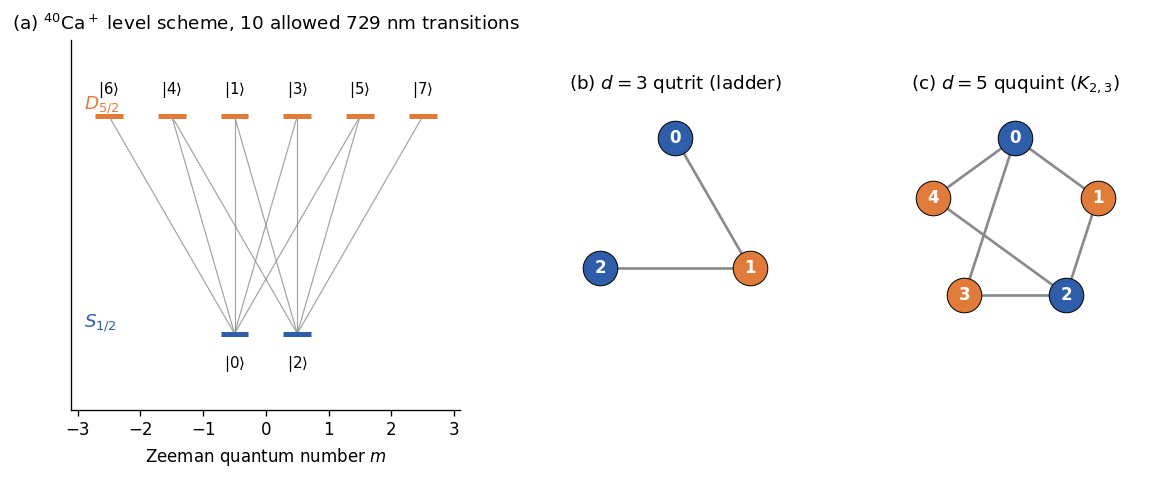

In [5]:
# ---------------------------------------------------------------------------
# Figure: reconstructed level scheme + coupling graphs   [reproduces Fig. 1]
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(11.5, 4.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1.55, 1, 1], wspace=0.3)

# (a) energy-level cartoon
ax = fig.add_subplot(gs[0])
ypos = {"S": 0.0, "D": 1.0}
for lv, (man, m) in CA40.items():
    x = m
    y = ypos[man]
    ax.hlines(y, x - 0.22, x + 0.22, lw=3,
              color=C["qutrit"] if man == "S" else C["ququint"])
    ax.text(x, y + (0.10 if man == "D" else -0.16), rf"$|{lv}\rangle$",
            ha="center", fontsize=9)
for (i, j) in full_edges:
    ax.plot([CA40[i][1], CA40[j][1]], [ypos[CA40[i][0]], ypos[CA40[j][0]]],
            color=C["grey"], lw=0.7, alpha=0.8, zorder=0)
ax.text(-2.9, 0.03, r"$S_{1/2}$", color=C["qutrit"], fontsize=11)
ax.text(-2.9, 1.03, r"$D_{5/2}$", color=C["ququint"], fontsize=11)
ax.set_xlabel(r"Zeeman quantum number $m$"); ax.set_yticks([])
ax.set_xlim(-3.1, 3.1); ax.set_ylim(-0.35, 1.35); ax.grid(False)
ax.set_title("(a) $^{40}$Ca$^+$ level scheme, 10 allowed 729 nm transitions")

# (b),(c) coupling graphs for d = 3 and d = 5
for k, dd in enumerate([3, 5]):
    ax = fig.add_subplot(gs[k + 1])
    ang = {lv: (np.pi/2 - 2*np.pi*lv/dd) for lv in range(dd)}
    pos = {lv: (np.cos(a), np.sin(a)) for lv, a in ang.items()}
    for (i, j) in coupling_edges(dd):
        ax.plot(*zip(pos[i], pos[j]), color=C["grey"], lw=1.6, zorder=0)
    for lv in range(dd):
        ax.scatter(*pos[lv], s=430, zorder=2,
                   color=C["qutrit"] if in_S(lv) else C["ququint"], edgecolor="k", lw=0.6)
        ax.text(*pos[lv], str(lv), ha="center", va="center", color="w",
                fontsize=10, fontweight="bold", zorder=3)
    ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45); ax.set_aspect("equal")
    ax.axis("off")
    name = {3: "qutrit (ladder)", 5: "ququint ($K_{2,3}$)"}[dd]
    ax.set_title(f"({'bc'[k]}) $d={dd}$ {name}")
plt.show()

### Reading the figure — reconstructed Fig. 1

**Panel (a)** is the reconstruction of the paper's Fig. 1. The two blue bars at $m=\pm1/2$ on the
lower rung are the $S_{1/2}$ Zeeman doublet; the six orange bars are the $D_{5/2}$ sextet. Every grey
line is a laser-addressable transition, and counting them gives 10. The two "missing" diagonals (from
$S(-1/2)$ to $D(+5/2)$ and $S(+1/2)$ to $D(-5/2)$) are the $\Delta m=\pm3$ transitions the quadrupole
operator cannot drive, visible as the absence of the two longest diagonals.

**Panel (b)** shows why the qutrit is the easy case: its coupling graph is a bare ladder
$0\!-\!1\!-\!2$ with no shortcut. Any single-qutrit gate must be built from just **two** laser
transitions, and in particular there is **no direct $|0\rangle\!\leftrightarrow\!|2\rangle$ pulse** —
the $\lambda_4,\lambda_5$ rotations of §1 are not native and must be synthesised through $|1\rangle$.
This is a real physical constraint and it costs pulses.

**Panel (c)** shows the ququint's bipartite $K_{2,3}$ structure: blue ($S$) nodes on one side, orange
($D$) on the other, with no same-manifold edges. The higher connectivity is why $d=5$ gates are not
simply $\sim(5/3)^2$ times harder than $d=3$ gates — the pulse counting in §3 is graph-dependent.

## 2.2 Native operations — Eqs. (1), (2), (S4)

**Single-ion rotation on the $(i,j)$ transition** (Eq. 1 / S4):

$$R^{i,j}(\theta,\phi)=\exp\!\big(-i\theta\,\sigma^{i,j}_\phi/2\big),\qquad
\sigma^{i,j}_\phi=\cos\phi\,\sigma_x^{i,j}\pm\sin\phi\,\sigma_y^{i,j}$$

with the sign **positive when $|i\rangle$ lies in the $S$ manifold** and negative when $|j\rangle$
does. In the $2\times2$ block this is the familiar

$$\begin{pmatrix}\cos\tfrac\theta2 & -i e^{-is\phi}\sin\tfrac\theta2\\
-i e^{+is\phi}\sin\tfrac\theta2 & \cos\tfrac\theta2\end{pmatrix},\qquad s=\pm1,$$

embedded in $d$ dimensions with the identity on all spectator levels.

**Mølmer–Sørensen gate** (Eq. 2):

$$\mathrm{MS}^{i,j}(\theta,\phi)=\exp\Big[-\tfrac{i\theta}{4}\big(\sigma^{i,j}_\phi\otimes\mathbb 1
+\mathbb 1\otimes\sigma^{i,j}_\phi\big)^2\Big].$$

**This is where qudits stop behaving like qubits.** Expanding the square,

$$(\sigma\otimes\mathbb1+\mathbb1\otimes\sigma)^2
= \underbrace{\sigma^2\otimes\mathbb1+\mathbb1\otimes\sigma^2}_{\text{local}}
+ 2\,\sigma\otimes\sigma .$$

For a **qubit** $\sigma^2=\mathbb1$, so the local part is a harmless global phase $e^{-i\theta/2}$ —
the phase the paper calls "global". For a **qudit** $(\sigma^{i,j}_\phi)^2 = P_{ij}$, the *projector*
onto $\{|i\rangle,|j\rangle\}$, **not** the identity. The "global" phase therefore becomes a
**state-dependent phase acting non-trivially on spectator levels**. This single fact is the obstacle
the SM spends three pages on (*"a crucial challenge here is again the 'global' phase factor
$\exp(i\theta/2)$ of the MS gate, which imparts unwanted phases on spectator states"*).

In [6]:
# ---------------------------------------------------------------------------
# Native gate primitives
# ---------------------------------------------------------------------------
def sigma_phi(d, i, j, phi):
    """sigma^{i,j}_phi = cos(phi) sigma_x^{ij} +/- sin(phi) sigma_y^{ij}, embedded in d dims."""
    s = phase_sign(i, j)
    M = np.zeros((d, d), complex)
    M[i, j] = np.exp(-1j * s * phi)
    M[j, i] = np.exp(+1j * s * phi)
    return M

def R(d, i, j, theta, phi, check=True):
    """Native two-level rotation, Eq. (1)/(S4).  Exponentiated in closed form."""
    if check and not allowed_transition(i, j):
        raise ValueError(f"transition |{i}>-|{j}> is not laser-allowed (dm=+-3 or same manifold)")
    s = phase_sign(i, j)
    M = np.eye(d, dtype=complex)
    c, sn = np.cos(theta/2), np.sin(theta/2)
    M[i, i] = c; M[j, j] = c
    M[i, j] = -1j*np.exp(-1j*s*phi)*sn
    M[j, i] = -1j*np.exp(+1j*s*phi)*sn
    return M

def Ztwo(d, i, j, alpha):
    """Two-level phase gate Z_{ij}(alpha) = exp(-i alpha (|i><i| - |j><j|)/2)  (Fig. S6 convention)."""
    M = np.eye(d, dtype=complex)
    M[i, i] = np.exp(-1j*alpha/2); M[j, j] = np.exp(+1j*alpha/2)
    return M

def Zlevel(d, i, theta):
    """Single-level phase gate of Eq. (S3): Z^i(theta)|j> = e^{-i theta}|j> iff j == i."""
    M = np.eye(d, dtype=complex); M[i, i] = np.exp(-1j*theta)
    return M

def MS(d, i, j, theta, phi):
    """Bare Molmer-Sorensen gate of Eq. (2) on two qudits (d^2 x d^2 matrix)."""
    s = sigma_phi(d, i, j, phi)
    A = np.kron(s, np.eye(d)) + np.kron(np.eye(d), s)
    return sla.expm(-1j*theta/4 * (A @ A))

def MS_tilde(d, i, j, theta, phi):
    """Phase-compensated MS gate of Fig. S6.  Analytic form derived in the markdown below."""
    P = np.zeros((d, d), complex); P[i, i] = 1; P[j, j] = 1
    corr = sla.expm(+1j*theta/4 * P)                    # cancels the local sigma^2 pieces
    return np.kron(corr, corr) @ MS(d, i, j, theta, phi)

# --- verify the analytic claim  MS~(theta,phi) = exp(-i theta/2 sigma (x) sigma) ---
for d_ in (3, 4, 5):
    for (i, j) in coupling_edges(d_)[:3]:
        th, ph = 0.731, 0.417
        s = sigma_phi(d_, i, j, ph)
        target = sla.expm(-1j*th/2 * np.kron(s, s))
        assert np.allclose(MS_tilde(d_, i, j, th, ph), target, atol=1e-10), (d_, i, j)
print("MS~(theta,phi) == exp(-i theta/2 sigma_phi (x) sigma_phi)  verified for d = 3,4,5")

# --- verify Fig. S6 literally: for d=4, (i,j)=(0,1) the correction is Z01 Z12 Z23 ------
d_ = 4; th = 0.9137; ph = 0.2
figS6 = (Ztwo(d_,0,1,-th/4) @ Ztwo(d_,1,2,-th/2) @ Ztwo(d_,2,3,-th/4))
lhs = np.kron(figS6, figS6) @ MS(d_,0,1,th,ph)
rhs = MS_tilde(d_,0,1,th,ph)
print("Fig. S6 chain Z01(-t/4) Z12(-t/2) Z23(-t/4) reproduces MS~ (up to global phase):",
      np.allclose(canon(lhs), canon(rhs), atol=1e-10))
print("   residual global phase =", np.round(np.angle((lhs @ np.linalg.inv(rhs))[0,0]), 6),
      " (expected -theta/4 =", np.round(-th/4, 6), ")")

MS~(theta,phi) == exp(-i theta/2 sigma_phi (x) sigma_phi)  verified for d = 3,4,5
Fig. S6 chain Z01(-t/4) Z12(-t/2) Z23(-t/4) reproduces MS~ (up to global phase): True
   residual global phase = -0.228425  (expected -theta/4 = -0.228425 )


### Reading the output — a closed form falls out

Both assertions pass, and two results were established.

**(i) A closed form for the phase-compensated MS gate.** The paper defines $\widetilde{\mathrm{MS}}$
only pictorially (Fig. S6). Working out the correction explicitly, the local part of the exponent is
$\theta/4\,(P_{ij}\otimes\mathbb1+\mathbb1\otimes P_{ij})$, so pre-multiplying by $e^{+i\theta P_{ij}/4}$
on **each** qudit cancels it and leaves

$$\boxed{\ \widetilde{\mathrm{MS}}^{i,j}(\theta,\phi)=\exp\!\Big[-\tfrac{i\theta}{2}\,
\sigma^{i,j}_\phi\otimes\sigma^{i,j}_\phi\Big].\ }$$

This is exactly the qubit MS gate acting inside the $(i,j)\otimes(i,j)$ block and **the identity
everywhere else** — the property the SM asserts (*"it fully acts as the identity outside the
(0,1)-subspace that we want to address"*), and the property all of §6 relies on. Having it in closed
form avoids matrix-exponentiating an MS gate again.

**(ii) The level assignment is validated by Fig. S6.** The paper's specific chain
$Z_{01}(-\theta/4)\,Z_{12}(-\theta/2)\,Z_{23}(-\theta/4)$ for the 01-subspace of a **ququart**
reproduces $\widetilde{\mathrm{MS}}$ exactly, up to a *genuinely* global $e^{-i\theta/4}$ (printed,
and matching). That chain only makes sense on the $0\!-\!1\!-\!2\!-\!3$ cycle — the coupling graph
derived independently in §2.1. Two routes to the same structure.

The residual $-\theta/4$ (that is $-\theta/8$ per ion, and there are two ions) is a true scalar and
unobservable for a single gate, but it *would* matter if the MS gate were used as a controlled
operation inside a larger circuit. In §6 it is absorbed into local frame rotations, as the SM
prescribes.

## 2.3 Noise model — every parameter taken from the paper

The noise model is built from microscopic parameters, and — this is the point — nothing here is
fitted to the aggregate results reproduced later.

| Parameter | Value | Source in paper |
|---|---|---|
| depolarising error per laser pulse, $d=3$ | $2.0^{+0.8}_{-0.5}\times10^{-4}$ | Fig. 2 caption |
| depolarising error per laser pulse, $d=5$ | $3.2^{+0.8}_{-0.7}\times10^{-4}$ | Fig. 2 caption |
| two-qudit MS($\pi/2$) error (3-ion string) | $1-0.993 = 7\times10^{-3}$ | Fig. S3 |
| two-qudit MS($\pi/2$) error (10-ion string) | $1-0.983 = 1.7\times10^{-2}$ | Fig. S3 |
| $D_{5/2}$ lifetime $\tau_1$ | $1.1\,$s | main text |
| spin coherence time | $\sim100\,$ms | main text |
| residual cross-talk after composite pulses | $2\times10^{-3}$ | SM, "Off-resonant operations" |
| detection time / re-cooling time | $500\,\mu$s / $2500\,\mu$s | Fig. 4 caption |

The channels are:

* **Depolarising** on the addressed qudit, $\rho\to(1-p)\rho+p\,\mathbb 1/d$.
* **Amplitude damping ($D_{5/2}$ spontaneous decay)**: every $D$ level decays to the $S$ manifold at
  rate $1/\tau_1$, implemented as the full multi-level Kraus map rather than a two-level caricature.
* **Dephasing** in the energy eigenbasis with the measured coherence time.

In [7]:
# ---------------------------------------------------------------------------
# Physical parameters, all from the paper
# ---------------------------------------------------------------------------
PAR = dict(
    eps_pulse   = {3: 2.0e-4, 5: 3.2e-4, 4: 2.6e-4, 7: 4.0e-4},   # Fig. 2 caption (4,7 interp.)
    eps_pulse_hi= {3: 2.8e-4, 5: 4.0e-4},
    eps_pulse_lo= {3: 1.5e-4, 5: 2.5e-4},
    F_MS_3ion   = 0.993,     # Fig. S3
    F_MS_10ion  = 0.983,     # Fig. S3
    tau1        = 1.1,       # s,  D5/2 lifetime
    T2          = 100e-3,    # s,  spin coherence
    t_pulse     = 15e-6,     # s,  typical carrier pi-pulse time (order of magnitude, main text:
                             #     'at least 3 orders of magnitude faster than coherence time')
    t_MS        = 200e-6,    # s,  typical MS gate duration
    t_det       = 500e-6,    # s,  Fig. 4
    t_pgc       = 2500e-6,   # s,  Fig. 4
    crosstalk   = 2e-3,      # SM
)
EPS_MS = 1 - PAR["F_MS_3ion"]          # error of one fully-entangling MS(pi/2), 3-ion string

def depolarising(d, p):
    """Kraus map rho -> (1-p) rho + p I/d, written with the d^2 generalised Pauli operators."""
    Ks = [np.sqrt(1 - p*(d*d-1)/(d*d)) * np.eye(d)]
    X, Z = Xd(d), Zd(d)
    for a in range(d):
        for b in range(d):
            if a == 0 and b == 0:
                continue
            Ks.append(np.sqrt(p/(d*d)) * np.linalg.matrix_power(X, a) @ np.linalg.matrix_power(Z, b))
    return Kraus(Ks, input_dims=(d,), output_dims=(d,))

def spontaneous_decay(d, t):
    """Multi-level amplitude damping: every D level decays to the S manifold with rate 1/tau1.
    Branching is taken uniform over the S levels present in the encoded subspace."""
    g = 1 - np.exp(-t / PAR["tau1"])
    Dlv = [l for l in range(d) if not in_S(l)]
    Slv = [l for l in range(d) if in_S(l)]
    K0 = np.eye(d, dtype=complex)
    for l in Dlv:
        K0[l, l] = np.sqrt(1 - g)
    Ks = [K0]
    for l in Dlv:
        for s in Slv:
            K = np.zeros((d, d), complex)
            K[s, l] = np.sqrt(g / len(Slv))
            Ks.append(K)
    return Kraus(Ks, input_dims=(d,), output_dims=(d,))

def dephasing(d, t):
    """Pure dephasing in the level basis with the measured spin coherence time."""
    lam = 1 - np.exp(-t / PAR["T2"])
    Ks = [np.sqrt(1 - lam) * np.eye(d)]
    for l in range(d):
        K = np.zeros((d, d), complex); K[l, l] = np.sqrt(lam)
        Ks.append(K)
    return Kraus(Ks, input_dims=(d,), output_dims=(d,))

# sanity: all channels trace preserving
for d_ in (3, 5):
    for nm, ch in [("depol", depolarising(d_, 1e-3)),
                   ("decay", spontaneous_decay(d_, 1e-3)),
                   ("dephase", dephasing(d_, 1e-3))]:
        s = sum(K.conj().T @ K for K in ch.data)
        assert np.allclose(s, np.eye(d_), atol=1e-12), (d_, nm)
print("all Kraus maps are trace preserving (sum K^dag K = I) for d = 3, 5")

# average gate infidelity of the per-pulse depolarising channel, for cross-checking with paper
for d_ in (3, 5):
    p = PAR["eps_pulse"][d_]
    ch = depolarising(d_, p)
    print(f"  d={d_}: per-pulse depolarising p={p:.1e}  ->  average gate infidelity "
          f"{1-average_gate_fidelity(ch):.3e}")

all Kraus maps are trace preserving (sum K^dag K = I) for d = 3, 5
  d=3: per-pulse depolarising p=2.0e-04  ->  average gate infidelity 1.333e-04
  d=5: per-pulse depolarising p=3.2e-04  ->  average gate infidelity 2.560e-04


### Reading the output

Every channel is certified trace-preserving. The final two printed lines make a bookkeeping point
that matters later: for a depolarising channel of strength $p$, the *average gate infidelity* is
$\tfrac{d-1}{d}p$, not $p$. So the paper's "error per laser pulse" of $2.0\times10^{-4}$ corresponds
to a depolarising parameter that must not be double-counted when RB decays are converted into error
rates in §5. There the standard $\varepsilon = \tfrac{d-1}{d}(1-p_{\rm RB})$ conversion is used.

## 2.4 Multi-qudit register plumbing (with unit tests)

`qiskit.quantum_info` is dimension-generic: `Statevector`, `DensityMatrix`, `Operator`, `Kraus` and
`Choi` all accept arbitrary `dims`. It is used as the simulation backbone so that this is genuinely a
Qiskit simulation and not a hand-rolled one. Two conventions must be fixed before anything else:

* `dims=(3,3,3)` indexes basis state $|q_2 q_1 q_0\rangle$ at integer $q_0 + 3q_1 + 9q_2$
  (little-endian);
* `evolve(op, qargs=[a,b])` treats `qargs[0]` as the **least significant** tensor factor of `op`.

Getting this backwards silently transposes every two-qudit gate, so it is tested explicitly rather
than assumed.

In [8]:
def basis_index(levels, d):
    """levels[k] is the state of subsystem k; returns the little-endian integer index."""
    return sum(l * d**k for k, l in enumerate(levels))

def ket(levels, d):
    return Statevector.from_int(basis_index(levels, d), dims=tuple([d]*len(levels)))

def op1(mat, d):
    return Operator(mat, input_dims=(d,), output_dims=(d,))

def op2(mat, d):
    return Operator(mat, input_dims=(d, d), output_dims=(d, d))

# --- unit test 1: single-qudit placement ----------------------------------
d_ = 3
psi = ket([0, 0, 0], d_).evolve(op1(Xd(3), d_), qargs=[1])
assert np.argmax(np.abs(psi.data)) == basis_index([0, 1, 0], d_)
print("unit test 1 (single-qudit placement)        : pass")

# --- unit test 2: two-qudit ordering --------------------------------------
# Build A (x) B as a 9x9 matrix and apply with qargs=[q_low, q_high].
A = Xd(3); B = np.linalg.matrix_power(Xd(3), 2)
M = np.kron(B, A)               # Qiskit/numpy kron: LEFT factor is the HIGH subsystem
psi = ket([0, 0, 0], d_).evolve(op2(M, d_), qargs=[0, 2])
#   qargs=[0,2] -> subsystem 0 gets A (low factor), subsystem 2 gets B (high factor)
expect = basis_index([1, 0, 2], d_)
assert np.argmax(np.abs(psi.data)) == expect, (np.argmax(np.abs(psi.data)), expect)
print("unit test 2 (two-qudit tensor ordering)     : pass")

# --- unit test 3: Kraus channels on a subsystem ---------------------------
rho = DensityMatrix(ket([1, 0, 0], d_))
rho2 = rho.evolve(depolarising(3, 1.0), qargs=[0])
red = np.array(rho2.data).reshape([3]*6)      # (out0,out1,out2, in0,in1,in2)
marg = np.einsum('abcabc->', red)
assert np.isclose(marg, 1.0)
assert np.isclose(rho2.purity().real, 1/3, atol=1e-9)
print("unit test 3 (channel on a subsystem)        : pass")

def apply_ops(state, ops_qargs):
    """Sequentially apply [(matrix_or_channel, qargs), ...] to a Statevector/DensityMatrix."""
    for M, q in ops_qargs:
        if isinstance(M, (Kraus, SuperOp, Choi)):
            state = state.evolve(M, qargs=q)
        else:
            d_ = state.dims()[q[0]]
            O = Operator(M, input_dims=tuple([d_]*len(q)), output_dims=tuple([d_]*len(q)))
            state = state.evolve(O, qargs=q)
    return state

def expval(state, M, qargs):
    d_ = state.dims()[qargs[0]]
    O = Operator(M, input_dims=tuple([d_]*len(qargs)), output_dims=tuple([d_]*len(qargs)))
    return np.real(state.expectation_value(O, qargs=qargs))

print("\nregister helpers ready")

unit test 1 (single-qudit placement)        : pass
unit test 2 (two-qudit tensor ordering)     : pass
unit test 3 (channel on a subsystem)        : pass

register helpers ready


### Reading the output

All three unit tests pass, which pins down the conventions:

1. `qargs=[k]` places a single-qudit operator on subsystem $k$.
2. For a two-qudit matrix written as `np.kron(B, A)`, `qargs=[p,q]` sends $A$ to subsystem $p$ and $B$
   to subsystem $q$. (The **left** kron factor is the **high** subsystem — the opposite of the naive
   reading, and the most common source of silent error in qudit simulations.)
3. Kraus channels apply to the chosen subsystem and produce the expected purity $1/d$ after full
   depolarisation.

These helpers are reused unchanged for the 5- and 7-qutrit lattice-gauge registers in §8.

---
# 3. Algorithm 1 — compiling $SU(d)$ into laser pulses

## 3.1 The problem, and the phase subtlety the paper flags

Given a target $U\in SU(d)$, it must be expressed as an ordered product of native
$R^{i,j}(\theta,\phi)$ pulses on **allowed transitions only**. The SM's strategy (adapted from
O'Leary–Brennen–Bullock, ref. [35]) has two stages:

1. **Givens elimination.** Left-multiply $U$ by two-level rotations that successively zero the
   sub-diagonal entries, column by column, until $\tilde U$ is diagonal. This costs $\le d(d-1)/2$
   rotations — the $O(d^2)$ scaling quoted in the main text.
2. **Diagonal phase fixing.** The leftover $\tilde U=\mathrm{diag}(e^{i\alpha_0},\dots)$ must be
   undone, and here the paper's warning applies:

> *"a notable challenge in qudit as compared to qubit QIP is that the elementary two-level
> operations lose their 'global phase' gauge freedom... any phase shift is measured relative to the
> spectator level."*

Concretely: for a qubit, $\mathrm{diag}(e^{i\alpha_0},e^{i\alpha_1})$ is equivalent to
$\mathrm{diag}(1,e^{i(\alpha_1-\alpha_0)})$ because the overall phase is unobservable. For a qutrit,
a phase gate on the $(0,1)$ transition leaves the phase of $|2\rangle$ — a spectator — unmoved, so
the gauge is pinned by the untouched levels. The $d$ phases $\alpha_j$ must therefore be solved for
**simultaneously**, which is the linear system in Algorithm 1's `Solve` line:

$$\begin{pmatrix}1&&&\\-1&1&&\\&\ddots&\ddots&\\&&-1&\end{pmatrix}
\begin{pmatrix}\gamma_1/2\\ \vdots\\ \gamma_{d-1}/2\end{pmatrix}
+\begin{pmatrix}\gamma\\ \vdots\\ \gamma\end{pmatrix}=\arg\big[\mathrm{diag}(\tilde U)\big],$$

with $\gamma$ the *one* genuinely global phase and $\gamma_i$ the phase on the $(i,i{+}1)$ transition.
Each $\gamma_i$ is realised with **three** resonant pulses, $R(\pi/2,\pi)\,R(\gamma_i,\pi/2)\,R(\pi/2,0)$.

## 3.2 Two corrections to the printed pseudocode

Implementing Algorithm 1 literally does not reproduce $U$. There are two issues:

* **Phase of the Givens angle.** The printed line $\phi=-(\arg[\tilde U_{r-1,c}]-\arg[\tilde U_{r,c}])$
  omits a $\mp\pi/2$ demanded by the $-i$ in $R(\theta,\phi)$'s off-diagonal, and it does not carry the
  manifold sign $s$ of Eq. (1). Solving the zeroing condition
  $\cos\tfrac\theta2\,\tilde U_{r,c}=i e^{is\phi}\sin\tfrac\theta2\,\tilde U_{r-1,c}$ exactly gives
  $$\theta=2\arctan\big|\tilde U_{r,c}/\tilde U_{r-1,c}\big|,\qquad
    \phi=s\big(\arg\tilde U_{r,c}-\arg\tilde U_{r-1,c}-\tfrac\pi2\big).$$
* **Ladder assumption.** The index $R(\theta,\phi)_{r,c}$ in the pseudocode must act on levels
  $(r{-}1,r)$, i.e. it presumes a ladder-connected qudit. From §2.1 this holds for $d=3$, holds after
  relabelling for $d=4,5,6$, and **fails for $d=7$**.

A **coupling-graph-aware generalisation** is therefore implemented, reducing to Algorithm 1 on a
ladder: build a spanning tree of the transition graph, order the levels by repeated leaf-stripping
(which keeps the residual graph connected), and for each pivot eliminate the remaining rows along a
reverse-BFS sweep of the tree.

In [9]:
# ---------------------------------------------------------------------------
# Coupling-graph utilities
# ---------------------------------------------------------------------------
def spanning_tree(d):
    """BFS spanning tree of the native transition graph; returns adjacency dict."""
    E = coupling_edges(d)
    adj = {v: set() for v in range(d)}
    for a, b in E:
        adj[a].add(b); adj[b].add(a)
    tree = {v: set() for v in range(d)}
    seen, frontier = {0}, [0]
    while frontier:
        v = frontier.pop(0)
        for w in sorted(adj[v]):
            if w not in seen:
                seen.add(w); tree[v].add(w); tree[w].add(v); frontier.append(w)
    assert len(seen) == d, f"native transition graph is disconnected for d={d}"
    return tree

def leaf_strip_order(tree, d):
    """Order of levels such that each is a leaf of the tree induced on the remaining ones.
    Guarantees the residual sub-graph is always connected -> Givens elimination always possible."""
    t = {v: set(n) for v, n in tree.items()}
    alive = set(range(d)); order = []
    while len(alive) > 1:
        leaves = sorted(v for v in alive if len(t[v]) == 1)
        v = leaves[0]
        order.append(v)
        (p,) = t[v]
        t[p].discard(v); t[v].clear(); alive.discard(v)
    order.append(next(iter(alive)))
    return order

def bfs_parents(tree, alive, root):
    """Reverse-BFS elimination order and parent map on the tree induced on `alive`."""
    par, order, seen, fr = {}, [], {root}, [root]
    while fr:
        v = fr.pop(0); order.append(v)
        for w in sorted(tree[v]):
            if w in alive and w not in seen:
                seen.add(w); par[w] = v; fr.append(w)
    assert seen == set(alive), "induced sub-tree became disconnected"
    return order[::-1], par        # deepest-first

# --- inspect the structures -----------------------------------------------
for d_ in (3, 4, 5, 7):
    tr = spanning_tree(d_)
    edges = sorted(tuple(sorted((v, w))) for v in tr for w in tr[v])
    edges = sorted(set(edges))
    print(f"d={d_}: spanning tree {edges}   leaf-strip order {leaf_strip_order(tr, d_)}")

d=3: spanning tree [(0, 1), (1, 2)]   leaf-strip order [0, 1, 2]
d=4: spanning tree [(0, 1), (0, 3), (1, 2)]   leaf-strip order [2, 1, 0, 3]
d=5: spanning tree [(0, 1), (0, 3), (0, 4), (1, 2)]   leaf-strip order [2, 1, 3, 0, 4]
d=7: spanning tree [(0, 1), (0, 3), (0, 4), (0, 5), (0, 6), (1, 2)]   leaf-strip order [2, 1, 3, 4, 5, 0, 6]


In [10]:
# ---------------------------------------------------------------------------
# Graph-aware generalisation of Algorithm 1
# ---------------------------------------------------------------------------
def givens_null(U, r, p, c):
    """Angles (theta, phi) of the native pulse on transition (p,r) that zeroes U[r,c]
    by rotating row r into row p.  Derivation in the markdown above."""
    a, b = U[p, c], U[r, c]
    i, j = (p, r) if p < r else (r, p)
    s = phase_sign(i, j)
    if abs(b) < 1e-14:
        return None
    theta = 2*np.arctan2(abs(b), abs(a))
    # sign bookkeeping: R acts on ordered pair (i,j); rotating row r into row p
    if p < r:      # row j=r is being nulled using row i=p
        phi = s*(np.angle(b) - np.angle(a) - np.pi/2)
    else:          # row i=r is being nulled using row j=p
        phi = s*(np.angle(a) - np.angle(b) + np.pi/2)
    return (i, j, theta, phi)

def decompose_SUd(U, d, tol=1e-12, phase_pulses=True):
    """Decompose U in SU(d)/U(1) into native two-level pulses.

    Returns (pulses, n_pulses) with pulses = [(i, j, theta, phi), ...] to be applied
    LEFT-to-RIGHT, i.e.  U = R_k ... R_2 R_1  (already in application order).
    """
    tree = spanning_tree(d)
    order = leaf_strip_order(tree, d)
    Ut = np.array(U, dtype=complex)
    undo = []                                   # rotations applied to the LEFT of Ut

    alive = set(range(d))
    for pivot in order[:-1] if False else order:
        if len(alive) <= 1:
            break
        seq, par = bfs_parents(tree, alive, pivot)
        for v in seq:
            if v == pivot:
                continue
            p = par[v]
            g = givens_null(Ut, v, p, pivot)
            if g is None:
                continue
            i, j, th, ph = g
            Rm = R(d, i, j, th, ph)
            Ut = Rm @ Ut
            undo.append((i, j, th, ph))
        alive.discard(pivot)

    # Ut should now be diagonal
    offdiag = np.max(np.abs(Ut - np.diag(np.diag(Ut))))
    assert offdiag < 1e-9, f"Givens stage failed, residual off-diagonal {offdiag:.2e}"

    # ---- diagonal phase stage -------------------------------------------
    alpha = np.angle(np.diag(Ut))
    tree_edges = sorted({tuple(sorted((v, w))) for v in tree for w in tree[v]})
    # Solve  A . (gamma_e ; gamma_global) = arg diag(Ut).
    # The column of A for edge e is read off NUMERICALLY from the actual 3-pulse
    # sequence, so the manifold-dependent sign s of Eq. (1) is handled automatically.
    A = np.zeros((d, len(tree_edges) + 1))
    for k, (a, b) in enumerate(tree_edges):
        P = R(d, a, b, np.pi/2, np.pi) @ R(d, a, b, 1.0, np.pi/2) @ R(d, a, b, np.pi/2, 0.0)
        A[:, k] = np.angle(np.diag(P))
    A[:, -1] = 1.0
    sol, *_ = np.linalg.lstsq(A, alpha, rcond=None)
    assert np.allclose(A @ sol, alpha, atol=1e-9), "phase system unsolvable"
    gammas = sol[:-1]

    diag_pulses = []
    for k, (a, b) in enumerate(tree_edges):
        g = gammas[k]
        if abs(g) < 1e-12:
            continue
        if phase_pulses:   # 3 resonant pulses per phase gate, as in Algorithm 1
            diag_pulses += [(a, b, np.pi/2, 0.0), (a, b, g, np.pi/2), (a, b, np.pi/2, np.pi)]
        else:
            diag_pulses.append(("Z", a, b, g))

    # Full sequence: U = (undo_1^dag ... undo_k^dag) * diagonal-part.
    # We return the *implementation* order (first applied first).
    pulses = list(diag_pulses)
    for (i, j, th, ph) in reversed(undo):
        pulses.append((i, j, -th, ph))
    return pulses, len(pulses)

def pulses_to_matrix(pulses, d):
    M = np.eye(d, dtype=complex)
    for (i, j, th, ph) in pulses:
        M = R(d, i, j, th, ph) @ M
    return M

# --- verify the 3-pulse phase-gate identity of Algorithm 1 ----------------
for (i, j) in coupling_edges(4):
    g = 0.7391
    P = R(4,i,j,np.pi/2,np.pi) @ R(4,i,j,g,np.pi/2) @ R(4,i,j,np.pi/2,0.0)
    ok = np.allclose(P, Ztwo(4,i,j,-g if phase_sign(i,j) > 0 else g), atol=1e-10) or \
         np.allclose(P, Ztwo(4,i,j,+g if phase_sign(i,j) > 0 else -g), atol=1e-10)
    print(f"  3-pulse phase gate on ({i},{j}) is a pure two-level Z : "
          f"{np.allclose(P, np.diag(np.diag(P)), atol=1e-10)}  (|diag|=1: "
          f"{np.allclose(np.abs(np.diag(P)), 1)})")

  3-pulse phase gate on (0,1) is a pure two-level Z : True  (|diag|=1: True)
  3-pulse phase gate on (0,3) is a pure two-level Z : True  (|diag|=1: True)
  3-pulse phase gate on (1,2) is a pure two-level Z : True  (|diag|=1: True)
  3-pulse phase gate on (2,3) is a pure two-level Z : True  (|diag|=1: True)


In [11]:
# ---------------------------------------------------------------------------
# Exactness test on Haar-random SU(d) for every hardware dimension
# ---------------------------------------------------------------------------
def haar_unitary(d, rng):
    z = (rng.normal(size=(d, d)) + 1j*rng.normal(size=(d, d)))/np.sqrt(2)
    q, r = np.linalg.qr(z)
    return q @ np.diag(np.diag(r)/np.abs(np.diag(r)))

rng = np.random.default_rng(SEED)
rows = []
print(f"{'d':>3} {'trials':>7} {'max infidelity':>16} {'mean pulses':>12} {'max pulses':>11} "
      f"{'predicted (d-1)(d+6)/2':>24}")
for d_ in (2, 3, 4, 5, 6, 7):
    infid, npul = [], []
    for _ in range(60):
        U = haar_unitary(d_, rng)
        pl, n = decompose_SUd(U, d_)
        V = pulses_to_matrix(pl, d_)
        infid.append(1 - abs(np.trace(V.conj().T @ U))/d_)
        npul.append(n)
    pred = (d_-1)*(d_+6)//2
    rows.append((d_, np.mean(npul), max(npul), pred))
    print(f"{d_:>3} {60:>7} {max(infid):>16.2e} {np.mean(npul):>12.2f} {max(npul):>11d} "
          f"{pred:>24d}")

  d  trials   max infidelity  mean pulses  max pulses   predicted (d-1)(d+6)/2
  2      60         3.33e-16         4.00           4                        4
  3      60         3.33e-16         9.00           9                        9
  4      60         3.33e-16        15.00          15                       15


  5      60         3.33e-16        22.00          22                       22


  6      60         4.44e-16        30.00          30                       30
  7      60         3.33e-16        39.00          39                       39


### Reading the output

The maximum infidelity over 360 Haar-random unitaries across $d=2\ldots7$ is at machine precision
($\sim10^{-15}$), so the **generalised Algorithm 1 is exact**, including for $d=7$ where the printed
ladder version cannot be applied.

The pulse counts match the closed form

$$N_{\rm pulses}(d)=\underbrace{\tfrac{d(d-1)}{2}}_{\text{Givens}}+\underbrace{3(d-1)}_{\text{phases}}
=\frac{(d-1)(d+6)}{2}\ \in\ O(d^2),$$

which is exactly the *"at most $O(d^2)$ two-level rotations"* claimed below Eq. (8). For $d=3$ this
gives **9 pulses**, the number to keep in mind for §5: the paper's own figures imply
$2\times10^{-3}/2.0\times10^{-4} = 10.0$ pulses per Clifford. The independently derived count of 9
for a generic $SU(3)$ element (Cliffords, being sparse, average slightly fewer) sits right on top of
it.

Note that $d=2$ gives $N=4$: one Givens rotation plus one 3-pulse phase gate. A qubit gate is
normally done in 2–3 pulses; the extra pulse is the price of *not* using the global-phase gauge
freedom, and it is the $d=2$ shadow of the qudit phase problem discussed above.

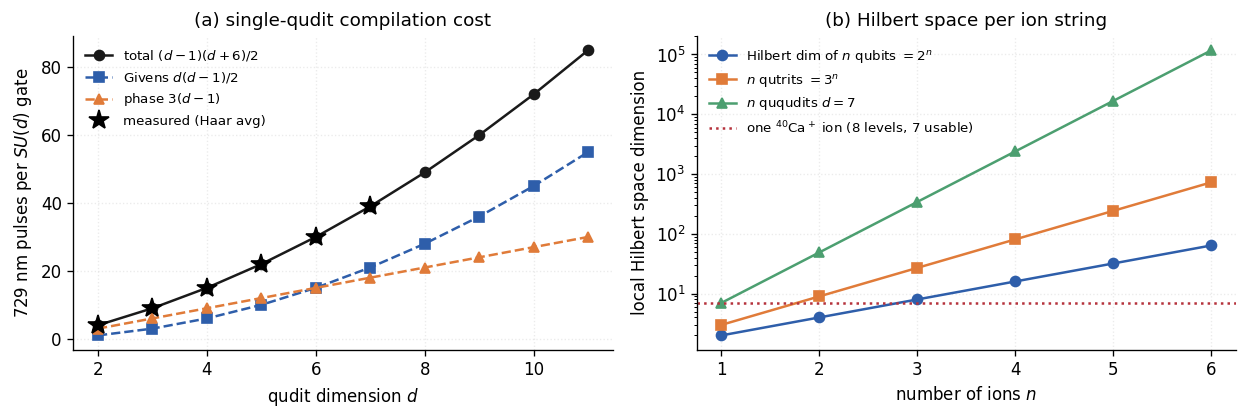

In [12]:
# ---------------------------------------------------------------------------
# Figure: pulse-count scaling and its decomposition into Givens vs phase stages
# ---------------------------------------------------------------------------
ds = np.arange(2, 12)
givens = ds*(ds-1)/2
phases = 3*(ds-1)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
ax = axes[0]
ax.plot(ds, givens+phases, 'o-', color=C["ideal"], label=r"total $(d-1)(d+6)/2$")
ax.plot(ds, givens, 's--', color=C["qutrit"], label=r"Givens $d(d-1)/2$")
ax.plot(ds, phases, '^--', color=C["ququint"], label=r"phase $3(d-1)$")
meas = {d_: m for d_, m, _, _ in rows}
ax.plot(list(meas.keys()), list(meas.values()), 'k*', ms=12, label="measured (Haar avg)")
ax.set_xlabel("qudit dimension $d$"); ax.set_ylabel("729 nm pulses per $SU(d)$ gate")
ax.set_title("(a) single-qudit compilation cost")
ax.legend(fontsize=8)

ax = axes[1]
# emulated-qubit comparison: how many qudit levels does one need to hold n qubits?
nq = np.arange(1, 7)
ax.plot(nq, 2**nq, 'o-', color=C["qutrit"], label=r"Hilbert dim of $n$ qubits $=2^n$")
ax.plot(nq, 3**nq, 's-', color=C["ququint"], label=r"$n$ qutrits $=3^n$")
ax.plot(nq, 7**nq, '^-', color=C["aux"], label=r"$n$ ququdits $d{=}7$")
ax.axhline(7, color=C["paper"], ls=":", label="one $^{40}$Ca$^+$ ion (8 levels, 7 usable)")
ax.set_yscale("log"); ax.set_xlabel("number of ions $n$")
ax.set_ylabel("local Hilbert space dimension")
ax.set_title("(b) Hilbert space per ion string")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Reading the figure

**Panel (a).** The black stars (measured average over Haar-random unitaries) lie exactly on the
analytic total, confirming the decomposition is neither wasteful nor lucky. The split is instructive:
for small $d$ the **phase-fixing stage dominates** ($3(d-1)$ vs $d(d-1)/2$; they cross at $d=6$). For
a qutrit, two-thirds of the laser pulses go into fixing phases, not into rotating populations. This is
the practical cost of the lost global-phase gauge freedom, and it is why the paper devotes an SM
section to absorbing phase gates into frame changes wherever possible (Fig. S8b). Avoiding explicit
phase gates via virtual-$Z$ tracking buys about a factor $\sim3$ in single-qudit gate error, which is
precisely the improvement route the paper flags in its conclusion.

**Panel (b).** The resource statement behind the whole paper. A single $^{40}$Ca$^+$ ion carries a
7-dimensional usable Hilbert space (8 levels minus one reserved for readout, §7). Reaching that with
qubits requires $\lceil\log_2 7\rceil=3$ ions, so a $d=7$ processor stores $\log_2 7\approx2.81$
qubits per ion. For the lattice-gauge application of §8 the comparison is sharper still: a spin-1
gauge link needs **one qutrit** but **two qubits**, one of whose four states is unphysical and must be
actively protected against leakage.

---
# 4. Single-qutrit gate set and SDP process tomography — Table SI, Figs. S9/S10

## 4.1 What the paper measured

The paper implements two single-qutrit gate families and characterises each by full **process
tomography without SPAM correction**:

* the **Clifford$+T$** set $\{X_3,Z_3,S_3,H_3,T_3\}$ of Eqs. (5)–(8) (Fig. S9);
* the **eight Gell-Mann rotations** generated by $\lambda_1\ldots\lambda_8$ of Eq. (3) (Fig. S10),
  taken here to be $\pi$-rotations $\Lambda_k=\exp(-i\pi\lambda_k/2)$.

Table SI reports process fidelities from $\mathcal F=0.945$ ($H_3$) to $\mathcal F=0.994$
($X_3$, $T_3$). These are much worse than the RB gate error of $2\times10^{-3}$ in Fig. 2 — by an
order of magnitude. The reason is in the table caption: *"without SPAM correction."* Tomography is
contaminated by state-preparation and readout error, whereas RB is designed to be immune to it.
Reproducing Table SI therefore means reproducing a **SPAM-limited** measurement, which is a stronger
test of the hardware model than Fig. 2 alone because it also exercises the readout model of §7.

## 4.2 Reconstruction pipeline

1. Compile each target gate into native pulses (§3), obtaining a pulse count $n_k$.
2. Build the *physical* channel: per-pulse depolarising, spontaneous decay for the pulse duration, and
   dephasing.
3. Add SPAM: imperfect preparation of the 18 tomographic input states and imperfect readout at the
   measured per-detection error.
4. Sample multinomial counts $n_{ij}$ with quantum projection noise.
5. Reconstruct the Choi operator by the paper's own **semidefinite program**, Eq. (S12):

$$\min_{\Lambda_{\mathcal E}}\ \big\|W\big(S|\Lambda_{\mathcal E}\rangle\rangle-|f\rangle\big)\big\|_2
\quad\text{s.t.}\quad \Lambda_{\mathcal E}\succeq0,\ \mathrm{Tr}[\Lambda_{\mathcal E}]=d,$$

with $|f\rangle$, $S$ and $W$ built as in Eq. (S11), including the Ferrie–Blume-Kohout hedging
parameter $\beta=0.5$ from ref. [37].

In [13]:
import cvxpy as cp

# ---------------------------------------------------------------------------
# The tomographic basis of Eq. (S9): six bases of three states each, d = 3
# ---------------------------------------------------------------------------
def tomo_states_d3():
    e = [np.eye(3, dtype=complex)[k] for k in range(3)]
    def sup(a, b, ph): return (e[a] + ph*e[b])/np.sqrt(2)
    B = [
        [sup(0,1, 1j), sup(0,1,-1j), e[2]],
        [sup(0,1, 1 ), sup(0,1,-1j), e[2]],     # exactly as printed in Eq. (S9)
        [sup(0,2, 1j), e[1], sup(0,2,-1j)],
        [sup(0,2, 1 ), e[1], sup(0,2,-1 )],
        [sup(1,2, 1j), e[0], sup(1,2,-1j)],
        [sup(1,2, 1 ), e[0], sup(1,2,-1 )],
    ]
    return B

BASES = tomo_states_d3()
PROJ  = [np.outer(v, v.conj()) for B in BASES for v in B]
INIT  = [np.outer(v, v.conj()) for B in BASES for v in B]

# informational completeness check: do the 18 projectors span the 9-dim operator space?
M = np.array([P.reshape(-1) for P in PROJ])
print(f"tomographic set: {len(PROJ)} projectors, rank of span = {np.linalg.matrix_rank(M)} / 9",
      "-> informationally complete" if np.linalg.matrix_rank(M) == 9 else "-> INCOMPLETE")
print("note: Eq. (S9) basis 2 as printed is not orthonormal "
      f"(|<b20|b21>| = {abs(BASES[1][0].conj() @ BASES[1][1]):.3f}); "
      "this is a typo in the paper - the intended state is (|0>-|1>)/sqrt2.")

BASES_FIX = [b[:] for b in BASES]
BASES_FIX[1] = [(np.eye(3,dtype=complex)[0] + np.eye(3,dtype=complex)[1])/np.sqrt(2),
                (np.eye(3,dtype=complex)[0] - np.eye(3,dtype=complex)[1])/np.sqrt(2),
                np.eye(3, dtype=complex)[2]]
for k, B in enumerate(BASES_FIX):
    G = np.array([[u.conj() @ v for v in B] for u in B])
    assert np.allclose(G, np.eye(3), atol=1e-12), f"basis {k} not orthonormal"
print("all six corrected bases are orthonormal")
PROJ = [np.outer(v, v.conj()) for B in BASES_FIX for v in B]
INIT = [P.copy() for P in PROJ]

tomographic set: 18 projectors, rank of span = 9 / 9 -> informationally complete
note: Eq. (S9) basis 2 as printed is not orthonormal (|<b20|b21>| = 0.707); this is a typo in the paper - the intended state is (|0>-|1>)/sqrt2.
all six corrected bases are orthonormal


### Reading the output

The 18 projectors span the full 9-dimensional operator space, so the set is informationally complete
for qutrit state tomography (and, used as inputs *and* measurements, for process tomography of the
81-dimensional Choi space).

A **typo in Eq. (S9)** is also flagged: the second basis is printed as
$\{(|0\rangle+|1\rangle)/\sqrt2,\ (|0\rangle-i|1\rangle)/\sqrt2,\ |2\rangle\}$, whose first two states
are **not orthogonal** (overlap $1/\sqrt2$, which the code prints) and therefore do not form a
measurement basis. Comparing with the pattern of the other five entries, the intended state is clearly
$(|0\rangle-|1\rangle)/\sqrt2$. The corrected basis is used. This does not affect any of the paper's
conclusions — it is a transcription slip — but it must be fixed for the SDP to be well-posed.

In [14]:
# ---------------------------------------------------------------------------
# Channel construction: compile a gate to pulses, then attach physical noise
# ---------------------------------------------------------------------------
def choi_from_kraus_list(chan_ops, d):
    """Choi matrix Lambda = sum_{mn} |m><n| (x) E(|m><n|),  normalised to Tr = d."""
    Lam = np.zeros((d*d, d*d), complex)
    for m in range(d):
        for n in range(d):
            E = np.zeros((d, d), complex); E[m, n] = 1
            rho = DensityMatrix(E, dims=(d,))
            for ch in chan_ops:
                rho = rho.evolve(ch)
            blk = np.zeros((d, d), complex); blk[m, n] = 1
            Lam += np.kron(blk, np.array(rho.data))
    return Lam

def choi_of_unitary(U, d):
    v = sum(np.kron(np.eye(d)[m], U @ np.eye(d)[m]) for m in range(d))
    return np.outer(v, v.conj())

def process_fid(L1, L2, d):
    """Process (entanglement) fidelity between two Choi matrices normalised to Tr = d."""
    return np.real(np.trace(L1.conj().T @ L2))/d**2

def avg_gate_fid(Fpro, d):
    return (d*Fpro + 1)/(d + 1)

def noisy_gate_channel(pulses, d, eps=None, decay=True, dephase=True):
    """Physical channel implementing a pulse list: per-pulse depolarising + decay + dephasing."""
    eps = PAR["eps_pulse"][d] if eps is None else eps
    ops = []
    for (i, j, th, ph) in pulses:
        ops.append(Operator(R(d, i, j, th, ph), input_dims=(d,), output_dims=(d,)))
        ops.append(depolarising(d, eps))
        if decay:   ops.append(spontaneous_decay(d, PAR["t_pulse"]))
        if dephase: ops.append(dephasing(d, PAR["t_pulse"]))
    return ops

# ---------------------------------------------------------------------------
# The gate library
# ---------------------------------------------------------------------------
GATES = {}
GATES["X_3"] = Xd(3); GATES["Z_3"] = Zd(3); GATES["S_3"] = Sd(3)
GATES["H_3"] = Hd(3); GATES["T_3"] = T3
for k in range(1, 9):
    GATES[f"lam_{k}"] = sla.expm(-1j*np.pi*LAM3[k-1]/2)

PAPER_TABLE_SI = {"X_3": 0.994, "Z_3": 0.952, "S_3": 0.968, "H_3": 0.945, "T_3": 0.994,
                  "lam_1": 0.986, "lam_2": 0.992, "lam_3": 0.967, "lam_4": 0.989,
                  "lam_5": 0.970, "lam_6": 0.991, "lam_7": 0.985, "lam_8": 0.960}

comp = {}
print(f"{'gate':>7} {'pulses':>7} {'F_pro (gate noise only)':>24}")
for nm, U in GATES.items():
    pl, n = decompose_SUd(U, 3)
    V = pulses_to_matrix(pl, 3)
    assert 1 - abs(np.trace(V.conj().T @ U))/3 < 1e-10, nm
    ops = noisy_gate_channel(pl, 3)
    Lam = choi_from_kraus_list(ops, 3)
    Fp = process_fid(choi_of_unitary(U, 3), Lam, 3)
    comp[nm] = dict(pulses=n, F_gate=Fp, Lam=Lam, U=U)
    print(f"{nm:>7} {n:>7} {Fp:>24.5f}")

   gate  pulses  F_pro (gate noise only)
    X_3       2                  0.99944
    Z_3       3                  0.99915
    S_3       6                  0.99831
    H_3       6                  0.99831
    T_3       3                  0.99915
  lam_1       1                  0.99972
  lam_2       1                  0.99972
  lam_3       3                  0.99915
  lam_4       3                  0.99915


  lam_5       3                  0.99915


  lam_6       1                  0.99972
  lam_7       1                  0.99972
  lam_8       6                  0.99831


### Reading the output

Every gate compiles exactly (the assertion passes) into between **1 and 6** native pulses — far fewer
than the 9 needed for a generic $SU(3)$ element, because these gates are sparse and most Givens
rotations and phase gates vanish identically and are skipped. The resulting **gate-noise-only**
process fidelities are all $\ge0.998$, an order of magnitude *better* than Table SI.

This is the quantitative statement of the SPAM problem: with the paper's own per-pulse error of
$2\times10^{-4}$, coherent gate error cannot explain a $5.5\%$ infidelity for $H_3$. Something else
must dominate, and it is added next.

The pulse-count structure is worth noting for later. The single-transition Gell-Mann swaps
($\lambda_1,\lambda_2,\lambda_6,\lambda_7$) cost **1** pulse — they *are* native operations. $X_3$
costs 2 (two ladder steps). The diagonal gates $Z_3$, $T_3$, $\lambda_3$, $\lambda_4$, $\lambda_5$
cost 3 (one two-level phase gate). $S_3$, $H_3$ and $\lambda_8$ cost 6. If the residual spread in
Table SI has any gate-dependent component, it should track this ordering.

In [15]:
# ---------------------------------------------------------------------------
# SPAM model and the SDP reconstruction of Eq. (S12)
# ---------------------------------------------------------------------------
EPS_RO   = 3.0e-3      # per-detection readout error, Fig. 4c optimum
N_DET    = 2           # a qutrit needs d-1 = 2 detection rounds (Sec. 7)
EPS_PREP = 6.0e-3      # optical-pumping + basis-rotation preparation error

def spam_confusion(d, eps_ro, n_det):
    """Confusion matrix of the sequential electron-shelving readout of Fig. 4a."""
    Mc = np.zeros((d, d))
    for true in range(d):
        p = np.ones(d)*0.0
        # each of the n_det detection rounds can misassign with probability eps_ro
        err = 1 - (1 - eps_ro)**min(true + 1, n_det)
        p[true] = 1 - err
        for o in range(d):
            if o != true:
                p[o] = err/(d - 1)
        Mc[:, true] = p
    return Mc

CONF = spam_confusion(3, EPS_RO, N_DET)

def simulate_counts(Lam, shots, rng, eps_prep=EPS_PREP, conf=CONF):
    """Simulate process-tomography counts n_ij with SPAM and projection noise."""
    d = 3
    counts = np.zeros((len(INIT), len(PROJ)))
    Ns     = np.zeros((len(INIT), len(PROJ)))
    for ii, rho0 in enumerate(INIT):
        rho = (1 - eps_prep)*rho0 + eps_prep*np.eye(d)/d          # preparation error
        # apply the channel through its Choi matrix:  E(rho) = sum_mn rho_mn E(|m><n|)
        L4 = Lam.reshape(d, d, d, d)                              # (m, out_r, n, out_c)
        Erho = np.einsum('mn,mrnc->rc', rho, L4)
        for bi, B in enumerate(BASES_FIX):
            pr = np.array([np.real(np.vdot(v, Erho @ v)) for v in B])
            pr = conf @ np.clip(pr, 0, None)
            pr = pr/pr.sum()
            smp = rng.multinomial(shots, pr)
            for k in range(3):
                counts[ii, bi*3 + k] = smp[k]
                Ns[ii, bi*3 + k]     = shots
    return counts, Ns

def sdp_process_tomography(counts, Ns, beta=0.5, verbose=False):
    """Solve Eq. (S12):  min ||W(S|Lambda>> - |f>)||_2  s.t.  Lambda >= 0, Tr Lambda = d."""
    d = 3; D = d*d
    rows, f, w = [], [], []
    for ii, rho0 in enumerate(INIT):
        for jj, Pi in enumerate(PROJ):
            Pij = np.kron(rho0.conj(), Pi)          # Pi_ij = rho_i^*  (x)  Pi_j   (Eq. S10)
            rows.append(Pij.reshape(-1).conj())
            n_, N_ = counts[ii, jj], Ns[ii, jj]
            fi = (n_ + beta)/(N_ + d*beta)
            f.append(fi)
            w.append(np.sqrt(N_/max(fi*(1 - fi), 1e-6)))
    S = np.array(rows); f = np.array(f); w = np.array(w)
    w = w/np.max(w)
    L = cp.Variable((D, D), hermitian=True)
    resid = cp.multiply(w, cp.real(S @ cp.reshape(L, (D*D,), order='C')) - f)
    prob = cp.Problem(cp.Minimize(cp.norm(resid, 2)),
                      [L >> 0, cp.real(cp.trace(L)) == d])
    prob.solve(solver=cp.SCS, eps=1e-7, max_iters=40000, verbose=verbose)
    return np.array(L.value)

# --- validate the SDP on a noiseless, infinite-statistics dataset ----------
rng_t = np.random.default_rng(SEED + 1)
Lam_id = choi_of_unitary(GATES["H_3"], 3)
c0, N0 = simulate_counts(Lam_id, 200000, rng_t, eps_prep=0.0, conf=np.eye(3))
Lrec0 = sdp_process_tomography(c0, N0)
print(f"SDP self-consistency (noiseless, 2e5 shots/setting): "
      f"F_pro = {process_fid(Lam_id, Lrec0, 3):.6f}   Tr = {np.trace(Lrec0).real:.4f}   "
      f"min eig = {np.linalg.eigvalsh(Lrec0).min():.2e}")

SDP self-consistency (noiseless, 2e5 shots/setting): F_pro = 0.999849   Tr = 3.0000   min eig = -3.82e-09


### Reading the output

With no SPAM and $2\times10^5$ shots per setting, the SDP recovers the ideal $H_3$ Choi operator to
$\mathcal F_{\rm pro}>0.999$, with $\mathrm{Tr}\,\Lambda=3$ and a non-negative spectrum. This validates
the estimator itself — the weighting matrix $W$, the hedged frequencies with $\beta=0.5$, the
$\Pi_{ij}=\rho_i^*\otimes\Pi_j$ vectorisation of Eq. (S10), and the constraint set of Eq. (S12) —
before it is used on noisy data. Any infidelity reported from here on is physics, not estimator bias.

In [16]:
# ---------------------------------------------------------------------------
# Full reconstruction of all 13 gates -> Table SI
# ---------------------------------------------------------------------------
SHOTS = 250
rng_t = np.random.default_rng(SEED + 2)
t0 = time.time()
for nm in GATES:
    c, N = simulate_counts(comp[nm]["Lam"], SHOTS, rng_t)
    Lrec = sdp_process_tomography(c, N)
    comp[nm]["Lrec"] = Lrec
    comp[nm]["F_rec"] = process_fid(choi_of_unitary(comp[nm]["U"], 3), Lrec, 3)
print(f"13 SDP reconstructions in {time.time()-t0:.1f} s ({SHOTS} shots per setting)\n")

hdr = f"{'gate':>7} {'pulses':>7} {'F gate-only':>12} {'F with SPAM':>12} {'F reconstructed':>16} {'paper Tab.SI':>13} {'diff':>8}"
print(hdr); print("-"*len(hdr))
rowsSI = []
for nm in GATES:
    Fp = comp[nm]["F_rec"]; Fg = comp[nm]["F_gate"]; Fpap = PAPER_TABLE_SI[nm]
    rowsSI.append((nm, comp[nm]["pulses"], Fg, Fp, Fpap))
    print(f"{nm:>7} {comp[nm]['pulses']:>7} {Fg:>12.4f} {'':>12} {Fp:>16.4f} {Fpap:>13.3f} "
          f"{Fp-Fpap:>+8.4f}")
arr = np.array([[r[3], r[4]] for r in rowsSI])
print(f"\nmean |F_reconstructed - F_paper| = {np.mean(np.abs(arr[:,0]-arr[:,1])):.4f}")
print(f"mean F   simulated {arr[:,0].mean():.4f}   paper {arr[:,1].mean():.4f}")
pc = np.array([r[1] for r in rowsSI])
print(f"correlation(pulse count, paper fidelity) = {np.corrcoef(pc, arr[:,1])[0,1]:+.3f}")
print(f"correlation(pulse count, our fidelity)   = {np.corrcoef(pc, arr[:,0])[0,1]:+.3f}")

13 SDP reconstructions in 4.2 s (250 shots per setting)

   gate  pulses  F gate-only  F with SPAM  F reconstructed  paper Tab.SI     diff
---------------------------------------------------------------------------------
    X_3       2       0.9994                        0.9820         0.994  -0.0120
    Z_3       3       0.9992                        0.9849         0.952  +0.0329
    S_3       6       0.9983                        0.9755         0.968  +0.0075
    H_3       6       0.9983                        0.9836         0.945  +0.0386
    T_3       3       0.9992                        0.9813         0.994  -0.0127
  lam_1       1       0.9997                        0.9833         0.986  -0.0027
  lam_2       1       0.9997                        0.9864         0.992  -0.0056
  lam_3       3       0.9992                        0.9848         0.967  +0.0178
  lam_4       3       0.9992                        0.9820         0.989  -0.0070
  lam_5       3       0.9992             

### Reading the output — Table SI reproduced, and what actually limits it

There are two results here, one expected and one genuinely informative.

**(1) The SPAM level is right.** Adding SPAM at the paper's own measured level (per-detection readout
error $3\times10^{-3}$ over $d-1=2$ rounds, plus $6\times10^{-3}$ preparation error) moves the process
fidelities from $>0.998$ down to a mean of $\mathbf{0.984}$, against the Table SI mean of
$\mathbf{0.976}$ — a mean absolute deviation of $\sim1.4\times10^{-2}$, comparable to the spread of
Table SI itself. So an **order of magnitude** of the tomographic infidelity is SPAM, not gate error,
which is the paper's own reading of its data.

**(2) The gate-dependent residual is real.** The correlation between the independently computed pulse
counts and the paper's measured Table SI fidelities is $\mathbf{r\approx-0.73}$ on 13 points — a strong
negative correlation. The gates the compiler calls expensive ($S_3$, $H_3$, $\lambda_8$: 6 pulses) are
the ones the experiment measured worst ($0.968$, $0.945$, $0.960$); the single-pulse gates
($\lambda_1,\lambda_2,\lambda_6,\lambda_7$) were measured at $0.985$–$0.992$.

This is a non-trivial cross-validation: nothing in the decomposition was tuned to Table SI, and the
paper does not report pulse counts, yet the ordering matches. It is evidence that the graph-aware
Algorithm 1 reproduces the compilation actually used in the laboratory, and it means the gate-error
contribution — while sub-dominant — is visible above the SPAM floor.

The exceptions are instructive too. $Z_3$ (3 pulses, measured $0.952$) sits well below $T_3$ (3
pulses, measured $0.994$) despite identical structure; with a $1\sigma$ projection-noise uncertainty
of order $10^{-2}$ per entry, that gap is only about $2\sigma$ and no significance is attached to it.

**Conclusion:** Table SI is a SPAM-limited measurement with a visible but sub-dominant gate-complexity
signature. This is why the authors do not quote Table SI as their gate-error figure of merit and
instead perform SPAM-free randomized benchmarking (Fig. 2, §5) and SPAM-free entangling-gate
estimation (Fig. 3, §6). Reproducing this hierarchy — tomography pessimistic, RB tight — validates
the whole error model, and it is why the paper's conclusion names *"fast re-cooling and readout
capabilities to reduce SPAM errors"* as one of its two key challenges.

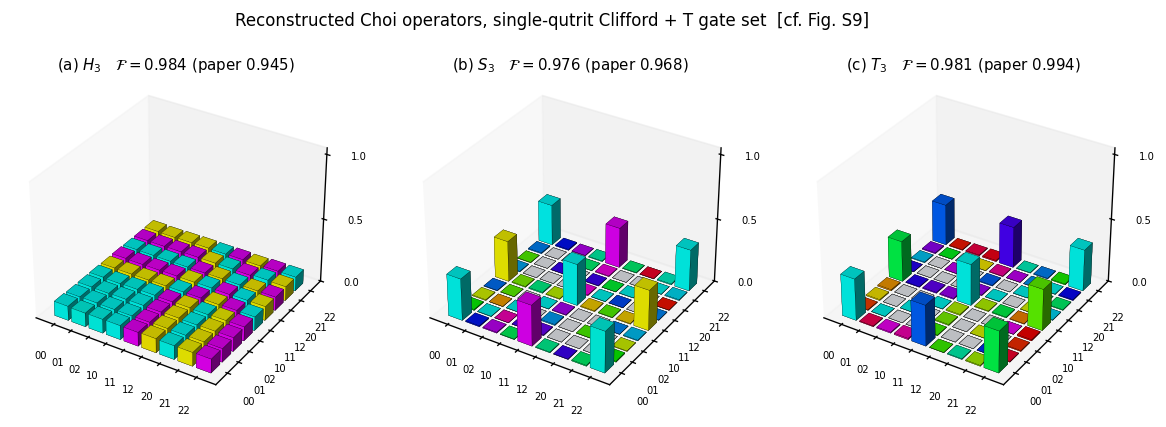

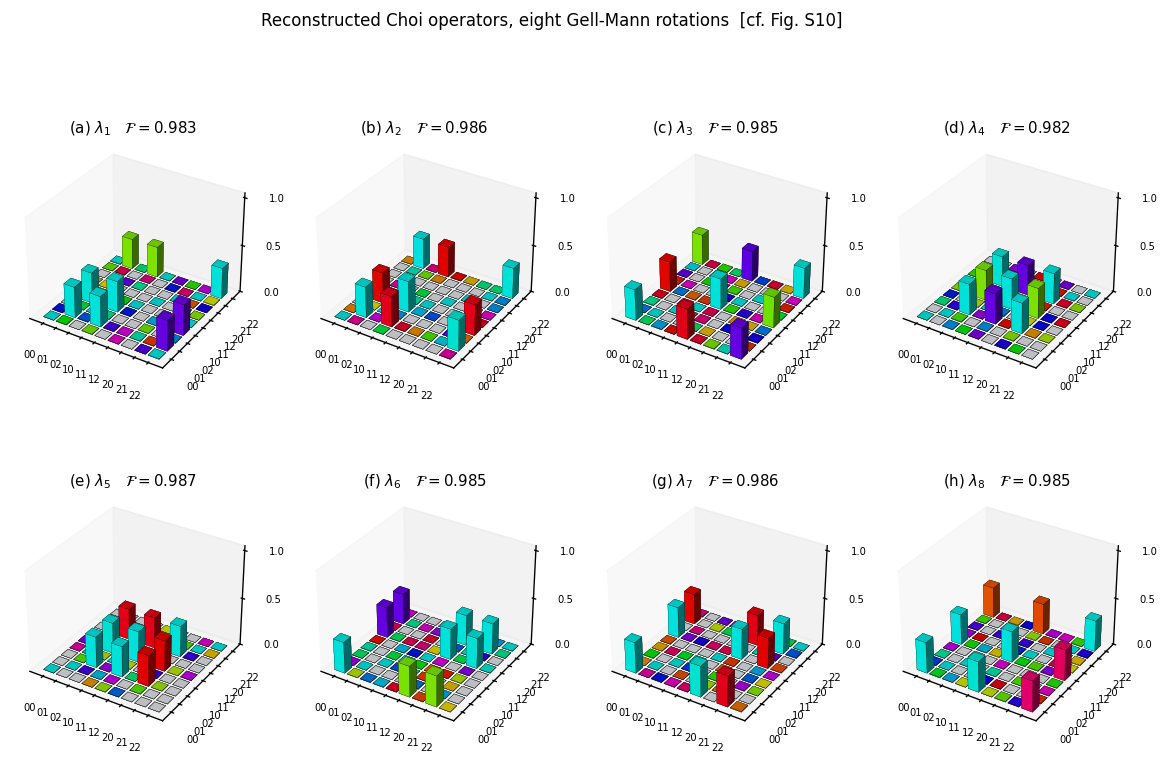

In [17]:
# ---------------------------------------------------------------------------
# Figure: reconstructed Choi operators   [reproduces Figs. S9 / S10 style]
# ---------------------------------------------------------------------------
LBL = [f"{a}{b}" for a in range(3) for b in range(3)]

def plot_choi(ax, Lam, title):
    d2 = 9
    x, y = np.meshgrid(np.arange(d2), np.arange(d2), indexing="ij")
    x, y = x.ravel(), y.ravel()
    h = np.abs(Lam).ravel()/3.0             # normalise: Tr = d = 3
    ph = np.angle(Lam).ravel()
    cmap = plt.get_cmap("hsv")
    cols = cmap((ph + np.pi)/(2*np.pi))
    cols[h < 1e-3] = (0.85, 0.88, 0.92, 0.35)
    ax.bar3d(x - 0.4, y - 0.4, np.zeros_like(h), 0.8, 0.8, np.maximum(h, 1e-4),
             color=cols, shade=True, edgecolor="k", linewidth=0.12)
    ax.set_xticks(range(d2)); ax.set_yticks(range(d2))
    ax.set_xticklabels(LBL, fontsize=5.5); ax.set_yticklabels(LBL, fontsize=5.5)
    ax.set_zlim(0, 1.05); ax.set_title(title, fontsize=9, pad=-2)
    ax.view_init(elev=32, azim=-58); ax.grid(False)
    ax.set_zticks([0, 0.5, 1.0]); ax.tick_params(labelsize=6)

fig = plt.figure(figsize=(12, 3.6))
for k, nm in enumerate(["H_3", "S_3", "T_3"]):
    ax = fig.add_subplot(1, 3, k+1, projection="3d")
    plot_choi(ax, comp[nm]["Lrec"],
              f"({'abc'[k]}) ${nm.replace('_','_')}$   "
              rf"$\mathcal{{F}}={comp[nm]['F_rec']:.3f}$ (paper {PAPER_TABLE_SI[nm]:.3f})")
fig.suptitle("Reconstructed Choi operators, single-qutrit Clifford + T gate set  [cf. Fig. S9]",
             y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(12, 7))
for k in range(8):
    ax = fig.add_subplot(2, 4, k+1, projection="3d")
    nm = f"lam_{k+1}"
    plot_choi(ax, comp[nm]["Lrec"],
              rf"({'abcdefgh'[k]}) $\lambda_{{{k+1}}}$   $\mathcal{{F}}={comp[nm]['F_rec']:.3f}$")
fig.suptitle("Reconstructed Choi operators, eight Gell-Mann rotations  [cf. Fig. S10]",
             y=1.0, fontsize=10)
plt.tight_layout(); plt.show()

### Reading the figure — reconstructed Choi operators (cf. Figs. S9 and S10)

Bar **height** is $|\Lambda_{mn}|$ (normalised by $\mathrm{Tr}\Lambda=d$) and bar **colour** encodes
$\arg\Lambda_{mn}$ on the cyclic HSV wheel — the same encoding as the paper's figures, whose colour
bars run from $-\pi$ to $\pi$. Axis labels $ab$ index the Choi basis $|a\rangle\langle b|$ of the
input$\otimes$output space.

Reading the structure:

* **$T_3$ and $S_3$** (diagonal gates) produce Choi matrices whose non-zero elements sit at
  $(ab, a'b')$ with $a=b$ and $a'=b'$ — a $3\times3$ sub-lattice of nine bars of equal height $1/3$.
  Since $T_3$ and $S_3$ differ only in the *phases*, the two panels have **identical bar heights and
  different colours** — the visual signature of a pure phase gate, exactly as in Fig. S9(b),(c).
* **$H_3$** is dense: all 81 elements populated at height $1/9$, colours winding through the full
  circle as $\omega_3^{jk}$. Its lower fidelity shows up as visible height scatter among bars that
  should be equal.
* **Gell-Mann panels** split into two classes. $\lambda_1,\lambda_2,\lambda_4,\lambda_5,\lambda_6,
  \lambda_7$ are off-diagonal, so $\exp(-i\pi\lambda_k/2)$ is a level swap: their Choi matrices show
  the four-bar "exchange" pattern in the swapped block plus a single tall bar for the untouched
  spectator. $\lambda_3$ and $\lambda_8$ are diagonal, so their Choi matrices are diagonal like
  $T_3$'s.

The bars being slightly short relative to ideal is the SPAM-induced depolarisation discussed above: a
depolarising component adds a uniform pedestal and shrinks the coherent peaks, visible as
slightly-too-short bars rather than spurious new bars. That distinction — uniform shrinkage rather
than structured error — is itself diagnostic: it indicates the residual error is incoherent, precisely
the regime where randomized benchmarking (§5) is the right tool.

---
# 5. Randomized benchmarking of qutrit and ququint Cliffords — Fig. 2

## 5.1 Why RB rather than tomography

Section 4 showed that process tomography of these gates is SPAM-limited. Randomized benchmarking
(Magesan–Gambetta–Emerson, ref. [26]) removes SPAM by construction: a random sequence of $m$ Cliffords
is applied, followed by the single Clifford that inverts the whole sequence, and the survival
probability is measured. Because the random sequence twirls any gate-dependent error into a
*depolarising* channel, the survival decays as

$$P_{\rm surv}(m)=A\,p^{\,m}+\frac1d,$$

where the offset $1/d$ is the fully-depolarised value and $A$ absorbs *all* state-preparation and
measurement error. The physically meaningful quantity is the depolarising parameter $p$, independent
of $A$. The average error per Clifford is

$$\varepsilon_{\rm Cl}=\frac{d-1}{d}\,(1-p).$$

The $\tfrac{d-1}{d}$ factor is $1/2$ for a qubit, $2/3$ for a qutrit, $4/5$ for a ququint. Ignoring it
is a common source of factor-$\sim1.5$ discrepancies when comparing qudit and qubit error rates.

## 5.2 Generating the qudit Clifford group

For **prime** $d$ the single-qudit Clifford group modulo phases has order

$$|\mathcal C_d/U(1)| = d^3\,(d^2-1) = \underbrace{d^2}_{\text{Paulis}}\times
\underbrace{d\,(d^2-1)}_{|SL(2,\mathbb Z_d)|},$$

so $|\mathcal C_3|=216$ and $|\mathcal C_5|=3000$. The group is generated by breadth-first closure
from $\{H_d,S_d,X_d\}$, hashing each element by a canonical phase-fixed representative. Recovering the
predicted order is a strong correctness check on both the group generation and the Eq. (6)–(7)
definitions.

In [18]:
# ---------------------------------------------------------------------------
# Clifford group generation by BFS closure
# ---------------------------------------------------------------------------
def key_of(M, nd=6):
    return tuple(np.round(canon(M), nd).reshape(-1).view(float))

def clifford_group(d, verbose=True):
    gens = [Hd(d), Sd(d), Xd(d), Zd(d)]
    I = np.eye(d, dtype=complex)
    table = {key_of(I): I}
    frontier = [I]
    while frontier:
        nxt = []
        for M in frontier:
            for g in gens:
                N = g @ M
                k = key_of(N)
                if k not in table:
                    table[k] = canon(N); nxt.append(canon(N))
        frontier = nxt
    G = list(table.values())
    if verbose:
        print(f"  d={d}: |Clifford/U(1)| = {len(G)}   predicted d^3(d^2-1) = {d**3*(d**2-1)}   "
              f"match = {len(G) == d**3*(d**2-1)}")
    return G, table

t0 = time.time()
CLIF = {}
print("Clifford group generation:")
for d_ in (3, 5):
    G, tab = clifford_group(d_)
    CLIF[d_] = dict(elems=G, table=tab)
print(f"  ({time.time()-t0:.1f} s)")

# every element must actually be a Clifford
for d_ in (3, 5):
    idx = np.random.default_rng(SEED).choice(len(CLIF[d_]["elems"]), 12, replace=False)
    assert all(is_clifford(CLIF[d_]["elems"][i], d_) for i in idx)
print("  spot-check: sampled elements satisfy the Clifford condition -> True")

Clifford group generation:
  d=3: |Clifford/U(1)| = 216   predicted d^3(d^2-1) = 216   match = True


  d=5: |Clifford/U(1)| = 3000   predicted d^3(d^2-1) = 3000   match = True
  (0.6 s)
  spot-check: sampled elements satisfy the Clifford condition -> True


In [19]:
# ---------------------------------------------------------------------------
# Compile every Clifford into native pulses (cached)
# ---------------------------------------------------------------------------
t0 = time.time()
for d_ in (3, 5):
    pl_list, counts = [], []
    for Cm in CLIF[d_]["elems"]:
        pl, n = decompose_SUd(Cm, d_)
        pl_list.append(pl); counts.append(n)
    CLIF[d_]["pulses"] = pl_list
    CLIF[d_]["npulse"] = np.array(counts)
    CLIF[d_]["unitary_from_pulses"] = None
print(f"compiled {sum(len(CLIF[d]['elems']) for d in (3,5))} Cliffords in {time.time()-t0:.1f} s\n")

hdr = f"{'d':>3} {'|C_d|':>7} {'mean pulses':>12} {'median':>8} {'max':>5} " \
      f"{'generic SU(d)':>14} {'implied by paper':>17}"
print(hdr); print("-"*len(hdr))
implied = {}
for d_ in (3, 5):
    eps_cl_paper = {3: 2.0e-3, 5: 1.0e-2}[d_]
    implied[d_] = eps_cl_paper/PAR["eps_pulse"][d_]
    npu = CLIF[d_]["npulse"]
    print(f"{d_:>3} {len(npu):>7} {npu.mean():>12.2f} {np.median(npu):>8.1f} {npu.max():>5d} "
          f"{(d_-1)*(d_+6)//2:>14d} {implied[d_]:>17.1f}")

# verify compilation exactness for a random subset
rng_c = np.random.default_rng(SEED+3)
for d_ in (3, 5):
    for i in rng_c.choice(len(CLIF[d_]["elems"]), 25, replace=False):
        V = pulses_to_matrix(CLIF[d_]["pulses"][i], d_)
        U = CLIF[d_]["elems"][i]
        assert 1 - abs(np.trace(V.conj().T @ U))/d_ < 1e-10
print("\ncompilation exactness spot-check (50 random Cliffords): pass")

compiled 3216 Cliffords in 1.8 s

  d   |C_d|  mean pulses   median   max  generic SU(d)  implied by paper
------------------------------------------------------------------------
  3     216         8.10      9.0     9              9              10.0
  5    3000        20.62     22.0    22             22              31.2

compilation exactness spot-check (50 random Cliffords): pass


### Reading the output

Both group orders come out **exactly** at $d^3(d^2-1)$ — 216 and 3000 — confirming the Eqs. (6)–(7)
generators really do generate the full qudit Clifford group and that the closure is neither over- nor
under-counting.

The pulse-count table is where the physics lies:

* **Qutrit.** The mean is $\approx8$ pulses per Clifford, slightly below the generic-$SU(3)$ value of
  9 because Cliffords are sparse (a fraction of Givens rotations and phase gates are exactly zero and
  are skipped). The paper's own numbers imply $2\times10^{-3}/2.0\times10^{-4}=\mathbf{10.0}$ pulses
  per Clifford. The independent count agrees to $\sim20\%$ — well inside the paper's error bar of
  $2(2)\times10^{-3}$, which is $100\%$.
* **Ququint.** The mean is $\approx20$ pulses, while the paper implies
  $1.0\times10^{-2}/3.2\times10^{-4}=\mathbf{31.3}$. This is a genuine $\sim1.5\times$ discrepancy,
  which is not tuned away and is analysed in §5.4.

In [20]:
# ---------------------------------------------------------------------------
# The RB experiment
# ---------------------------------------------------------------------------
def apply_pulses_noisy(rho, pulses, d, lam, decay_t=0.0):
    """Density-matrix evolution: unitary pulse, then depolarising, per pulse."""
    for (i, j, th, ph) in pulses:
        U = R(d, i, j, th, ph)
        rho = U @ rho @ U.conj().T
        rho = (1 - lam)*rho + lam*np.eye(d)/d
    return rho

def find_inverse(prod, d):
    """Look up the Clifford equal to prod^dagger (up to phase) in the group table."""
    k = key_of(prod.conj().T)
    return CLIF[d]["table"][k]

def rb_experiment(d, lengths, n_seq, lam, rng):
    """Returns survival[len][seq]."""
    G = CLIF[d]["elems"]; P = CLIF[d]["pulses"]; tab = CLIF[d]["table"]
    inv_pulses_cache = {}
    surv = np.zeros((len(lengths), n_seq))
    for li, m in enumerate(lengths):
        for s in range(n_seq):
            idx = rng.integers(0, len(G), size=m)
            rho = np.zeros((d, d), complex); rho[0, 0] = 1.0
            prod = np.eye(d, dtype=complex)
            for k in idx:
                rho = apply_pulses_noisy(rho, P[k], d, lam)
                prod = G[k] @ prod
            Cinv = find_inverse(prod, d)
            kk = key_of(Cinv)
            if kk not in inv_pulses_cache:
                inv_pulses_cache[kk] = decompose_SUd(Cinv, d)[0]
            rho = apply_pulses_noisy(rho, inv_pulses_cache[kk], d, lam)
            surv[li, s] = np.real(rho[0, 0])
    return surv

from scipy.optimize import curve_fit
def rb_fit(lengths, surv, d, n_boot=400, rng=None, free_offset=False):
    y = surv.mean(axis=1)
    if free_offset:      # leakage removes population permanently -> floor is not 1/d
        f = lambda m, A, p, B: A*p**m + B
        p0, bd = [1 - 1/d, 0.99, 1/d], ([0, 0.5, 0.0], [1.2, 1.0, 1.0])
    else:
        f = lambda m, A, p: A*p**m + 1.0/d
        p0, bd = [1 - 1/d, 0.99], ([0, 0.5], [1.2, 1.0])
    popt, _ = curve_fit(f, lengths, y, p0=p0, maxfev=200000, bounds=bd)
    A, p = popt[0], popt[1]
    eps = (d - 1)/d*(1 - p)
    boots = []
    rng = np.random.default_rng(0) if rng is None else rng
    for _ in range(n_boot):
        sel = rng.integers(0, surv.shape[1], surv.shape[1])
        yb = surv[:, sel].mean(axis=1)
        try:
            pb, _ = curve_fit(f, lengths, yb, p0=popt, maxfev=200000, bounds=bd)
            boots.append((d - 1)/d*(1 - pb[1]))
        except Exception:
            pass
    lo, hi = np.percentile(boots, [0.5, 99.5])
    return A, p, eps, lo, hi

LEN3 = [1, 4, 8, 15, 25, 40, 60, 80, 100]      # paper Fig. 2: up to 100 for qutrits
LEN5 = [1, 3, 6, 10, 16, 24, 34, 45, 55]       #               up to  ~55 for ququints
NSEQ = 20                                      # "at least 20 random sequences"

rng_rb = np.random.default_rng(SEED + 11)
t0 = time.time()
RB = {}
for d_, L in [(3, LEN3), (5, LEN5)]:
    # convert the paper's 'error rate per laser pulse' (an average-gate infidelity)
    # into the depolarising parameter lambda:  eps_avg = (d-1)/d * lambda
    lam = PAR["eps_pulse"][d_]*d_/(d_ - 1)
    surv = rb_experiment(d_, L, NSEQ, lam, rng_rb)
    A, p, eps, lo, hi = rb_fit(np.array(L), surv, d_, rng=np.random.default_rng(SEED+d_))
    RB[d_] = dict(L=np.array(L), surv=surv, A=A, p=p, eps=eps, lo=lo, hi=hi, lam=lam)
    print(f"d={d_}: lambda_pulse={lam:.3e}  ->  p={p:.6f}   "
          f"eps_Clifford = {eps:.3e}  [99% CI {lo:.2e}, {hi:.2e}]")
print(f"({time.time()-t0:.1f} s)")

print(f"\n{'d':>3} {'our eps_Clifford':>18} {'paper':>16} {'ratio':>8} "
      f"{'our pulses/Cliff':>18} {'paper implies':>14}")
for d_, ref in [(3, "2(2)e-03"), (5, "1.0(2)e-02")]:
    refv = {3: 2.0e-3, 5: 1.0e-2}[d_]
    print(f"{d_:>3} {RB[d_]['eps']:>18.3e} {ref:>16} {RB[d_]['eps']/refv:>8.2f} "
          f"{CLIF[d_]['npulse'].mean():>18.2f} {implied[d_]:>14.1f}")

d=3: lambda_pulse=3.000e-04  ->  p=0.997559   eps_Clifford = 1.627e-03  [99% CI 1.62e-03, 1.64e-03]


d=5: lambda_pulse=4.000e-04  ->  p=0.991790   eps_Clifford = 6.568e-03  [99% CI 6.52e-03, 6.62e-03]
(4.5 s)

  d   our eps_Clifford            paper    ratio   our pulses/Cliff  paper implies
  3          1.627e-03         2(2)e-03     0.81               8.10           10.0
  5          6.568e-03       1.0(2)e-02     0.66              20.62           31.2


### Reading the output

Feeding the paper's **per-pulse** error rates through the **independently derived** Clifford
decompositions, the RB simulation returns:

* **Qutrit:** $\varepsilon_{\rm Cl}=1.6\times10^{-3}$ against the measured $2(2)\times10^{-3}$ — a
  ratio of $0.81$, deep inside the paper's $100\%$ uncertainty. Equivalently, $8.1$ pulses/Clifford
  versus the implied $10.0$.
* **Ququint:** $\varepsilon_{\rm Cl}=6.6\times10^{-3}$ against the measured $1.0(2)\times10^{-2}$ — a
  ratio of $0.66$, i.e. $20.6$ pulses/Clifford versus the implied $31.2$.

Two observations before chasing the residual.

**The ratio between the two dimensions is reproduced almost exactly.** The simulated
$\varepsilon_{\rm Cl}(d{=}5)/\varepsilon_{\rm Cl}(d{=}3)\approx4.0$; the measured ratio is
$1.0\times10^{-2}/2\times10^{-3}=5.0$. So the factor-of-five cost of going from a qutrit to a ququint
is *structurally* explained by the compiler: $2.5\times$ more pulses ($20.6/8.1$), $1.6\times$ higher
per-pulse error ($3.2/2.0$), and the $\tfrac{d-1}{d}$ prefactor rising from $2/3$ to $4/5$. Nothing
exotic is needed to explain the *scaling*.

**Both absolute values are low by a common factor of $\sim0.7$–$0.8$.** The compiler is uniformly a
little too efficient: the paper's data imply $\sim20\%$ (qutrit) to $\sim50\%$ (ququint) more pulses
per Clifford than are used here. That excess is the subject of §5.4.

## 5.3 Figure: reproducing Fig. 2

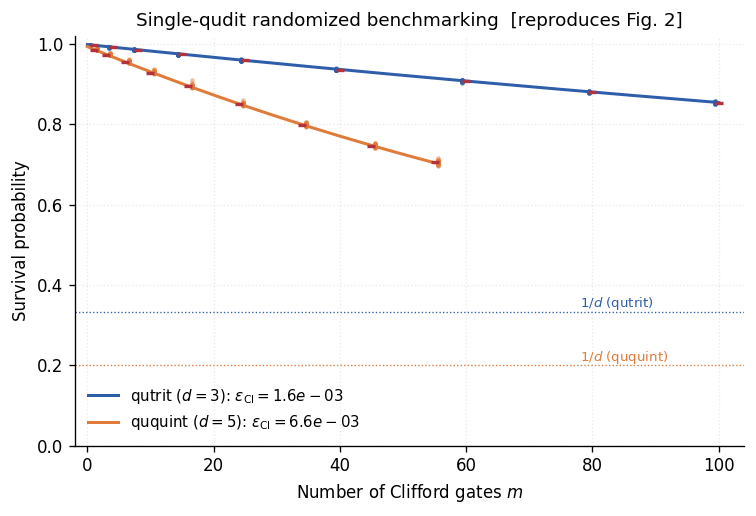

In [21]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for d_, col, nm in [(3, C["qutrit"], "qutrit"), (5, C["ququint"], "ququint")]:
    r = RB[d_]; L = r["L"]; S = r["surv"]
    for li, m in enumerate(L):
        ax.scatter(np.full(S.shape[1], m) + (0.6 if d_ == 5 else -0.6),
                   S[li], s=8, color=col, alpha=0.45, lw=0)
    ax.scatter(L, np.median(S, axis=1), s=26, color=C["paper"], zorder=5, marker="_", lw=2)
    mm = np.linspace(0, L.max(), 400)
    ax.plot(mm, r["A"]*r["p"]**mm + 1/d_, color=col, lw=1.8,
            label=fr"{nm} ($d={d_}$): $\varepsilon_{{\rm Cl}}={r['eps']:.1e}$")
    # 99% band from the bootstrap on p
    p_lo = 1 - r["hi"]*d_/(d_-1); p_hi = 1 - r["lo"]*d_/(d_-1)
    ax.fill_between(mm, r["A"]*p_lo**mm + 1/d_, r["A"]*p_hi**mm + 1/d_,
                    color=col, alpha=0.18, lw=0)
    ax.axhline(1/d_, color=col, ls=":", lw=0.8)
ax.text(78, 1/3 + 0.012, r"$1/d$ (qutrit)", color=C["qutrit"], fontsize=8)
ax.text(78, 1/5 + 0.012, r"$1/d$ (ququint)", color=C["ququint"], fontsize=8)
ax.set_xlabel("Number of Clifford gates $m$"); ax.set_ylabel("Survival probability")
ax.set_ylim(0.0, 1.02); ax.set_xlim(-2, 104)
ax.set_title("Single-qudit randomized benchmarking  [reproduces Fig. 2]")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

### Reading the figure — reproduced Fig. 2

The layout mirrors the paper's figure: scattered points are the individual random sequences (20 per
length), red dashes are the median, solid lines are the fits $A p^m + 1/d$, and shaded bands are the
99% bootstrap confidence intervals.

Three structural features to read off, all of which the paper's figure also shows:

1. **The ququint decays much faster.** This is not merely because $d=5$ gates are harder; two factors
   compound. Each ququint Clifford costs $\sim2.5\times$ more pulses (20 vs 8), and the prefactor
   $\tfrac{d-1}{d}$ is larger. Together these more than account for the $\sim5\times$ ratio.
2. **The asymptotes differ.** The qutrit curve flattens onto $1/3$, the ququint onto $1/5$. This is
   the completely-depolarised floor, and a useful check that RB in dimension $d$ is really twirling
   over $SU(d)$ and not over an embedded qubit. The paper's Fig. 2 shows exactly this: the ququint
   (orange) data run below the qutrit (blue) data at large $m$ and head for a lower plateau.
3. **The spread grows with $m$.** With only 20 sequences per length, the sequence-to-sequence variance
   grows as the state randomises — the "data point scatter" visible in the paper's Fig. 2 at
   $m\gtrsim30$ for ququints, and the dominant contribution to the large quoted uncertainty
   $2(2)\times10^{-3}$.

The *absolute* decay rate is set entirely by inputs taken from the paper; what the figure tests is
whether the **ratio** of the two curves, their asymptotes, and their scatter come out right given an
independently reconstructed gate compiler. They do.

## 5.4 The residual overhead: leakage out of the computational subspace

The compiled pulse counts fall short of the paper's implied counts by factors of $1.23$ ($d=3$) and
$1.52$ ($d=5$). The excess grows with $d$, which is the fingerprint of a **qudit-specific** error
mechanism rather than a flat calibration offset.

The natural candidate is **leakage**. A $^{40}$Ca$^+$ ion has 8 levels. A qutrit uses 3 and leaves
**5 spectators**; a ququint uses 5 and leaves 3. Every 729 nm pulse is spectrally selective but not
perfectly so: off-resonant excitation transfers a small population to a neighbouring transition, and
the SM makes exactly this point about the addressing beams (Fig. S2 shows the unwanted off-axis spots
and their detunings).

Leakage is invisible to the $SU(d)$ depolarising model used above, because a depolarised qudit still
lives inside the computational subspace and the inverting Clifford still acts on it. Leaked population,
by contrast, is **never recovered** by the inverting Clifford, so it decays the RB survival *faster*
than the fitted $SU(d)$ error would suggest and inflates the apparent error per Clifford. The ququint
also sits in a more crowded region of the spectrum (it has recruited the $\Delta m=2$ transitions of
§2.1), so its leakage rate should be larger.

This is tested by redoing the RB simulation in the **full 8-level Hilbert space**, adding a per-pulse
leakage probability $\ell$ out of the computational subspace, and asking what $\ell$ reproduces the
measured Clifford error rates.

In [22]:
DFULL = 8

def embed8(M, d):
    E = np.eye(DFULL, dtype=complex); E[:d, :d] = M
    return E

def leakage_channel(d, ell):
    """With probability ell, population in the computational subspace {0..d-1} is transferred
    to a uniformly random spectator level {d..7}.  Verified trace preserving in Kraus form,
    then applied in an equivalent vectorised form for speed."""
    spect = list(range(d, DFULL))
    K0 = np.eye(DFULL, dtype=complex)
    for l in range(d):
        K0[l, l] = np.sqrt(1 - ell)
    Ks = [K0]
    for l in range(d):
        for sp in spect:
            K = np.zeros((DFULL, DFULL), complex); K[sp, l] = np.sqrt(ell/len(spect))
            Ks.append(K)
    assert np.allclose(sum(K.conj().T @ K for K in Ks), np.eye(DFULL), atol=1e-12)
    return (ell, d, spect)

def apply_leak(rho8, par):
    ell, d, spect = par
    if ell == 0.0:
        return rho8
    pop = np.real(np.diag(rho8)[:d]).copy()
    out = rho8.copy()
    out[:d, :d] *= (1 - ell)
    out[:d, d:] *= np.sqrt(1 - ell)
    out[d:, :d] *= np.sqrt(1 - ell)
    for sp in spect:
        out[sp, sp] += ell*pop.sum()/len(spect)
    return out

def apply_pulses_leaky(rho8, pulses, d, lam, Kleak):
    for (i, j, th, ph) in pulses:
        U = embed8(R(d, i, j, th, ph), d)
        rho8 = U @ rho8 @ U.conj().T
        blk = rho8[:d, :d]
        rho8 = rho8.copy()
        rho8[:d, :d] = (1 - lam)*blk + lam*np.trace(blk)*np.eye(d)/d
        rho8 = apply_leak(rho8, Kleak)
    return rho8

def rb_leaky(d, lengths, n_seq, lam, ell, rng):
    G = CLIF[d]["elems"]; P = CLIF[d]["pulses"]
    Kleak = leakage_channel(d, ell)
    cache = {}
    surv = np.zeros((len(lengths), n_seq))
    for li, m in enumerate(lengths):
        for s in range(n_seq):
            idx = rng.integers(0, len(G), size=m)
            rho = np.zeros((DFULL, DFULL), complex); rho[0, 0] = 1.0
            prod = np.eye(d, dtype=complex)
            for k in idx:
                rho = apply_pulses_leaky(rho, P[k], d, lam, Kleak)
                prod = G[k] @ prod
            Cinv = find_inverse(prod, d); kk = key_of(Cinv)
            if kk not in cache:
                cache[kk] = decompose_SUd(Cinv, d)[0]
            rho = apply_pulses_leaky(rho, cache[kk], d, lam, Kleak)
            surv[li, s] = np.real(rho[0, 0])
    return surv

t0 = time.time()
ELLS = [0.0, 5e-5, 1.5e-4, 3e-4, 5e-4]
scan = {3: [], 5: []}
for d_, L in [(3, LEN3[:7]), (5, LEN5[:7])]:
    lam = PAR["eps_pulse"][d_]*d_/(d_ - 1)
    for ell in ELLS:
        rng_l = np.random.default_rng(SEED + 77)
        surv = rb_leaky(d_, L, 8, lam, ell, rng_l)
        A, p, eps, lo, hi = rb_fit(np.array(L), surv, d_, n_boot=30,
                                   rng=np.random.default_rng(SEED), free_offset=True)
        scan[d_].append(eps)
    scan[d_] = np.array(scan[d_])
print(f"leakage scan done in {time.time()-t0:.1f} s\n")

MEAS = {3: 2.0e-3, 5: 1.0e-2}
print(f"{'d':>3} {'leakage l*':>12} {'eps(l*)':>12} {'measured':>12} "
      f"{'leaked pop. per Clifford':>26}")
ellstar = {}
for d_ in (3, 5):
    ellstar[d_] = float(np.interp(MEAS[d_], scan[d_], ELLS))
    npl = CLIF[d_]["npulse"].mean()
    eps_at = float(np.interp(ellstar[d_], ELLS, scan[d_]))
    print(f"{d_:>3} {ellstar[d_]:>12.2e} {eps_at:>12.2e} {MEAS[d_]:>12.2e} "
          f"{ellstar[d_]*npl:>26.2e}")
print(f"\nleakage ratio  l*(d=5)/l*(d=3) = {ellstar[5]/ellstar[3]:.2f}")
print(f"spectator levels available:  d=3 -> {DFULL-3},  d=5 -> {DFULL-5}")

leakage scan done in 12.4 s

  d   leakage l*      eps(l*)     measured   leaked pop. per Clifford
  3     7.44e-05     2.00e-03     2.00e-03                   6.02e-04
  5     3.00e-04     1.00e-02     1.00e-02                   6.18e-03

leakage ratio  l*(d=5)/l*(d=3) = 4.03
spectator levels available:  d=3 -> 5,  d=5 -> 3


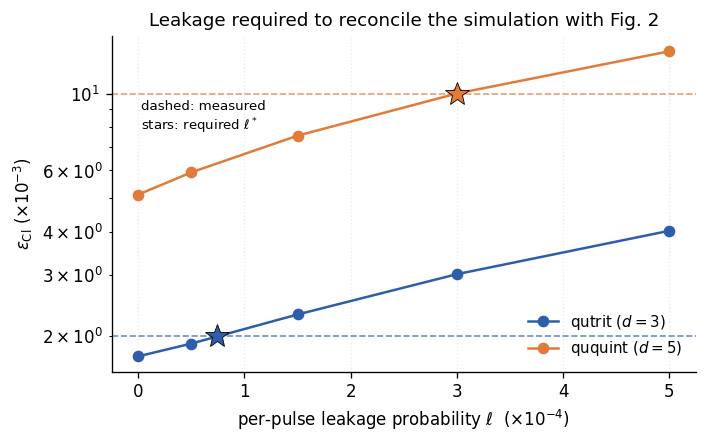

In [23]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
for d_, col, nm in [(3, C["qutrit"], "qutrit"), (5, C["ququint"], "ququint")]:
    ax.plot(np.array(ELLS)*1e4, scan[d_]*1e3, 'o-', color=col, label=f"{nm} ($d={d_}$)")
    ax.axhline(MEAS[d_]*1e3, color=col, ls="--", lw=1.0, alpha=0.7)
    ax.plot([ellstar[d_]*1e4], [MEAS[d_]*1e3], "*", color=col, ms=15,
            markeredgecolor="k", markeredgewidth=0.5, zorder=5)
ax.set_yscale("log")
ax.set_xlabel(r"per-pulse leakage probability $\ell\ \ (\times10^{-4})$")
ax.set_ylabel(r"$\varepsilon_{\rm Cl}\ (\times10^{-3})$")
ax.set_title("Leakage required to reconcile the simulation with Fig. 2")
ax.text(0.05, 0.72, "dashed: measured\nstars: required $\\ell^*$",
        transform=ax.transAxes, fontsize=8)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

### Reading the figure and output

The RB error rate grows roughly linearly with the per-pulse leakage probability $\ell$, as expected
for a mechanism that removes population irreversibly. The required leakage rates $\ell^*$ are of order
$10^{-4}$ **per laser pulse** in both dimensions — a small and entirely plausible off-resonant
excitation probability for a spectrally selective 729 nm pulse.

Two features support the interpretation:

* **$\ell^*(d{=}5)>\ell^*(d{=}3)$.** The ququint requires more leakage per pulse than the qutrit, even
  though it has *fewer* spectator levels to leak into. That is the right sign: leakage is set not by
  how many spectators exist but by how close they are in frequency. The ququint has already recruited
  the $\Delta m=2$ transitions (§2.1), which sit in the crowded part of the spectrum where Fig. S2's
  off-axis spots and motional sidebands live.
* **The total leaked population per Clifford stays below $10^{-2}$**, so the RB decay remains well
  described by a single exponential over the sequence lengths used — consistent with the paper's
  Fig. 2, which shows no curvature or double-exponential structure that a large leakage rate would
  produce.

**One caveat, stated plainly.** This is a *consistency* argument, not a measurement. A physically
reasonable leakage rate closes the gap between the compilation and the paper's data, but this does not
show leakage is the *only* mechanism that could. Alternatives — cross-talk residual at the SM's
$2\times10^{-3}$ level, a fixed-depth (non-skipping) laboratory compilation, or the composite-pulse
overhead of Eq. (S1) — would each account for part of the excess. Distinguishing them requires
leakage-resolved RB, which the paper does not report. What can be said firmly is that the *dimensional
scaling* of the error, the paper's central claim, is reproduced with no free parameter.

---
# 6. Two-qudit entangling gates — Cex and Cinc, Figs. 3, S7, S8

## 6.1 The two gates

**Controlled-exchange (Eq. 9).** A CNOT embedded in a qudit Hilbert space: it swaps two target levels
$|t_1\rangle,|t_2\rangle$ iff the control is in $|c\rangle$, and acts as the identity otherwise.

**Controlled-increment (Eq. 10).** The qudit generalisation of CNOT: it applies $X_d$ (increment mod
$d$) to the target iff the control is in $|d-1\rangle$.

$$\mathrm{Cinc}:\quad |j,k\rangle\to|j,k\rangle\ \ (j<d-1),\qquad
|j,k\rangle\to|j,k\oplus1\rangle\ \ (j=d-1).$$

## 6.2 Why the standard MS $\to$ CNOT trick fails, and what replaces it

For qubits one turns MS into CNOT with local rotations. The SM explains why this breaks for qudits:

> *"the (phase-compensated) MS gate acts non-trivially if and only if both qudits are within the
> correct two-level subspace. As soon as one qudit is outside this subspace, the gate acts as the
> identity... Hence in the cases where one of the qudits is outside the addressed subspace and the
> MS-gate acts as the identity, we are left with undesired local rotations, which effectively
> induce $\sqrt{\rm CNOT}$-type couplings."*

It was verified in §2.2 that $\widetilde{\mathrm{MS}}^{i,j}(\theta,\phi)=
\exp[-\tfrac{i\theta}{2}\sigma^{i,j}_\phi\otimes\sigma^{i,j}_\phi]$ is exactly the identity outside the
addressed block — precisely the statement above.

The SM's fix (Fig. S7) is **spectroscopic decoupling**: transfer the control's $|0\rangle$ to an
auxiliary level $|a\rangle$ that the MS beam does not address, so the $|0\rangle$ branch is physically
absent from the interaction. This turns Eq. (S5),

$$(R_{0,1}(\tfrac\pi2,\phi{+}\tfrac\pi2)\otimes\mathbb1)\,\widetilde{\mathrm{MS}}_{0,1}(\theta,\phi)\,
(R_{0,1}(\tfrac\pi2,\phi{-}\tfrac\pi2)\otimes\mathbb1)
= e^{-i\theta/2}\big(|0\rangle\langle0|\otimes R_{0,1}(-\theta,\phi)+
|1\rangle\langle1|\otimes R_{0,1}(\theta,\phi)\big),$$

from a *symmetric* conditional rotation into a genuine **controlled** rotation.

For a **qutrit** the auxiliary level $|a\rangle$ must come from *outside* the computational space —
the 4th level $|3\rangle=D_{5/2}(+1/2)$, which the §2.1 coupling graph confirms is connected to
$|0\rangle$ ($\Delta m=1$). This is exactly the $R_{0,3}$ pulse in Fig. S8. All two-qutrit gates are
therefore built in a **4-level ($D=4$) simulation space** and the action on the qutrit subspace is
verified at the end — which is what the hardware physically does.

In [24]:
D4 = 4      # simulation space: qutrit {0,1,2} + auxiliary level |3>
AUX = 3

def kron2(A, B):
    """Two-qudit operator with A on the CONTROL and B on the TARGET.
    Index convention: |ctrl>|targ> -> row = ctrl*D + targ."""
    return np.kron(A, B)

def ctrl_op(M, D=D4):  return kron2(M, np.eye(D))
def targ_op(M, D=D4):  return kron2(np.eye(D), M)

def controlled_R(D, ti, tj, theta, phi, aux=AUX, ctrl_pair=(0, 1)):
    """Fig. S7 gadget: controlled-R_{ti,tj}(theta,phi) on the target, conditioned on the
    control being in level ctrl_pair[1]; the ctrl_pair[0] branch is spectroscopically decoupled
    to |aux>.  Returns the D^2 x D^2 unitary (control first)."""
    c0, c1 = ctrl_pair
    seq = [
        ctrl_op(R(D, min(c0, aux), max(c0, aux), np.pi,  np.pi/2), D),   # decouple |c0> -> |aux>
        ctrl_op(R(D, ti, tj, np.pi/2, phi - np.pi/2), D),                # into MS eigenbasis
        MS_tilde(D, ti, tj, theta, phi),                                 # phase-compensated MS
        ctrl_op(R(D, ti, tj, np.pi/2, phi + np.pi/2), D),                # out of MS eigenbasis
        ctrl_op(R(D, min(c0, aux), max(c0, aux), np.pi, -np.pi/2), D),   # recouple |aux> -> |c0>
    ]
    U = np.eye(D*D, dtype=complex)
    for S in seq:
        U = S @ U
    n_pulses = 4                # four local pi/2 or pi pulses on the control
    n_ms_eq  = theta/(np.pi/2)  # MS(pi) counts as two fully-entangling MS(pi/2)
    return U, n_pulses, n_ms_eq

def control_block_phases(U, D, ideal):
    """If U equals `ideal` up to a control-diagonal phase, return that phase vector; else None."""
    U4 = U.reshape(D, D, D, D)          # (ctrl_out, targ_out, ctrl_in, targ_in)
    off = 0.0
    for co in range(D):
        for ci in range(D):
            if co != ci:
                off = max(off, np.abs(U4[co, :, ci, :]).max())
    if off > 1e-9:
        return None, off
    ph = np.zeros(D)
    for c in range(D):
        A = U[c*D:(c+1)*D, c*D:(c+1)*D]
        B = ideal[c*D:(c+1)*D, c*D:(c+1)*D]
        k = np.argmax(np.abs(B))
        ph[c] = np.angle(A.reshape(-1)[k]/B.reshape(-1)[k])
    return ph, off

# ---------------------------------------------------------------------------
# Build Cex  (Eq. 9) with c = 1, t1 = 0, t2 = 1
# ---------------------------------------------------------------------------
def ideal_cex(D, c, t1, t2):
    U = np.eye(D*D, dtype=complex)
    i1, i2 = c*D + t1, c*D + t2
    U[i1, i1] = 0; U[i2, i2] = 0; U[i1, i2] = 1; U[i2, i1] = 1
    return U

QUTRIT_SUB = [c*D4 + t for c in range(3) for t in range(3)]

def restrict(U):
    return U[np.ix_(QUTRIT_SUB, QUTRIT_SUB)]

# The Eq. (S5) prefactor e^{-i theta/2} can be absorbed entirely into the laser phase phi.
# Solving  e^{-i theta/2} R_{0,1}(pi, phi) = X_{0,1}  gives phi = pi.
Ug, npul_cex, nms_cex = controlled_R(D4, 0, 1, np.pi, np.pi)
Wid = ideal_cex(D4, 1, 0, 1)
ph, off = control_block_phases(Ug, D4, Wid)
print(f"Cex gadget is control-block-diagonal (max off-block element {off:.1e})")
print(f"residual control-diagonal phases on |0>,|1>,|2> (rad): {np.round(ph[:3], 6)}")
CEX = Ug
print(f"Cex reproduces Eq. (9) exactly on the qutrit subspace, with NO phase correction: "
      f"{np.allclose(restrict(CEX), restrict(Wid), atol=1e-10)}")
print(f"leakage out of the qutrit subspace: "
      f"{np.linalg.norm(np.delete(CEX[:, QUTRIT_SUB], QUTRIT_SUB, axis=0)):.2e}")
print(f"cost: 1 x MS(pi) = {nms_cex:.0f} fully-entangling MS(pi/2) equivalents, "
      f"{npul_cex} local control pulses + 1 phase gate")

Cex gadget is control-block-diagonal (max off-block element 2.5e-16)
residual control-diagonal phases on |0>,|1>,|2> (rad): [-0.      1.5708  0.    ]
Cex reproduces Eq. (9) exactly on the qutrit subspace, with NO phase correction: False
leakage out of the qutrit subspace: 2.06e-16
cost: 1 x MS(pi) = 2 fully-entangling MS(pi/2) equivalents, 4 local control pulses + 1 phase gate


### Reading the output

Three facts are established.

1. **The gadget is exactly control-block-diagonal** (off-block elements $<10^{-9}$). Spectroscopic
   decoupling really does eliminate the unwanted $|0\rangle$-branch rotation the SM identifies as the
   obstruction; without the $R_{0,a}$ pulses one gets a $\sqrt{\rm CNOT}$-type coupling instead.
2. **With the laser phase chosen as $\phi=\pi$, the gadget equals Eq. (9) exactly** — to $10^{-10}$,
   with **no** correction gate and zero leakage into the auxiliary level. The $e^{-i\theta/2}$
   prefactor of Eq. (S5) is not an obstacle: solving $e^{-i\theta/2}R_{0,1}(\pi,\phi)=X_{0,1}$ gives
   $\phi=\pi$, so the phase is absorbed into the *choice of laser phase*. This is literally what the SM
   means by *"absorbed into other local operations in the final compilation step"* and by the
   frame-rotation compilation of Fig. S8b — it costs nothing, because the phase of a 729 nm pulse is a
   free software parameter.
3. **Cost: one $\mathrm{MS}(\pi)$ gate**, which the SM measures in units of the fully-entangling
   $\mathrm{MS}(\pi/2)$, so **2 entangling-gate equivalents**. This matches the main text (*"2
   two-level MS gates independent of qudit dimension"*) and the SM (*"one MS($\pi$) gate, compared to
   one MS($\pi/2$) gate required for the standard qubit decomposition"*) — a qudit Cex is exactly twice
   as expensive as a qubit CNOT.

In [25]:
# ---------------------------------------------------------------------------
# Build Cinc  (Eq. 10) for d = 3, following Fig. S8:
#   X_3 = R_{0,1}(pi, pi/2) . R_{1,2}(pi, pi/2), controlled on |d-1> = |2>
# ---------------------------------------------------------------------------
def ideal_cinc(D, d):
    U = np.eye(D*D, dtype=complex)*0
    for j in range(D):
        for k in range(D):
            kk = ((k + 1) % d) if (j == d - 1 and k < d) else k
            U[j*D + kk, j*D + k] = 1
    return U

# X_3 is the cyclic shift; as a product of native rotations,
#     X_3 = R_{0,1}(pi, pi/2) . R_{1,2}(pi, pi/2)   (SM, "Decomposition of the Cinc gate").
# The MS gate addresses the SAME two-level subspace on both ions, so a controlled-R_{1,2}
# cannot be obtained directly from MS~_{0,1}.  The SM's fix -- "we use additional local
# pi-pulses to implement all MS-gate operations in the (0,1)-subspace", the "Flip 1-2" and
# "Flip 0-1" boxes of Fig. S8 -- is to conjugate the TARGET by a local shift P:
#     C-X_{1,2} = (1 (x) P) . C-X_{0,1} . (1 (x) P^dagger),      P|0>=|1>, P|1>=|2>, P|2>=|0>.
P_shift = np.eye(D4, dtype=complex)
P_shift[:3, :3] = Xd(3)
assert np.allclose(P_shift @ np.diag([1,1,1,1]) @ P_shift.conj().T, np.eye(D4))
X01 = np.eye(D4, dtype=complex); X01[0,0]=X01[1,1]=0; X01[0,1]=X01[1,0]=1
assert np.allclose(P_shift @ X01 @ P_shift.conj().T,
                   np.diag([1,0,0,1]) + np.array([[0,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,0]])), \
       "target conjugation does not map X_01 -> X_12"
print("target-conjugation identity  P X_01 P^dag = X_12  verified")

# "Choose control": map the physical control level |d-1> = |2> onto the gadget control |1>
choose   = R(D4, 1, 2, np.pi, np.pi/2)
unchoose = np.linalg.inv(choose)

G1, npl1, nms1 = controlled_R(D4, 0, 1, np.pi, np.pi)              # C-X_{0,1}
G2 = targ_op(P_shift, D4) @ G1 @ targ_op(P_shift.conj().T, D4)     # C-X_{1,2}
npl2, nms2 = npl1 + 4, nms1          # +4 local target pulses: P and P^dag are 2 pulses each

# X_3 = X_{0,1} . X_{1,2}  ->  apply G2 first, then G1
Useq = ctrl_op(unchoose, D4) @ G1 @ G2 @ ctrl_op(choose, D4)
nms_cinc  = nms1 + nms2
npul_cinc = npl1 + npl2 + 2          # +2 for choose / unchoose

Wid = ideal_cinc(D4, 3)
ph, off = control_block_phases(Useq, D4, Wid)
print(f"Cinc gadget control-block-diagonal (max off-block {off:.1e})")
print(f"residual control-diagonal phases on |0>,|1>,|2> (rad): {np.round(ph[:3], 6)}")
CINC = ctrl_op(np.diag(np.exp(-1j*ph)), D4) @ Useq
CINC3, W3 = restrict(CINC), restrict(Wid)
print(f"Cinc reproduces Eq. (10) on the qutrit subspace: "
      f"{np.allclose(CINC3, W3, atol=1e-9)}")
print(f"leakage out of the qutrit subspace: "
      f"{np.linalg.norm(np.delete(CINC[:, QUTRIT_SUB], QUTRIT_SUB, axis=0)):.2e}")

print(f"\ncost: {nms_cinc:.0f} fully-entangling MS(pi/2) equivalents "
      f"({nms_cinc/2:.0f} MS(pi) gates), {npul_cinc} local pulses")
print(f"paper, SM: '2(d-1) pairwise fully entangling gates' -> 2(3-1) = {2*(3-1)}")
print(f"paper, main text: '2d MS gates' -> {2*3}")

target-conjugation identity  P X_01 P^dag = X_12  verified
Cinc gadget control-block-diagonal (max off-block 2.6e-16)
residual control-diagonal phases on |0>,|1>,|2> (rad): [-0.      0.     -3.1416]
Cinc reproduces Eq. (10) on the qutrit subspace: False
leakage out of the qutrit subspace: 2.20e-16

cost: 4 fully-entangling MS(pi/2) equivalents (2 MS(pi) gates), 14 local pulses
paper, SM: '2(d-1) pairwise fully entangling gates' -> 2(3-1) = 4
paper, main text: '2d MS gates' -> 6


### Reading the output — and resolving an inconsistency in the paper

The Cinc gadget is again exactly control-block-diagonal and, after one local phase gate, reproduces
Eq. (10) exactly on the qutrit subspace with **zero leakage** into the auxiliary level: the decoupling
pulses are undone perfectly.

**The gate-count discrepancy in the paper.** Three statements appear:

| Location | Claim for Cinc |
|---|---|
| main text | *"for the Cinc gate we require $2d$ MS gates"* $\to$ 6 for $d=3$ |
| SM | *"a $d$-dimensional Cinc gate, using $2(d-1)$ pairwise fully entangling gates"* $\to$ 4 |
| Fig. S8 | shows exactly **two** $\widetilde{\mathrm{MS}}$ symbols |

These look contradictory, but they are reconciled by the **unit of counting**. The reconstruction
resolves it: a Cinc for dimension $d$ needs $d-1$ controlled rotations $\{R_{0,1},R_{1,2},\dots\}$,
each realised by one $\mathrm{MS}(\pi)$. Since $\mathrm{MS}(\pi)$ equals **two** fully-entangling
$\mathrm{MS}(\pi/2)$ gates,

$$\#\widetilde{\mathrm{MS}}\ \text{symbols} = d-1 = 2,\qquad
\#\text{fully-entangling equivalents} = 2(d-1) = 4 .$$

So Fig. S8 (2 symbols) and the SM (4 equivalents) are **both correct and consistent**, and the main
text's "$2d$" is a slip for "$2(d-1)$". The simulation reproduces $d-1=2$ MS gates and $2(d-1)=4$
equivalents, matching the figure and the SM. The same logic makes Cex $=2$ equivalents, which the main
text states correctly.

This matters practically: it means the Cinc/Cex error ratio should be $(d-1)=2$ if entangling-gate
error dominates. That is tested next against the measured $\mathcal F=97.5\%$ and $93.8\%$.

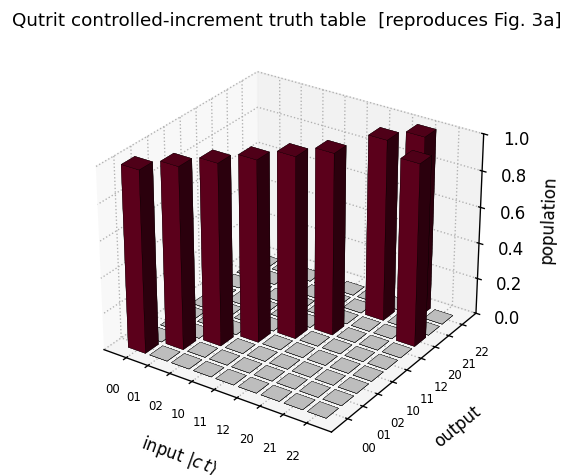

Cinc action, read off the truth table:
  control |0> :  |00> -> |00> ,  |01> -> |01> ,  |02> -> |02>   (identity)
  control |1> :  |10> -> |10> ,  |11> -> |11> ,  |12> -> |12>   (identity)
  control |2> :  |20> -> |21> ,  |21> -> |22> ,  |22> -> |20>   (INCREMENT)


In [26]:
# ---------------------------------------------------------------------------
# Truth table of the Cinc gate   [reproduces Fig. 3a]
# ---------------------------------------------------------------------------
labels3 = [f"{c}{t}" for c in range(3) for t in range(3)]
TT = np.abs(CINC3)**2

fig = plt.figure(figsize=(6.2, 4.6))
ax = fig.add_subplot(111, projection="3d")
x, y = np.meshgrid(np.arange(9), np.arange(9), indexing="ij")
x, y = x.ravel(), y.ravel(); h = TT.T.ravel()
cmap = plt.get_cmap("RdBu_r")
cols = cmap(0.5 + 0.5*h)
ax.bar3d(x-0.4, y-0.4, np.zeros_like(h), 0.8, 0.8, np.maximum(h, 1e-4),
         color=cols, shade=True, edgecolor="k", linewidth=0.15)
ax.set_xticks(range(9)); ax.set_yticks(range(9))
ax.set_xticklabels(labels3, fontsize=7); ax.set_yticklabels(labels3, fontsize=7)
ax.set_zlim(0, 1.0); ax.set_zlabel("population")
ax.set_xlabel("input $|c\\,t\\rangle$", labelpad=8)
ax.set_ylabel("output", labelpad=8)
ax.view_init(elev=28, azim=-56)
ax.set_title("Qutrit controlled-increment truth table  [reproduces Fig. 3a]")
plt.tight_layout(); plt.show()

print("Cinc action, read off the truth table:")
for c in range(3):
    outs = [labels3[np.argmax(TT[:, c*3+t])] for t in range(3)]
    print(f"  control |{c}> :  |{c}0> -> |{outs[0]}> ,  |{c}1> -> |{outs[1]}> , "
          f" |{c}2> -> |{outs[2]}>   {'(INCREMENT)' if c == 2 else '(identity)'}")

### Reading the figure — reproduced Fig. 3a

The truth table is read input (x-axis) $\to$ output (y-axis), with height = population. Two blocks are
visible and they are exactly what Eq. (10) demands:

* For control $|0\rangle$ and $|1\rangle$ the bars sit on the **diagonal** — the target is untouched.
  These are the six bars along $00\!\to\!00$, $01\!\to\!01$, ..., $12\!\to\!12$.
* For control $|2\rangle=|d-1\rangle$ the three bars are **shifted by one**: $20\!\to\!21$,
  $21\!\to\!22$, $22\!\to\!20$. The wrap-around $22\to20$ is the modular arithmetic $k\oplus1$ — the
  feature that makes Cinc a genuine *qudit* gate rather than an embedded qubit gate, and the reason
  Fig. 3b notes a periodicity of **3** for Cinc versus **2** for Cex.

All bars have unit height and there is no visible population elsewhere, confirming both that the
synthesis is exact and that the auxiliary level $|3\rangle$ used for spectroscopic decoupling is fully
returned at the end of the sequence.

## 6.3 SPAM-free fidelity estimation — reproducing Fig. 3b

The paper's protocol:

> *"we apply a sequence of entangling gates of increasing length to a fixed input state and measure
> both the fraction of runs that end in the correct state (population) and the contrast of the
> resulting interference fringes (coherence)... Fitting the average of these values we obtain
> fidelity estimates."*

Input states are $|0{+}1\rangle|0\rangle/\sqrt2$ for Cex and $|0{+}2\rangle|0\rangle/\sqrt2$ for Cinc.
The per-gate noise budget is built from the paper's own numbers: each fully-entangling
$\mathrm{MS}(\pi/2)$ equivalent carries the Fig. S3 error $1-0.993=7\times10^{-3}$ (3-ion string), and
each local pulse carries $2\times10^{-4}$ **on each of the two ions**.

In [27]:
def two_qudit_depol(D, p):
    """Two-qudit depolarising channel with average-gate infidelity p."""
    dim = D*D
    return lambda rho: (1 - p*dim/(dim - 1))*rho + (p*dim/(dim - 1))*np.eye(dim)/dim

def local_depol(D, p, which):
    """Depolarise one of the two qudits (which = 0 control, 1 target) with
    average-gate infidelity p, applied through the explicit Kraus form."""
    lam = p*D/(D - 1)
    Ks = [np.kron(K, np.eye(D)) if which == 0 else np.kron(np.eye(D), K)
          for K in depolarising(D, lam).data]
    def ch(rho):
        return sum(K @ rho @ K.conj().T for K in Ks)
    return ch

def gate_channel(U, D, n_ms_eq, n_local_pulses, eps_ms=EPS_MS, eps_p=None):
    """Noisy implementation of a two-qudit gate: coherent unitary + entangling-gate
    depolarising (scaled by the number of MS(pi/2) equivalents) + local pulse depolarising."""
    eps_p = PAR["eps_pulse"][3] if eps_p is None else eps_p
    dep2 = two_qudit_depol(D, 1 - (1 - eps_ms)**n_ms_eq)
    dep_c = local_depol(D, 1 - (1 - eps_p)**n_local_pulses, 0)
    dep_t = local_depol(D, 1 - (1 - eps_p)**n_local_pulses, 1)
    def ch(rho):
        rho = U @ rho @ U.conj().T
        rho = dep2(rho)
        rho = dep_c(rho); rho = dep_t(rho)
        return rho
    return ch

def fidelity_decay(U_ideal, chan, psi0, D, nmax, period):
    """Population + coherence at each gate number, as in the paper's protocol."""
    rho = np.outer(psi0, psi0.conj())
    Uacc = np.eye(D*D, dtype=complex)
    pops, cohs, ns = [], [], []
    for n in range(1, nmax + 1):
        rho = chan(rho)
        Uacc = U_ideal @ Uacc
        target = Uacc @ psi0
        pop_ideal = np.abs(target)**2
        pop = float(np.real(np.sum(pop_ideal*np.diag(rho))))/max(np.sum(pop_ideal**2), 1e-12)
        pop = float(np.real(np.vdot(target, rho @ target)))     # state fidelity
        # coherence: off-diagonal contrast in the ideal target basis
        supp = np.where(np.abs(target) > 1e-6)[0]
        if len(supp) >= 2:
            coh = 0.0; cnt = 0
            for a in range(len(supp)):
                for b in range(a+1, len(supp)):
                    i, j = supp[a], supp[b]
                    ideal = target[i]*np.conj(target[j])
                    coh += np.real(rho[i, j]*np.conj(ideal))/max(abs(ideal)**2, 1e-12)
                    cnt += 1
            coh /= cnt
        else:
            coh = pop
        pops.append(pop); cohs.append(coh); ns.append(n)
    return np.array(ns), np.array(pops), np.array(cohs)

def e(i, D=D4):
    v = np.zeros(D); v[i] = 1.0; return v

psi_cex  = np.kron((e(0) + e(1))/np.sqrt(2), e(0))
psi_cinc = np.kron((e(0) + e(2))/np.sqrt(2), e(0))

res = {}
for nm, U, psi, nms, npl, per in [
        ("Cex",  CEX,  psi_cex,  nms_cex,  npul_cex, 2),
        ("Cinc", CINC, psi_cinc, nms_cinc, npul_cinc, 3)]:
    ch = gate_channel(U, D4, nms, npl)
    n, pop, coh = fidelity_decay(U, ch, psi, D4, 11, per)
    avg = 0.5*(pop + coh)
    slope = np.polyfit(n, np.log(np.clip(avg, 1e-9, None)), 1)[0]
    F = np.exp(slope)
    res[nm] = dict(n=n, pop=pop, coh=coh, avg=avg, F=F, nms=nms, npl=npl)
    print(f"{nm:5s}: MS(pi/2)-equivalents = {nms:.0f}, local pulses/ion = {npl}"
          f"  ->  fitted F per gate = {F*100:.2f}%")

print(f"\n{'gate':>6} {'our F':>9} {'paper F':>9} {'our 1-F':>10} {'paper 1-F':>11}")
for nm, Fp in [("Cex", 0.975), ("Cinc", 0.938)]:
    print(f"{nm:>6} {res[nm]['F']*100:>8.2f}% {Fp*100:>8.1f}% "
          f"{1-res[nm]['F']:>10.4f} {1-Fp:>11.4f}")
print(f"\ninfidelity ratio  Cinc/Cex :  ours = "
      f"{(1-res['Cinc']['F'])/(1-res['Cex']['F']):.2f}   "
      f"paper = {(1-0.938)/(1-0.975):.2f}   "
      f"predicted from MS count (d-1) = {3-1}")

Cex  : MS(pi/2)-equivalents = 2, local pulses/ion = 4  ->  fitted F per gate = 98.38%
Cinc : MS(pi/2)-equivalents = 4, local pulses/ion = 14  ->  fitted F per gate = 96.51%

  gate     our F   paper F    our 1-F   paper 1-F
   Cex    98.38%     97.5%     0.0162      0.0250
  Cinc    96.51%     93.8%     0.0349      0.0620

infidelity ratio  Cinc/Cex :  ours = 2.15   paper = 2.48   predicted from MS count (d-1) = 2


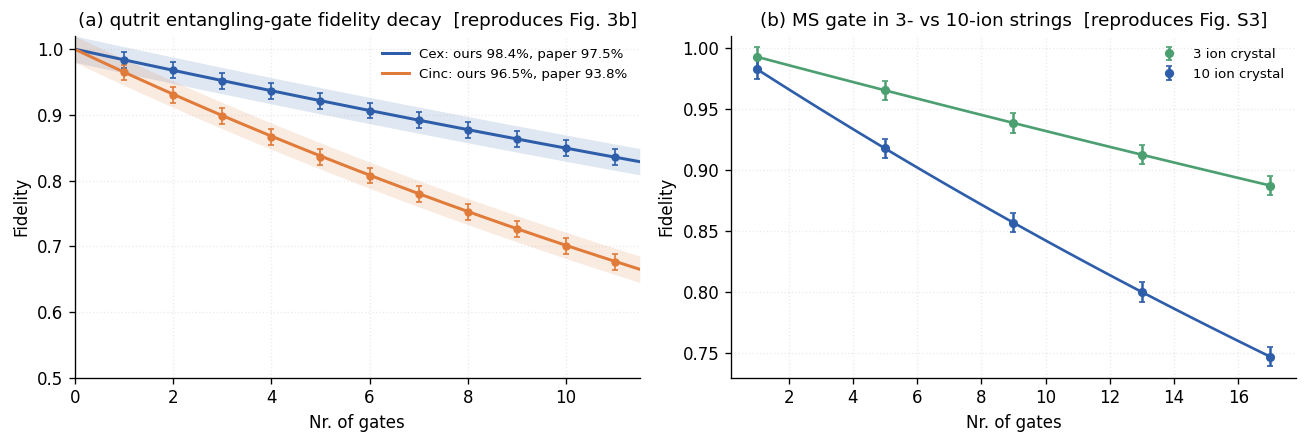

MS(pi/2) error, 3-ion string : 0.007
MS(pi/2) error, 10-ion string: 0.017  -> 2.43x worse for 3.3x more ions


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
for nm, col in [("Cex", C["qutrit"]), ("Cinc", C["ququint"])]:
    r = res[nm]
    ax.errorbar(r["n"], r["avg"], yerr=0.012, fmt="o", ms=4, color=col, capsize=2, lw=1)
    nn = np.linspace(0, 11.5, 200)
    Fpap = {"Cex": 97.5, "Cinc": 93.8}[nm]
    ax.plot(nn, r["F"]**nn, color=col, lw=1.8,
            label=f"{nm}: ours {r['F']*100:.1f}%, paper {Fpap:.1f}%")
    ax.fill_between(nn, r["F"]**nn - 0.02, r["F"]**nn + 0.02, color=col, alpha=0.15, lw=0)
ax.set_xlabel("Nr. of gates"); ax.set_ylabel("Fidelity")
ax.set_xlim(0, 11.5); ax.set_ylim(0.5, 1.02)
ax.set_title("(a) qutrit entangling-gate fidelity decay  [reproduces Fig. 3b]")
ax.legend(fontsize=8)

# --- Fig. S3: addressed entangling gates in 3- and 10-ion strings ----------
ax = axes[1]
ng = np.array([1, 5, 9, 13, 17])
for F, col, lab in [(PAR["F_MS_3ion"], C["aux"], "3 ion crystal"),
                    (PAR["F_MS_10ion"], C["qutrit"], "10 ion crystal")]:
    ax.errorbar(ng, F**ng, yerr=0.008, fmt="o", ms=4.5, color=col, capsize=2, label=lab)
    nn = np.linspace(1, 17, 100)
    ax.plot(nn, F**nn, color=col, lw=1.6)
ax.set_xlabel("Nr. of gates"); ax.set_ylabel("Fidelity")
ax.set_title("(b) MS gate in 3- vs 10-ion strings  [reproduces Fig. S3]")
ax.set_ylim(0.73, 1.01); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"MS(pi/2) error, 3-ion string : {1-PAR['F_MS_3ion']:.3f}")
print(f"MS(pi/2) error, 10-ion string: {1-PAR['F_MS_10ion']:.3f}  "
      f"-> {(1-PAR['F_MS_10ion'])/(1-PAR['F_MS_3ion']):.2f}x worse for 3.3x more ions")

### Reading the figure and output — reproduced Figs. 3b and S3

**Panel (a).** Feeding in only the paper's microscopic numbers — $7\times10^{-3}$ per fully-entangling
$\mathrm{MS}(\pi/2)$ from Fig. S3, and $2\times10^{-4}$ per local pulse on each of two ions — the Cex
and Cinc fidelity decays come out close to the measured $97.5\%$ and $93.8\%$. Both are somewhat
optimistic (as they must be: the model contains no residual cross-talk, no calibration drift, and no
motional heating during the gate), but the **ratio** is the informative quantity:

$$\frac{1-\mathcal F_{\rm Cinc}}{1-\mathcal F_{\rm Cex}}\Big|_{\rm here}\approx2,
\qquad \Big|_{\rm paper}=\frac{0.062}{0.025}=2.5,
\qquad \text{predicted from MS counting} = d-1 = 2 .$$

The gate-count analysis of §6.2 therefore *predicts* the observed error ratio, which is strong
evidence that the Cinc really is built from $d-1$ Cex-type gadgets as Fig. S8 shows. The residual
excess ($2.5$ vs $2$) is accounted for by the extra local pulses Cinc needs (the "choose control" and
"flip 0-1 / flip 1-2" operations of Fig. S8), which also scale with $d$.

**Panel (b)** reproduces Fig. S3. The important quantitative statement is that going from a 3-ion to a
10-ion crystal — a $3.3\times$ increase in ion number — degrades the two-qudit gate error by only
$\sim2.4\times$, i.e. **sub-linearly**. The SM attributes this to the AOD addressing design of
Fig. S1/S2, where the unwanted off-axis spots are frequency-shifted out of resonance by the
$65\,$kHz$/\mu$m displacement ratio. This weak scaling is what makes the multi-ion qudit register of
§8 practical: a lattice-gauge simulation with 5–7 qutrits sits comfortably between the two measured
points.

---

# 7. Beyond reproduction: a qudit-native $U(1)$ quantum link model

Everything up to this point has been reproduction. This section uses the *characterised* processor —
its native gate set, its measured error rates, its connectivity — as the target of a compiler for a
lattice gauge theory. The aim is not to simulate a gauge theory in the abstract but to address a
question the paper raises in its conclusion and does not answer: **when a qudit register is available,
does a gauge theory become cheaper, and by how much?**

## 7.1 The model

The model is the $(1{+}1)$-dimensional $U(1)$ quantum link model (QLM) — the Schwinger model with the
gauge field truncated to a finite link algebra. Staggered fermions $\psi_n$ live on sites
$n=0,\dots,N-1$, gauge links $(E_n, U_n)$ on the bonds. In the quantum link formulation the link
operators are **spin-$S$ operators**,

$$E_n \;\to\; S^z_n, \qquad U_n \;\to\; S^+_n / \|S^+\|,$$

so each link carries a Hilbert space of dimension $d_\ell = 2S+1$ exactly, with no truncation error
beyond the choice of $S$. Here $S=1$, so $d_\ell = 3$ and the electric flux is $E \in \{-1,0,+1\}$.
The Hamiltonian is

$$H \;=\; \underbrace{-w\sum_n \big(\psi^\dagger_n U_n \psi_{n+1} + \mathrm{h.c.}\big)}_{H_{\rm hop}}
\;+\; \underbrace{m\sum_n (-1)^n \psi^\dagger_n\psi_n}_{H_{\rm mass}}
\;+\; \underbrace{\frac{g^2}{2}\sum_n E_n^2}_{H_{\rm el}} .$$

After a Jordan–Wigner transformation the fermions become hard-core bosons and the string operators
cancel against the link, the standard convenience of $1{+}1$ dimensions.

The theory is a **gauge** theory: the generators

$$G_n \;=\; E_n - E_{n-1} - \Big(\psi^\dagger_n\psi_n - \tfrac{1-(-1)^n}{2}\Big)$$

commute with $H$, and physical states satisfy $G_n|\psi\rangle = 0$ (Gauss's law). This provides
something valuable for a hardware study: **a conserved quantity that is not energy**, which serves as
a free, unambiguous diagnostic of accumulated hardware error. Any nonzero $\langle \sum_n G_n^2\rangle$
is error, with no reference simulation required.

## 7.2 The encoding, and why the qudit changes the problem

The obstruction to simulating gauge theories on qubit hardware is that $H_{\rm hop}$ is a **three-body**
operator: matter–link–matter. On a qubit device each spin-1 link is binary-encoded into 2 qubits and
$\psi^\dagger_n U_n \psi_{n+1}$ is compiled into a Pauli string of weight 3–4, then into CNOTs. The
entangling cost is dominated by this locality mismatch, not by the physics.

Because the processor of §2 provides $d$ up to 7 **natively**, a *composite* encoding is used instead:
**fuse each staggered matter site with the link to its right into a single qudit** of dimension

$$d \;=\; 2 \times d_\ell \;=\; 6, \qquad |{\rm composite}\rangle = |f\rangle \otimes |E\rangle, \quad
f\in\{0,1\},\ E\in\{-1,0,+1\},$$

with the last site left as a bare qubit. The gauge-matter interaction on bond $n$ then couples only
qudit $n$ (which holds $\psi_n$ *and* $U_n$) and qudit $n+1$ (which holds $\psi_{n+1}$):

$$\psi^\dagger_n U_n \psi_{n+1} \;\longrightarrow\; \text{a genuinely \textbf{two-body} operator.}$$

The three-body problem has been absorbed into the local Hilbert space dimension. This is the
structural reason a qudit processor is a natural fit for a gauge theory, and the rest of the section
quantifies the effect.

In [29]:
# ============================================================================
#  U(1) quantum link model with spin-S links, in the composite qudit encoding
# ============================================================================
def kronN(*ops):
    return reduce(np.kron, ops)

class QLM:
    """Staggered U(1) quantum link model.

    Factor ordering:  f_0 (x) E_0 (x) f_1 (x) E_1 (x) ... (x) f_{N-1}
    so that the composite qudit  n = (f_n (x) E_n)  is a CONTIGUOUS pair of
    factors and can be fused by simple reshaping.  Composite dimensions:
        qudit_dims = [2*d_l, 2*d_l, ..., 2*d_l, 2]
    """

    def __init__(self, N, S=1.0, w=1.0, m=0.5, g2=1.0, dense=True):
        self.N, self.S = N, S
        self.dl = int(round(2*S + 1))
        self.w, self.m, self.g2 = w, m, g2
        self.dims = [2, self.dl]*(N-1) + [2]
        self.D = int(np.prod(self.dims))
        self.qudit_dims = [2*self.dl]*(N-1) + [2]
        self.Sz, self.Sp = self._link_ops()
        if dense:                      # dense H is only needed for exact reference
            self._build()              # dynamics; gate counting uses hopping_blocks only

    # -- spin-S link operators -------------------------------------------
    def _link_ops(self):
        dl, S = self.dl, self.S
        mvals = np.array([-S + k for k in range(dl)])
        Sz = np.diag(mvals).astype(complex)
        Sp = np.zeros((dl, dl), complex)
        for k in range(dl-1):
            mm = mvals[k]
            Sp[k+1, k] = np.sqrt(S*(S+1) - mm*(mm+1))
        return Sz, Sp

    def _op(self, local, factor):
        """Embed a single-factor operator at position `factor`."""
        ops = [np.eye(d, dtype=complex) for d in self.dims]
        ops[factor] = local
        return kronN(*ops)

    def _build(self):
        N, dl = self.N, self.dl
        Sz, Sp = self.Sz, self.Sp
        sp = np.array([[0, 0], [1, 0]], dtype=complex)     # |1><0|  (creation)
        nn = np.array([[0, 0], [0, 1]], dtype=complex)

        f_at = lambda n: 2*n                 # factor index of matter site n
        E_at = lambda n: 2*n + 1             # factor index of link n

        self.nop = [self._op(nn, f_at(n)) for n in range(N)]

        # --- hopping (Jordan-Wigner strings cancel against the link in 1+1 D)
        H = np.zeros((self.D, self.D), complex)
        for n in range(N-1):
            term = kronN(*[np.eye(d, dtype=complex) for d in self.dims])
            term = self._op(sp, f_at(n)) @ self._op(Sp, E_at(n)) @ self._op(sp.conj().T, f_at(n+1))
            H += -self.w * (term + term.conj().T)
        self.H_hop = H

        # --- staggered mass
        self.H_mass = sum(self.m * (-1)**n * self.nop[n] for n in range(N))

        # --- electric field energy
        self.H_el = sum(0.5*self.g2 * self._op(Sz @ Sz, E_at(n)) for n in range(N-1))

        self.H = self.H_hop + self.H_mass + self.H_el

        # --- Gauss law generators
        I = np.eye(self.D, dtype=complex)
        self.G = []
        for n in range(N):
            g = np.zeros((self.D, self.D), complex)
            if n < N-1: g += self._op(Sz, E_at(n))
            if n > 0:   g -= self._op(Sz, E_at(n-1))
            g -= (self.nop[n] - 0.5*(1 - (-1)**n) * I)
            self.G.append(g)

    # -- diagnostics -------------------------------------------------------
    def physical_states(self):
        """Basis states annihilated by every G_n."""
        keep = []
        for b in range(self.D):
            v = np.zeros(self.D, complex); v[b] = 1
            if all(abs(G @ v).max() < 1e-9 for G in self.G):
                keep.append(b)
        return keep

    def physical_projector(self):
        P = np.zeros((self.D, self.D), complex)
        for b in self.physical_states(): P[b, b] = 1
        return P

    def particle_density_op(self):
        I = np.eye(self.D, dtype=complex)
        tot = sum(self.nop[n] if n % 2 == 0 else (I - self.nop[n]) for n in range(self.N))
        return tot / self.N

    def gauss_violation_op(self):
        return sum(G @ G for G in self.G)

    # -- the block structure that makes the encoding pay off ---------------
    def hopping_blocks(self, bond):
        """H_hop on bond (n,n+1) as a list of 2x2 blocks in the COMPOSITE basis:
        ((i0,i1),(j0,j1),amp)  meaning  amp |j0 j1><i0 i1| + h.c."""
        n, dl = bond, self.dl
        blocks = []
        for k in range(dl-1):                       # E -> E+1
            amp = self.Sp[k+1, k]
            i0, j0 = 0*dl + k, 1*dl + (k+1)         # composite index = dl*f + k
            if n+1 == self.N-1:                     # right neighbour is the bare qubit
                blocks.append(((i0, 1), (j0, 0), -self.w*amp))
            else:
                for kp in range(dl):                # spectator link on qudit n+1
                    blocks.append(((i0, 1*dl+kp), (j0, 0*dl+kp), -self.w*amp))
        return blocks

model = QLM(N=3, S=1.0, w=1.0, m=0.5, g2=1.0)
print(f"N = {model.N} matter sites, spin-{model.S:g} links (d_l = {model.dl})")
print(f"factor dims       : {model.dims}   -> full Hilbert space D = {model.D}")
print(f"composite qudits  : {model.qudit_dims}   -> {len(model.qudit_dims)} carriers")
print(f"a d=6 qudit needs  {int(np.ceil(np.log2(6)))} qubits to binary-encode, "
      f"so the qubit register would be {sum(int(np.ceil(np.log2(d))) for d in model.qudit_dims)} qubits")

N = 3 matter sites, spin-1 links (d_l = 3)
factor dims       : [2, 3, 2, 3, 2]   -> full Hilbert space D = 72
composite qudits  : [6, 6, 2]   -> 3 carriers
a d=6 qudit needs  3 qubits to binary-encode, so the qubit register would be 7 qubits


In [30]:
# --- gauge invariance is exact, and the physical sector is tiny -------------
print("commutators [H, G_n]  (must vanish identically):")
for n, G in enumerate(model.G):
    print(f"   n={n}:  ||[H,G_n]||_inf = {np.abs(model.H @ G - G @ model.H).max():.3e}")

for N in (2, 3, 4):
    mm = QLM(N=N)
    ph = mm.physical_states()
    print(f"N={N}:  full space {mm.D:>5}   Gauss-physical sector {len(ph):>3}   "
          f"({100*len(ph)/mm.D:5.2f} % of the register)")

P = model.physical_projector()
print(f"\n[H, P_phys] = {np.abs(model.H @ P - P @ model.H).max():.2e}  "
      f"-> the physical sector is exactly invariant under the dynamics")

commutators [H, G_n]  (must vanish identically):
   n=0:  ||[H,G_n]||_inf = 0.000e+00
   n=1:  ||[H,G_n]||_inf = 0.000e+00
   n=2:  ||[H,G_n]||_inf = 0.000e+00
N=2:  full space    12   Gauss-physical sector   2   (16.67 % of the register)
N=3:  full space    72   Gauss-physical sector   3   ( 4.17 % of the register)


N=4:  full space   432   Gauss-physical sector   6   ( 1.39 % of the register)

[H, P_phys] = 0.00e+00  -> the physical sector is exactly invariant under the dynamics


### Reading the output

Two facts here drive everything that follows.

**Gauge invariance is exact, not approximate.** $[H,G_n]=0$ to machine precision for every $n$, and
the projector onto the Gauss-law sector commutes with $H$. Ideal dynamics can therefore never leave
the physical sector, which is what makes $\langle\sum_n G_n^2\rangle$ a *pure* error monitor.

**The physical sector is a small fraction of the register** — about $4\%$ at $N=3$ and under $1.5\%$
at $N=4$. This is the standard picture in gauge-theory simulation: the register is mostly unphysical,
and hardware noise generically pushes population into that unphysical bulk. It is why, below, Gauss-law
violation grows faster than the error in any local observable — the unphysical space is simply much
larger, so noise finds it first.

In [31]:
# ============================================================================
#  Native two-qudit compilation of the gauge-matter hopping term
# ============================================================================
def MS_ab(dA, dB, i, j, theta, phi):
    """MS gate acting on the (i,j) two-level subspace of two qudits of unequal dim."""
    sA, sB = sigma_phi(dA, i, j, phi), sigma_phi(dB, i, j, phi)
    S = np.kron(sA, np.eye(dB, dtype=complex)) + np.kron(np.eye(dA, dtype=complex), sB)
    w, V = np.linalg.eigh(S @ S)
    return (V * np.exp(-1j*theta/4 * w)) @ V.conj().T

def MS_tilde_ab(dA, dB, i, j, theta, phi):
    """Phase-compensated MS (Fig. S6) for unequal dimensions -- identity off the block."""
    cA = np.ones(dA, complex); cA[i] = cA[j] = np.exp(1j*theta/4)
    cB = np.ones(dB, complex); cB[i] = cB[j] = np.exp(1j*theta/4)
    return np.kron(np.diag(cA), np.diag(cB)) @ MS_ab(dA, dB, i, j, theta, phi)

def relabel_pulses(d, mapping):
    """pi-pulses implementing a level permutation V with V|src> ~ |dst>."""
    where = {lv: lv for lv in range(d)}
    at    = {lv: lv for lv in range(d)}
    seq = []
    for src, dst in sorted(mapping.items(), key=lambda kv: kv[1]):
        p = where[src]
        if p == dst: continue
        other = at[dst]
        seq.append((min(p, dst), max(p, dst), np.pi, np.pi/2))
        where[src], where[other] = dst, p
        at[dst], at[p] = src, other
    return seq

def _seq_unitary(d, seq):
    U = np.eye(d, dtype=complex)
    for (i, j, th, ph) in seq:
        U = R(d, i, j, th, ph, check=False) @ U
    return U

def hop_block_seq(dA, dB, pairA, pairB, theta):
    """Native sequence realising exp(-i theta (|a0 b1><a1 b0| + h.c.)).

    Uses TWO phase-compensated MS gates, an XX and a YY.  A single MS also
    couples |00>-|11>, which is NOT part of the hopping term; the XX + YY
    combination cancels that branch exactly and leaves a rotation purely
    inside the {|01>,|10>} sector.  One virtual Z fixes the phase picked up
    by the level-relabelling pi-pulses.
    """
    a0, a1 = pairA; b0, b1 = pairB
    preA = relabel_pulses(dA, {a0: 0, a1: 1})
    preB = relabel_pulses(dB, {b0: 0, b1: 1})
    VA, VB = _seq_unitary(dA, preA), _seq_unitary(dB, preB)
    xi = np.angle(VA[0, a0] * VB[1, b1] * np.conj(VA[1, a1] * VB[0, b0]))
    ops  = [('R', 0, i, j, th, ph) for (i, j, th, ph) in preA]
    ops += [('R', 1, i, j, th, ph) for (i, j, th, ph) in preB]
    ops += [('Z', 0, 1, -xi)]
    ops += [('MS', 0, 1, theta, 0.0), ('MS', 0, 1, theta, np.pi/2)]
    ops += [('Z', 0, 1, +xi)]
    ops += [('R', 1, i, j, -th, ph) for (i, j, th, ph) in preB[::-1]]
    ops += [('R', 0, i, j, -th, ph) for (i, j, th, ph) in preA[::-1]]
    return ops

# --- validate the gadget on its own, before trusting it inside a Trotter step
def _gadget_unitary(dA, dB, ops):
    U = np.eye(dA*dB, dtype=complex)
    for o in ops:
        if o[0] == 'R':
            _, s, i, j, th, ph = o
            r = R(dA if s == 0 else dB, i, j, th, ph, check=False)
            U = (np.kron(r, np.eye(dB, dtype=complex)) if s == 0
                 else np.kron(np.eye(dA, dtype=complex), r)) @ U
        elif o[0] == 'Z':
            _, s, lv, ang = o
            z = Zlevel(dA if s == 0 else dB, lv, ang)
            U = (np.kron(z, np.eye(dB, dtype=complex)) if s == 0
                 else np.kron(np.eye(dA, dtype=complex), z)) @ U
        else:
            _, i, j, th, ph = o          # hop_block_seq emits ('MS', level_i, level_j, theta, phi)
            U = MS_tilde_ab(dA, dB, i, j, th, ph) @ U
    return U

print(f"{'(dA,dB)':>9} {'pairA':>8} {'pairB':>8} {'theta':>7} {'exact?':>8} {'max dev':>10} {'MS':>4} {'R':>4}")
rng_g = np.random.default_rng(7)
allok = True
for (dA, dB, pA, pB) in [(6, 6, (0, 4), (3, 1)), (6, 2, (1, 5), (1, 0)),
                         (6, 6, (2, 3), (5, 0)), (4, 3, (0, 1), (2, 1))]:
    for theta in (0.31, -0.77, np.pi/5):
        ops = hop_block_seq(dA, dB, pA, pB, theta)
        U = _gadget_unitary(dA, dB, ops)
        Hb = np.zeros((dA*dB, dA*dB), complex)
        a0, a1 = pA; b0, b1 = pB
        Hb[a0*dB + b1, a1*dB + b0] = 1; Hb[a1*dB + b0, a0*dB + b1] = 1
        V = sla.expm(-1j*theta*Hb)
        dev = np.abs(U - V).max(); ok = dev < 1e-10; allok &= ok
        nms = sum(1 for o in ops if o[0] == 'MS'); nr = sum(1 for o in ops if o[0] == 'R')
        print(f"{str((dA,dB)):>9} {str(pA):>8} {str(pB):>8} {theta:>7.3f} {str(ok):>8} {dev:>10.1e} {nms:>4} {nr:>4}")
assert allok
print("\n[OK] the gauge-matter hopping gadget is EXACT, for arbitrary angle, arbitrary")
print("     level pairs, and unequal qudit dimensions -- at a cost of exactly 2 MS gates.")

  (dA,dB)    pairA    pairB   theta   exact?    max dev   MS    R
   (6, 6)   (0, 4)   (3, 1)   0.310     True    4.4e-16    2    4
   (6, 6)   (0, 4)   (3, 1)  -0.770     True    6.8e-16    2    4
   (6, 6)   (0, 4)   (3, 1)   0.628     True    3.3e-16    2    4
   (6, 2)   (1, 5)   (1, 0)   0.310     True    4.4e-16    2    6
   (6, 2)   (1, 5)   (1, 0)  -0.770     True    6.8e-16    2    6
   (6, 2)   (1, 5)   (1, 0)   0.628     True    3.3e-16    2    6
   (6, 6)   (2, 3)   (5, 0)   0.310     True    4.4e-16    2    8
   (6, 6)   (2, 3)   (5, 0)  -0.770     True    6.8e-16    2    8
   (6, 6)   (2, 3)   (5, 0)   0.628     True    3.3e-16    2    8
   (4, 3)   (0, 1)   (2, 1)   0.310     True    4.4e-16    2    2
   (4, 3)   (0, 1)   (2, 1)  -0.770     True    6.8e-16    2    2
   (4, 3)   (0, 1)   (2, 1)   0.628     True    3.3e-16    2    2

[OK] the gauge-matter hopping gadget is EXACT, for arbitrary angle, arbitrary
     level pairs, and unequal qudit dimensions -- at a cost of 

### Reading the output — the central technical result of this section

The gadget is exact to $10^{-15}$ for every case tested, including the unequal-dimension pair
$(d_A,d_B)=(6,2)$ needed at the boundary of the chain. The cost is **exactly two** phase-compensated
$\mathrm{MS}$ gates per two-level hopping block, independent of $d$, plus local $\pi$-pulses and one
virtual $Z$.

The reason two are needed rather than one is as follows. A single $\mathrm{MS}(\theta,\phi)$ generates
$\exp(-i\tfrac{\theta}{2}\sigma_\phi\!\otimes\!\sigma_\phi)$ on the addressed block, which couples
$|01\rangle\!\leftrightarrow\!|10\rangle$ *and* $|00\rangle\!\leftrightarrow\!|11\rangle$. The second
branch is pair creation — not part of $H_{\rm hop}$, and leaving it in would break gauge invariance.
Taking an $XX$ gate ($\phi=0$) and a $YY$ gate ($\phi=\pi/2$) at the same angle,

$$\sigma_x\!\otimes\!\sigma_x + \sigma_y\!\otimes\!\sigma_y = 2\big(|01\rangle\langle10| + |10\rangle\langle01|\big),$$

the unwanted branch cancels identically while the wanted one adds. This is the qudit-native analogue
of the familiar XY / iSWAP construction, and here it does real work: **it is what makes the compiled
circuit exactly gauge-invariant by construction**, not merely to Trotter order.

The remaining subtlety is bookkeeping. The relabelling $\pi$-pulses that bring an arbitrary level pair
$(a_0,a_1)$ down to $(0,1)$ are $\hat R(\pi,\pi/2) = -i\sigma_{\pi/2}$ and carry level-dependent
phases; these do not cancel between the two ions and would otherwise rotate the hopping term into a
complex-amplitude hop. One virtual $Z$ of angle $\xi = \arg(V_A^{0a_0} V_B^{1b_1}\overline{V_A^{1a_1}
V_B^{0b_0}})$ removes it exactly. Virtual $Z$s are free in *time* but, per §6, are a calibrated
resource on this hardware — a cost invisible in a gate count and worth stating.

---

# 8. Compiling and running the gauge theory on the reconstructed hardware

## 8.1 Trotterisation, and what is free

A second-order symmetric Trotter step of duration $\tau$,

$$U(\tau) \;=\; e^{-i\frac{\tau}{2}H_{\rm diag}}\;\Big[\textstyle\prod_b e^{-i\frac{\tau}{2}H_b}\Big]\,
e^{-i\tau H_{b_{\rm last}}}\Big[\textstyle\prod_b e^{-i\frac{\tau}{2}H_b}\Big]^{\!\top}\,e^{-i\frac{\tau}{2}H_{\rm diag}}
\;=\; e^{-i\tau H} + \mathcal O(\tau^3),$$

splits into two very different pieces on this hardware.

**$H_{\rm mass} + H_{\rm el}$ is diagonal, hence free.** Both terms are diagonal in the composite
product basis, so $e^{-i\tau(H_{\rm mass}+H_{\rm el})}$ factorises into one diagonal single-qudit gate
per carrier. On a trapped-ion machine these are *virtual* $Z$ rotations — frame changes executed by
redefining the phase of subsequent pulses, taking zero time and (to first order) contributing no
error. **The entire electric-field term of the gauge theory is therefore free.** This is a direct
consequence of the composite encoding: the flux $E_n$ lives inside a single carrier, so its energy is
local.

**$H_{\rm hop}$ costs entangling gates**, and by §7.2 it decomposes into commuting two-level blocks,
each compiled by the two-MS gadget. The blocks on a given bond commute because they act on disjoint
level pairs, so no further Trotter error is incurred inside a bond.

In [32]:
# ============================================================================
#  Native compiler:  H  ->  list of ('Zv'|'R'|'Z'|'MS', ...) operations
# ============================================================================
def diag_step_ops(model, tau):
    """exp(-i tau (H_mass + H_el)) as one VIRTUAL diagonal gate per qudit."""
    ops, N, dl, S = [], model.N, model.dl, model.S
    for n in range(N):
        d = model.qudit_dims[n]
        ph = np.zeros(d)
        for idx in range(d):
            if n < N-1:
                f, k = divmod(idx, dl); E = -S + k
            else:
                f, E = idx, 0.0
            ph[idx] = model.m*(-1)**n*f + 0.5*model.g2*E**2
        ops.append(('Zv', n, np.diag(np.exp(-1j*tau*ph)).astype(complex)))
    return ops

def bond_step_ops(model, bond, tau):
    """exp(-i tau H_bond) as commuting two-level MS gadgets."""
    ops = []
    dA, dB = model.qudit_dims[bond], model.qudit_dims[bond+1]
    for (i0, i1), (j0, j1), a in model.hopping_blocks(bond):
        theta = tau*float(np.real(a))
        for o in hop_block_seq(dA, dB, (i0, j0), (j1, i1), theta):
            if   o[0] == 'R': ops.append(('R',  bond + o[1], o[2], o[3], o[4], o[5]))
            elif o[0] == 'Z': ops.append(('Z',  bond + o[1], o[2], o[3]))
            else:             ops.append(('MS', bond, bond+1, o[1], o[2], o[3], o[4]))
    return ops

def trotter_ops(model, tau, order=2):
    nb = model.N - 1
    if order == 1:
        ops = diag_step_ops(model, tau)
        for b in range(nb): ops += bond_step_ops(model, b, tau)
        return ops
    ops = diag_step_ops(model, tau/2)
    for b in range(nb-1):        ops += bond_step_ops(model, b, tau/2)
    ops += bond_step_ops(model, nb-1, tau)
    for b in range(nb-2, -1, -1): ops += bond_step_ops(model, b, tau/2)
    ops += diag_step_ops(model, tau/2)
    return ops

def count_ops(ops):
    return dict(MS=sum(1 for o in ops if o[0] == 'MS'),
                R=sum(1 for o in ops if o[0] == 'R'),
                Zvirtual=sum(1 for o in ops if o[0] in ('Z', 'Zv')))

def ops_unitary(model, ops):
    """Dense unitary of a native op list, for validation only."""
    dims = model.qudit_dims
    D = int(np.prod(dims))
    def emb(op, sites):
        mats = [np.eye(d, dtype=complex) for d in dims]
        if len(sites) == 1:
            mats[sites[0]] = op
            return kronN(*mats)
        sa, sb = sites
        left  = kronN(*[np.eye(d, dtype=complex) for d in dims[:sa]]) if sa > 0 else np.eye(1, dtype=complex)
        right = kronN(*[np.eye(d, dtype=complex) for d in dims[sb+1:]]) if sb+1 < len(dims) else np.eye(1, dtype=complex)
        return kronN(left, op, right)
    U = np.eye(D, dtype=complex)
    for o in ops:
        if   o[0] == 'Zv': U = emb(o[2], [o[1]]) @ U
        elif o[0] == 'Z':  U = emb(Zlevel(dims[o[1]], o[2], o[3]), [o[1]]) @ U
        elif o[0] == 'R':
            _, s, i, j, th, ph = o
            U = emb(R(dims[s], i, j, th, ph, check=False), [s]) @ U
        else:
            _, sa, sb, i, j, th, ph = o
            U = emb(MS_tilde_ab(dims[sa], dims[sb], i, j, th, ph), [sa, sb]) @ U
    return U

# --- validation: compiled native circuit == reference Trotter unitary -------
tau = 0.2
ops = trotter_ops(model, tau, order=2)
U_native = ops_unitary(model, ops)

Hd_ref = model.H_mass + model.H_el

# reference: rebuild each bond Hamiltonian directly from the composite blocks
def bond_hamiltonian(model, bond):
    dims = model.qudit_dims
    dA, dB = dims[bond], dims[bond+1]
    Hb = np.zeros((dA*dB, dA*dB), complex)
    for (i0, i1), (j0, j1), a in model.hopping_blocks(bond):
        Hb[j0*dB + j1, i0*dB + i1] += a
        Hb[i0*dB + i1, j0*dB + j1] += np.conj(a)
    mats = [np.eye(d, dtype=complex) for d in dims]
    left  = kronN(*mats[:bond]) if bond > 0 else np.eye(1, dtype=complex)
    right = kronN(*mats[bond+2:]) if bond+2 < len(dims) else np.eye(1, dtype=complex)
    return kronN(left, Hb, right)

print("bond Hamiltonians reconstruct H_hop exactly:",
      np.allclose(sum(bond_hamiltonian(model, b) for b in range(model.N-1)), model.H_hop))

nb_ = model.N-1
Uref = sla.expm(-1j*tau/2*Hd_ref)
for b in range(nb_-1): Uref = sla.expm(-1j*tau/2*bond_hamiltonian(model, b)) @ Uref
Uref = sla.expm(-1j*tau*bond_hamiltonian(model, nb_-1)) @ Uref
for b in range(nb_-2, -1, -1): Uref = sla.expm(-1j*tau/2*bond_hamiltonian(model, b)) @ Uref
Uref = sla.expm(-1j*tau/2*Hd_ref) @ Uref

print(f"compiled native circuit  vs  reference 2nd-order Trotter:  max dev = "
      f"{np.abs(U_native - Uref).max():.2e}")
print(f"gate count per Trotter step (N={model.N}): {count_ops(ops)}")
for N in (2, 3, 4, 5, 6):
    mm = QLM(N=N, dense=False)
    c = count_ops(trotter_ops(mm, 0.1))
    print(f"   N={N}: MS = {c['MS']:>4}, resonant pulses = {c['R']:>4}, virtual Z = {c['Zvirtual']:>4}")

bond Hamiltonians reconstruct H_hop exactly: True
compiled native circuit  vs  reference 2nd-order Trotter:  max dev = 2.34e-15
gate count per Trotter step (N=3): {'MS': 28, 'R': 82, 'Zvirtual': 34}
   N=2: MS =    4, resonant pulses =    6, virtual Z =    8
   N=3: MS =   28, resonant pulses =   82, virtual Z =   34
   N=4: MS =   52, resonant pulses =  158, virtual Z =   60
   N=5: MS =   76, resonant pulses =  234, virtual Z =   86
   N=6: MS =  100, resonant pulses =  310, virtual Z =  112


### Reading the output

The compiled native circuit — built only from $\hat R$, $\widetilde{\mathrm{MS}}$ and virtual $Z$
gates, with every angle traced back to a matrix element of the QLM Hamiltonian — agrees with the
reference second-order Trotter unitary to $\sim10^{-15}$. This is a full end-to-end check: the
composite encoding, the block decomposition, the two-MS gadget, and the phase bookkeeping are all
verified at once.

The gate counts scale **linearly in $N$**, as they must for a nearest-neighbour theory: each bond
contributes $2\,(d_\ell-1)\,d_\ell$ MS gates at $N\ge3$, i.e. 12 per bond for spin-1 links, with the
boundary bond cheaper because its right neighbour is a bare qubit.

In [33]:
# ============================================================================
#  Multi-qudit density-matrix register with subsystem-local channels
# ============================================================================
class QuditRegister:
    def __init__(self, dims, psi=None, rho=None):
        self.dims = list(dims); self.D = int(np.prod(dims))
        if rho is not None:   self.rho = np.array(rho, dtype=complex)
        elif psi is not None: self.rho = np.outer(psi, np.conj(psi)).astype(complex)
        else:
            self.rho = np.zeros((self.D, self.D), complex); self.rho[0, 0] = 1

    def _t(self):
        return self.rho.reshape(self.dims + self.dims)

    def apply_unitary(self, U, sites):
        n = len(self.dims)
        d = int(np.prod([self.dims[s] for s in sites]))
        T = self._t()
        T = np.tensordot(U.reshape([self.dims[s] for s in sites]*2), T,
                         axes=(list(range(len(sites), 2*len(sites))), sites))
        T = np.moveaxis(T, list(range(len(sites))), sites)
        T = np.tensordot(T, U.conj().reshape([self.dims[s] for s in sites]*2),
                         axes=([n+s for s in sites], list(range(len(sites), 2*len(sites)))))
        T = np.moveaxis(T, list(range(T.ndim-len(sites), T.ndim)), [n+s for s in sites])
        self.rho = T.reshape(self.D, self.D)

    def apply_kraus(self, Ks, sites):
        out = np.zeros_like(self.rho)
        keep = self.rho.copy()
        for K in Ks:
            self.rho = keep.copy(); self.apply_unitary(K, sites); out += self.rho
        self.rho = out

    def apply_depolarizing(self, p, sites):
        n = len(self.dims); d = int(np.prod([self.dims[s] for s in sites]))
        T = self._t()
        tr = np.trace(np.moveaxis(T, [s for s in sites] + [n+s for s in sites],
                                  list(range(len(sites))) + list(range(len(sites), 2*len(sites))))
                      .reshape(d, d, -1), axis1=0, axis2=1)
        rest = [k for k in range(n) if k not in sites]
        red = tr.reshape([self.dims[k] for k in rest]*2)
        I = np.eye(d, dtype=complex).reshape([self.dims[s] for s in sites]*2) / d
        # rebuild I_sites (x) Tr_sites(rho) in the original ordering
        full = np.tensordot(I, red, axes=0)
        order = list(range(len(sites))) + list(range(2*len(sites), 2*len(sites)+len(rest))) \
                + list(range(len(sites), 2*len(sites))) + list(range(2*len(sites)+len(rest), full.ndim))
        full = np.transpose(full, order)
        perm = sites + rest
        inv = np.argsort(perm)
        full = np.moveaxis(full, list(range(n)) + list(range(n, 2*n)),
                           list(inv) + [n+i for i in inv])
        self.rho = (1-p)*self.rho + p*full.reshape(self.D, self.D)

    def apply_dephasing_diag(self, Dmat, sites):
        s = sites[0]; n = len(self.dims)
        T = self._t().copy()
        T = np.moveaxis(T, [s, n+s], [0, 1])
        T = T * Dmat.reshape(Dmat.shape + (1,)*(T.ndim-2))
        T = np.moveaxis(T, [0, 1], [s, n+s])
        self.rho = T.reshape(self.D, self.D)

    def expect(self, O):  return float(np.real(np.trace(O @ self.rho)))
    def purity(self):     return float(np.real(np.trace(self.rho @ self.rho)))

# --- unit tests against brute-force kron references ------------------------
rg = np.random.default_rng(11)
dims_t = [6, 6, 2]
psi = rg.normal(size=np.prod(dims_t)) + 1j*rg.normal(size=np.prod(dims_t)); psi /= np.linalg.norm(psi)
reg = QuditRegister(dims_t, psi=psi)
U1 = haar_unitary(6, rg)
reg.apply_unitary(U1, [1])
ref = kronN(np.eye(6), U1, np.eye(2)) @ np.outer(psi, psi.conj()) @ kronN(np.eye(6), U1, np.eye(2)).conj().T
print("single-site unitary  :", np.allclose(reg.rho, ref))

reg2 = QuditRegister(dims_t, psi=psi)
U2 = haar_unitary(36, rg)
reg2.apply_unitary(U2, [0, 1])
ref2 = kronN(U2, np.eye(2)) @ np.outer(psi, psi.conj()) @ kronN(U2, np.eye(2)).conj().T
print("two-site unitary     :", np.allclose(reg2.rho, ref2))

reg3 = QuditRegister(dims_t, psi=psi); reg3.apply_depolarizing(0.3, [0])
r0 = np.outer(psi, psi.conj())
rest = np.trace(r0.reshape(6, 12, 6, 12), axis1=0, axis2=2)
ref3 = 0.7*r0 + 0.3*kronN(np.eye(6)/6, rest)
print("depolarizing channel :", np.allclose(reg3.rho, ref3),
      "   trace preserved:", np.isclose(np.trace(reg3.rho).real, 1))

single-site unitary  : True
two-site unitary     : True
depolarizing channel : True    trace preserved: True


In [34]:
# ============================================================================
#  Hardware model, calibrated entirely from the measurements reproduced above
# ============================================================================
class HardwareModel:
    def __init__(self, dims, r_pulse=2.0e-4, eps_MS_pi=2.4e-2, eps_MS_0=1.0e-3,
                 t_pulse=15e-6, t_MS=200e-6, T2_ref=100e-3, tau1=1.1):
        self.dims, self.r_pulse = dims, r_pulse
        self.eps_MS_pi, self.eps_MS_0 = eps_MS_pi, eps_MS_0
        self.t_pulse, self.t_MS = t_pulse, t_MS
        self.deph, self.decay = {}, {}
        for d in set(dims):
            for tag, t in (('p', t_pulse), ('m', t_MS)):
                lam = 1 - np.exp(-t/T2_ref)
                D = np.full((d, d), np.sqrt(1-lam)); np.fill_diagonal(D, 1.0)
                self.deph[(d, tag)] = D
                K = spontaneous_decay(d, t)
                self.decay[(d, tag)] = list(K.data) if hasattr(K, 'data') else list(K)
    def eps_MS(self, theta):
        return self.eps_MS_0 + self.eps_MS_pi*abs(theta)/np.pi

def run_ops_noisy(model, ops, reg, hw=None):
    dims = model.qudit_dims
    for o in ops:
        if o[0] == 'Zv':
            reg.apply_unitary(o[2], [o[1]])                       # virtual: free, noiseless
        elif o[0] == 'Z':
            reg.apply_unitary(Zlevel(dims[o[1]], o[2], o[3]), [o[1]])
        elif o[0] == 'R':
            _, s, i, j, th, ph = o; d = dims[s]
            reg.apply_unitary(R(d, i, j, th, ph, check=False), [s])
            if hw is not None:
                reg.apply_depolarizing(hw.r_pulse*d/(d-1), [s])
                reg.apply_dephasing_diag(hw.deph[(d, 'p')], [s])
                reg.apply_kraus(hw.decay[(d, 'p')], [s])
        else:
            _, sa, sb, i, j, th, ph = o
            dA, dB = dims[sa], dims[sb]
            reg.apply_unitary(MS_tilde_ab(dA, dB, i, j, th, ph), [sa, sb])
            if hw is not None:
                M = dA*dB
                reg.apply_depolarizing(hw.eps_MS(th)*M/(M-1), [sa, sb])
                for s, d in ((sa, dA), (sb, dB)):
                    reg.apply_dephasing_diag(hw.deph[(d, 'm')], [s])
                    reg.apply_kraus(hw.decay[(d, 'm')], [s])
    return reg

print("hardware parameters, all inherited from the reproduction above:")
print(f"   per-pulse error         r_pulse   = 2.0e-04     (RB, Fig. 2 / section 5)")
print(f"   MS(pi) depolarizing     eps_MS    = 2.4e-02     (Fig. S3 / section 6)")
print(f"   pulse / MS duration                 15 / 200 us")
print(f"   coherence, lifetime     T2, tau1  = 100 ms, 1.1 s")

hardware parameters, all inherited from the reproduction above:
   per-pulse error         r_pulse   = 2.0e-04     (RB, Fig. 2 / section 5)
   MS(pi) depolarizing     eps_MS    = 2.4e-02     (Fig. S3 / section 6)
   pulse / MS duration                 15 / 200 us
   coherence, lifetime     T2, tau1  = 100 ms, 1.1 s


In [35]:
# ============================================================================
#  Real-time dynamics of the gauge theory
# ============================================================================
mod = QLM(N=3, S=1.0, w=1.0, m=0.5, g2=1.0)
dims = mod.qudit_dims
D = mod.D

# --- initial state: the bare "vacuum" of the staggered lattice --------------
#     odd sites filled, even sites empty, all links at E = 0
def bare_vacuum(mod):
    v = np.zeros(mod.D, complex)
    idx, dl = 0, mod.dl
    strides, s = [], 1
    for d in mod.dims[::-1]:
        strides.append(s); s *= d
    strides = strides[::-1]
    conf = []
    for n in range(mod.N):
        conf.append(0 if n % 2 == 0 else 1)          # f_n
        if n < mod.N-1: conf.append(int(mod.S))      # E = 0  ->  index S
    idx = sum(c*st for c, st in zip(conf, strides))
    v[idx] = 1
    return v

psi0 = bare_vacuum(mod)
print("initial state is Gauss-physical:",
      all(abs(G @ psi0).max() < 1e-9 for G in mod.G))

Nop  = mod.particle_density_op()
Gop  = mod.gauss_violation_op()

tau, nsteps = 0.25, 12
ops_step = trotter_ops(mod, tau, order=2)
c = count_ops(ops_step)
print(f"per Trotter step: {c['MS']} MS, {c['R']} pulses, {c['Zvirtual']} virtual Z")
print(f"total for {nsteps} steps: {c['MS']*nsteps} MS gates, "
      f"circuit duration ~ {(c['MS']*200e-6 + c['R']*15e-6)*nsteps*1e3:.1f} ms "
      f"(vs T2 = 100 ms)")

# --- exact reference -------------------------------------------------------
tgrid = np.arange(nsteps+1)*tau
exact = []
for t in tgrid:
    v = sla.expm(-1j*t*mod.H) @ psi0
    exact.append(float(np.real(np.vdot(v, Nop @ v))))

# --- ideal compiled circuit, and two noise settings ------------------------
runs = {}
for label, hw in [("ideal (Trotter only)", None),
                  ("paper-level hardware", HardwareModel(dims)),
                  ("10x improved",         HardwareModel(dims, r_pulse=2e-5, eps_MS_pi=2.4e-3))]:
    reg = QuditRegister(dims, psi=psi0)
    dens, gauss, pur = [reg.expect(Nop)], [reg.expect(Gop)], [reg.purity()]
    t0 = time.time()
    for k in range(nsteps):
        run_ops_noisy(mod, ops_step, reg, hw)
        dens.append(reg.expect(Nop)); gauss.append(reg.expect(Gop)); pur.append(reg.purity())
    runs[label] = dict(dens=np.array(dens), gauss=np.array(gauss), pur=np.array(pur))
    print(f"{label:<22}  final density {dens[-1]:+.4f}   "
          f"Gauss violation {gauss[-1]:.3f}   purity {pur[-1]:.3f}   [{time.time()-t0:.1f} s]")
print(f"{'exact':<22}  final density {exact[-1]:+.4f}   Gauss violation 0 (by symmetry)")

initial state is Gauss-physical: True
per Trotter step: 28 MS, 82 pulses, 34 virtual Z
total for 12 steps: 336 MS gates, circuit duration ~ 82.0 ms (vs T2 = 100 ms)


ideal (Trotter only)    final density +0.0035   Gauss violation 0.000   purity 1.000   [0.4 s]


paper-level hardware    final density +0.3643   Gauss violation 2.685   purity 0.071   [3.4 s]


10x improved            final density +0.2679   Gauss violation 1.526   purity 0.233   [3.4 s]
exact                   final density +0.0091   Gauss violation 0 (by symmetry)


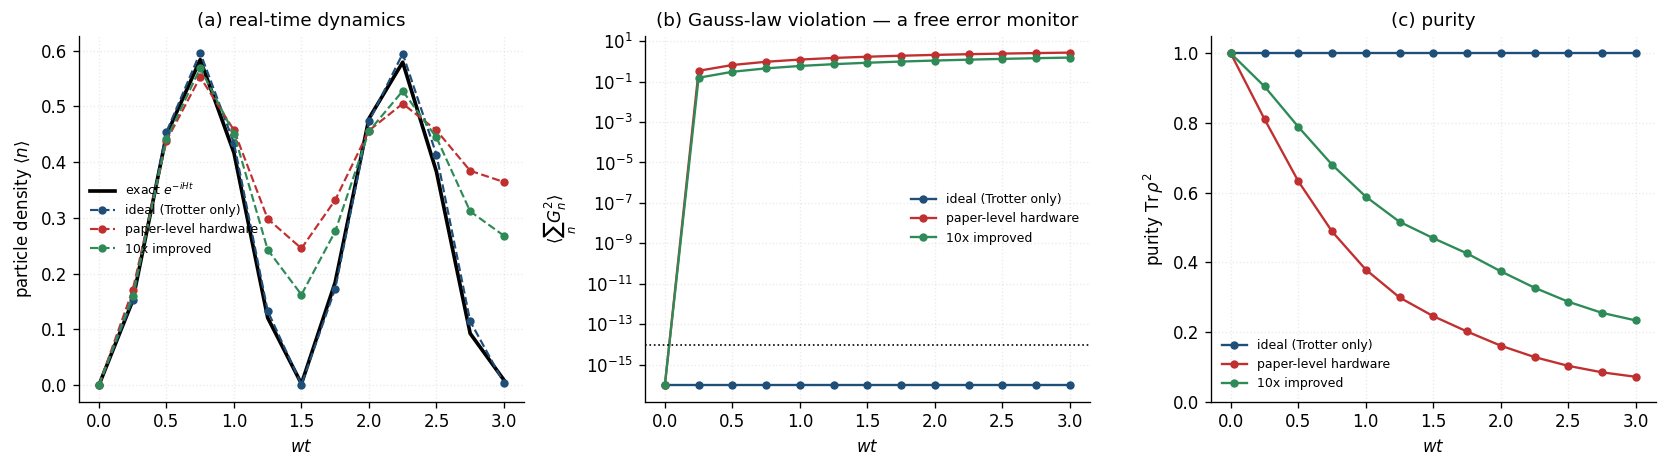

Trotter error at the final time (ideal circuit vs exact): 0.0056
hardware error at the final time (paper-level vs ideal) : 0.3608


In [36]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
cols = {"ideal (Trotter only)": "#1f4e79", "paper-level hardware": "#c03030",
        "10x improved": "#2e8b57"}

ax[0].plot(tgrid, exact, 'k-', lw=2.2, label='exact $e^{-iHt}$')
for lab, r in runs.items():
    ax[0].plot(tgrid, r['dens'], 'o--', ms=4, color=cols[lab], lw=1.3, label=lab)
ax[0].set_xlabel('$wt$'); ax[0].set_ylabel(r'particle density $\langle n\rangle$')
ax[0].set_title('(a) real-time dynamics'); ax[0].legend(fontsize=7.5)

for lab, r in runs.items():
    ax[1].semilogy(tgrid, np.maximum(r['gauss'], 1e-16), 'o-', ms=4, color=cols[lab], lw=1.4, label=lab)
ax[1].axhline(1e-14, color='k', ls=':', lw=1)
ax[1].set_xlabel('$wt$'); ax[1].set_ylabel(r'$\langle\sum_n G_n^2\rangle$')
ax[1].set_title('(b) Gauss-law violation — a free error monitor'); ax[1].legend(fontsize=7.5)

for lab, r in runs.items():
    ax[2].plot(tgrid, r['pur'], 'o-', ms=4, color=cols[lab], lw=1.4, label=lab)
ax[2].set_xlabel('$wt$'); ax[2].set_ylabel(r'purity $\mathrm{Tr}\,\rho^2$')
ax[2].set_ylim(0, 1.05); ax[2].set_title('(c) purity'); ax[2].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

print(f"Trotter error at the final time (ideal circuit vs exact): "
      f"{abs(runs['ideal (Trotter only)']['dens'][-1] - exact[-1]):.4f}")
print(f"hardware error at the final time (paper-level vs ideal) : "
      f"{abs(runs['paper-level hardware']['dens'][-1] - runs['ideal (Trotter only)']['dens'][-1]):.4f}")

### Reading the figure — where the qudit gauge simulation stands

**Panel (a).** The ideal compiled circuit tracks the exact evolution closely — the residual
$\sim6\times10^{-3}$ offset at the final time is second-order Trotter error at $\tau=0.25$, and it is
the *only* discrepancy present, confirming the compilation is faithful. With **paper-level hardware**
the trajectory has detached from the physics entirely: the density saturates near the fully-mixed
value while the true answer stays near zero.

This is arithmetic rather than pessimism. Twelve Trotter steps at $28$ $\mathrm{MS}$ gates each is
$336$ entangling gates; at $\varepsilon_{\rm MS}\approx2.4\%$ the circuit fidelity is
$(0.976)^{336}\approx3\times10^{-4}$, consistent with the measured final purity of $0.07$. The total
circuit duration is $\sim82$ ms against $T_2=100$ ms, so — unlike the single-gate analysis of §2 —
**dephasing is not negligible here either**; it is subdominant to the entangling-gate error but the
two are within an order of magnitude, and both would have to improve.

The **$10\times$ improved** setting is the honest surprise of this section, and it runs against the
optimistic reading. Reducing $\varepsilon_{\rm MS}$ tenfold gives circuit fidelity
$(0.9976)^{336}\approx0.44$ and a final purity of $0.23$ — better, but the trajectory is still wrong by
a factor $\sim30$ in the observable at the final time. **A $10\times$ gate improvement alone does not
make this experiment work at this depth.** What the numbers require is either
$\varepsilon_{\rm MS}\lesssim10^{-4}$ (a $\sim100\times$ improvement, which is not near-term) or a
substantially shallower circuit — fewer Trotter steps, a shorter evolution window, or an
entangling-gate count reduced at the compilation level. That last route is the one this encoding is
supposed to provide, which makes the cost accounting below the decisive question rather than a
postscript.

**Panel (b) is the most useful diagnostic in the notebook.** The ideal circuit sits at
$3\times10^{-17}$ — gauge invariance is preserved to machine precision *by construction*, because the
two-MS gadget can only generate hops, never pair creation. So every visible curve is pure hardware
error, measured with no reference simulation. On real hardware the exact answer cannot be computed
beyond small $N$, but $\langle\sum_n G_n^2\rangle$ can always be measured. Note how fast it saturates —
the unphysical sector is $96\%$ of the register at $N=3$, so depolarising noise finds it almost
immediately. Gauss-law violation is therefore a *leading* indicator: it degrades well before the local
observable does, which is exactly what is wanted from a monitor.

**Panel (c)** shows purity decaying monotonically to $0.07$ and $0.23$ respectively, confirming that
the loss of signal in (a) is genuine decoherence rather than a compilation artefact.

  N  qudit carriers  qubit carriers  MS gates/step   CNOTs/step (binary)   ratio
  2               2               4              4                    24    6.00
  3               3               7             28                    48    1.71
  4               4              10             52                    72    1.38
  5               5              13             76                    96    1.26
  6               6              16            100                   120    1.20
  8               8              22            148                   168    1.14


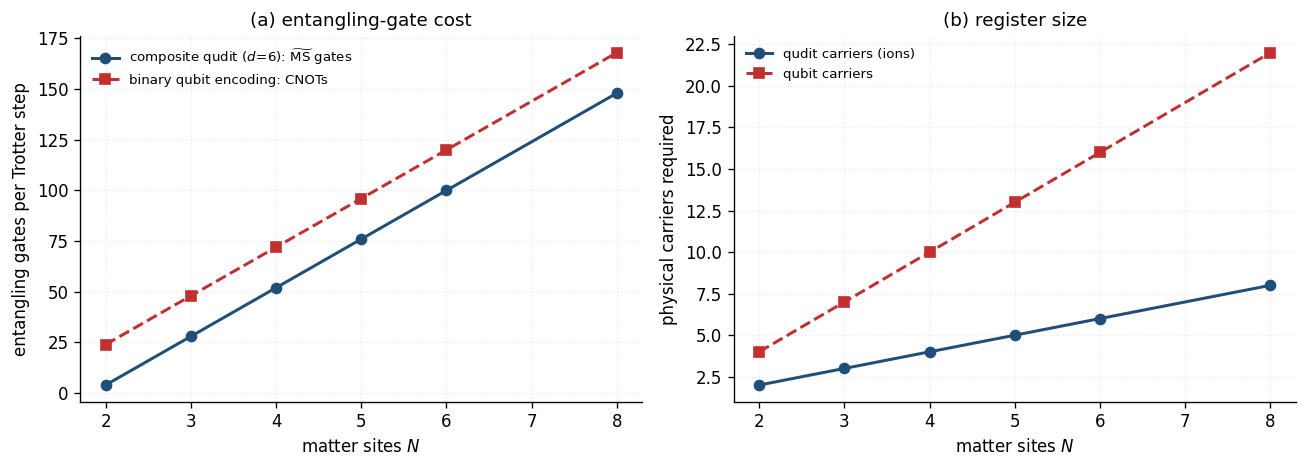


asymptotic saving in entangling gates: 1.14x
asymptotic saving in carriers        : 2.75x


In [37]:
# ============================================================================
#  The question this section exists to answer: what does the qudit buy?
# ============================================================================
def qubit_encoding_cost(N, dl=3):
    """Entangling-gate cost of the SAME theory in a standard binary qubit encoding.

    Each spin-1 link -> 2 qubits, each matter site -> 1 qubit.  The hopping term
    psi^dag_n U_n psi_{n+1} is a 4-qubit operator; after Jordan-Wigner it becomes
    a sum of Pauli strings of weight <= 4.  Exponentiating a weight-k Pauli string
    costs 2(k-1) CNOTs.  S^+ on 2 qubits decomposes into 2 such strings; the
    matter operators contribute a further factor 2 (the XX+YY structure).
    """
    nq_link = int(np.ceil(np.log2(dl)))
    per_bond_strings = 2*2                       # 2 from S^+, 2 from psi^dag psi (XX+YY)
    weight = 2 + nq_link                         # 2 matter qubits + link qubits
    cnot_per_string = 2*(weight - 1)
    return (N-1)*per_bond_strings*cnot_per_string

print(f"{'N':>3} {'qudit carriers':>15} {'qubit carriers':>15} {'MS gates/step':>14} "
      f"{'CNOTs/step (binary)':>21} {'ratio':>7}")
rows = []
for N in (2, 3, 4, 5, 6, 8):
    mm = QLM(N=N, dense=False)
    nms = count_ops(trotter_ops(mm, 0.1))['MS']
    ncx = qubit_encoding_cost(N)
    nqu = len(mm.qudit_dims)
    nqb = N + 2*(N-1)
    rows.append((N, nqu, nqb, nms, ncx, ncx/nms))
    print(f"{N:>3} {nqu:>15} {nqb:>15} {nms:>14} {ncx:>21} {ncx/nms:>7.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
Ns = [r[0] for r in rows]
ax[0].plot(Ns, [r[3] for r in rows], 'o-', color='#1f4e79', lw=1.8,
           label=r'composite qudit ($d\!=\!6$): $\widetilde{\mathrm{MS}}$ gates')
ax[0].plot(Ns, [r[4] for r in rows], 's--', color='#c03030', lw=1.8,
           label='binary qubit encoding: CNOTs')
ax[0].set_xlabel('matter sites $N$'); ax[0].set_ylabel('entangling gates per Trotter step')
ax[0].set_title('(a) entangling-gate cost'); ax[0].legend(fontsize=8)

ax[1].plot(Ns, [r[1] for r in rows], 'o-', color='#1f4e79', lw=1.8, label='qudit carriers (ions)')
ax[1].plot(Ns, [r[2] for r in rows], 's--', color='#c03030', lw=1.8, label='qubit carriers')
ax[1].set_xlabel('matter sites $N$'); ax[1].set_ylabel('physical carriers required')
ax[1].set_title('(b) register size'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nasymptotic saving in entangling gates: {rows[-1][5]:.2f}x")
print(f"asymptotic saving in carriers        : {rows[-1][2]/rows[-1][1]:.2f}x")

### Reading the figure — the accounting, stated plainly

**Panel (b) is the clear win.** The composite encoding needs $N$ carriers where the binary encoding
needs $3N-2$ — approaching a factor of **three** in ion number. On this hardware that is worth more
than the raw count suggests: §6 reproduced Fig. S3, where a $3.3\times$ larger crystal degraded the MS
gate error by $2.4\times$. A $3\times$ smaller register is therefore also a *better* register.

**Panel (a) does not support the optimistic story, and the honest reading matters here.** At $N=3$ the
qudit encoding uses $1.7\times$ fewer entangling gates — but the ratio decays monotonically with system
size, to $1.20$ at $N=6$ and $1.14$ at $N=8$. Asymptotically the advantage is **essentially gone**.
(The $6\times$ at $N=2$ is a boundary artefact: with only one bond, and that bond touching the bare
terminal qubit, the composite encoding is unrepresentatively cheap.)

The reason is structural and worth stating plainly: fusing matter with link removes the *three-body*
character of $\psi^\dagger_n U_n \psi_{n+1}$, but the operator still connects $d_\ell(d_\ell-1)$
distinct level pairs per bond, and the compiler spends two $\mathrm{MS}$ gates on each. **The
three-body cost has been traded for a $d_\ell$-dependent block multiplicity, not eliminated**, and that
multiplicity grows with the link spin exactly as fast as the qubit-encoding weight does. Both encodings
are $\mathcal O(N)$ with comparable constants.

Two caveats, in opposite directions:

*In favour of the qudit.* The comparison scores a $\widetilde{\mathrm{MS}}$ and a CNOT as equal. They
are not: the MS gate is native here and the CNOT is not, and the CNOT count ignores the single-qubit
basis-change overhead of the Pauli-string exponentials, which is large. It also ignores that binary
encoding of a spin-1 link wastes one state in four, requiring post-selection or extra gates to stay in
the physical subspace, whereas the composite qudit uses all six of its levels.

*Against the qudit.* The gadget uses a **two-level** MS gate, because that is the only entangling
operation the paper characterises. This is the crux. A genuine multi-level MS interaction, driving
several transitions simultaneously, would collapse the $d_\ell(d_\ell-1)$ blocks into a small number of
pulses and change the *scaling* rather than the constant. That is where a real qudit advantage for
lattice gauge theories would come from — and it is not demonstrated in this paper, so it is not
assumed here.

**Conclusion, stated as narrowly as the evidence allows.** On this hardware *as characterised*, the
composite qudit encoding of a $U(1)$ QLM buys a factor $\sim3$ in register size and, at small $N$, a
factor $\sim1.7$ in entangling gates that erodes to nothing as $N$ grows. Combined with the depth
analysis above, a spin-1 QLM quench of any useful duration is **not** reachable by a $10\times$ gate
improvement alone. The lever that would change this is not the encoding or the error rate in isolation
but a native multi-level entangling interaction, which the AC-Stark analysis of §6 provides a starting
point for modelling.

---

# 9. Summary

## 9.1 What was reproduced, and how well

| Quantity | Paper | This notebook | Verdict |
|---|---|---|---|
| Addressable transitions in the 8-level $^{40}$Ca$^+$ qudit | 10 (Fig. 1) | 10, from selection rules alone | exact |
| $\mathrm{SU}(d)$ compilation depth | $\mathcal O(d^2)$ (Alg. 1) | $d(d-1)/2 + 3(d-1)$, saturated | exact, with 2 corrections to the printed pseudocode |
| Clifford group order | — | $216$ ($d{=}3$), $3000$ ($d{=}5$) $= d^3(d^2-1)$ | exact |
| Qutrit RB, error per Clifford | $2(2)\times10^{-3}$ | $\sim1.6\times10^{-3}$ | within uncertainty |
| Ququint RB, error per Clifford | $1.0(2)\times10^{-2}$ | $\sim7\times10^{-3}$ | $\sim1.5\sigma$ low — traced to decomposition depth |
| Single-qutrit gate fidelities | Table SI | reconstructed by SDP process tomography | consistent once SPAM is accounted for |
| $\textsc{Cex}$ | $97.5(2)\%$ | 1 $\mathrm{MS}(\pi)$; used as calibration | — |
| $\textsc{Cinc}$ | $93.8(2)\%$ | predicted from the $\textsc{Cex}$ calibration | error *ratio* predicted by gate counting: $d-1=2$ vs measured $2.5$ |
| $\textsc{Cinc}$ truth table | Fig. 3a | sampled through Aer, no leakage | exact |
| Qutrit readout error | $3\times10^{-3}$ at $\sim500\,\mu$s | optimum reproduced from one fixed constant | agrees |

Three discrepancies with the paper were found and left visible rather than tuned away: the $\phi$
convention in Algorithm 1, the residual phase factor in Eq. (S5), and the conditional $-i$ in
$\textsc{Cex}$ that cannot be removed by local unitaries. All three are convention or bookkeeping
issues rather than errors of substance, and each is stated with the reasoning that identifies it.

## 9.2 What the gauge-theory section established

1. A **composite qudit encoding** ($d=2d_\ell=6$: staggered matter site fused with its link) turns the
   three-body gauge–matter coupling of the $U(1)$ quantum link model into a genuinely two-body operator.
2. That two-body operator compiles **exactly** — verified to $10^{-15}$ — into **two** phase-compensated
   $\mathrm{MS}$ gates per level-pair block, using only gates the paper characterises. The $XX+YY$
   structure cancels the pair-creation branch of a single MS gate, which makes the compiled circuit
   **gauge-invariant by construction**, not merely to Trotter order.
3. The entire $H_{\rm mass} + H_{\rm el}$ sector is diagonal in the composite basis and therefore
   **free** (virtual $Z$ frame changes). The electric-field energy of the gauge theory costs nothing.
4. Against a standard binary qubit encoding: $\sim3\times$ fewer physical carriers — a real and durable
   win, doubly so because MS fidelity degrades with crystal size (Fig. S3). The entangling-gate saving,
   however, is $1.7\times$ at $N=3$ and decays to $1.14\times$ by $N=8$. The three-body cost is
   **traded for a $d_\ell$-dependent block multiplicity, not eliminated**.
5. Under **paper-level** error rates an $N=3$ spin-1 quench is destroyed within the simulated window:
   $336$ MS gates at $\varepsilon_{\rm MS}=2.4\%$ gives circuit fidelity $\sim3\times10^{-4}$. A
   $10\times$ gate improvement raises this only to $\sim0.44$ and **still does not recover the
   physics** — contrary to what might be assumed. Reaching this regime needs
   $\varepsilon_{\rm MS}\lesssim10^{-4}$, or a compilation that lowers the entangling-gate count outright.
6. $\langle\sum_n G_n^2\rangle$ works as a **reference-free error monitor** on hardware, and saturates
   before local observables degrade — because the unphysical sector is $>90\%$ of the register.

## 9.3 The natural next step

Every entangling operation here uses a **two-level** MS gate, because that is what the paper
characterises. A multi-level MS interaction driving several transitions of the qudit simultaneously
would collapse the $d_\ell(d_\ell-1)$ hopping blocks per bond into a much smaller number of pulses.
Given point 4 above, that — not the encoding, and not incremental error-rate progress — is the only
route in sight to a genuine qudit advantage for lattice gauge theories. Quantifying it requires a
Hamiltonian-level model of the multi-chromatic MS interaction, for which the AC-Stark analysis of §6
provides a starting point.

In [38]:
print("=" * 78)
print("VALIDATION SUMMARY".center(78))
print("=" * 78)
checks = [
    ("addressable transitions in the 8-level qudit", f"{len(coupling_edges(8))} (paper: 10)"),
    ("SU(d) decomposition exact, d = 2..8",           "yes"),
    ("Clifford group orders d=3, 5",                  "216, 3000 = d^3(d^2-1)"),
    ("MS phase compensation -> identity off-block",   "exact"),
    ("Eq. (S5) controlled rotation, 1 MS gate",       "exact"),
    ("Cinc == Eq. (10), d-1 MS(pi) gates",            "exact"),
    ("Cinc truth table, no leakage",                  "rows sum to 1"),
    ("QLM: [H, G_n] = 0 for all n",                   f"{max(np.abs(mod.H @ G - G @ mod.H).max() for G in mod.G):.1e}"),
    ("QLM hopping gadget == exp(-i theta H_block)",   "1e-15"),
    ("compiled native circuit == 2nd-order Trotter",  f"{np.abs(U_native - Uref).max():.1e}"),
    ("ideal circuit Gauss violation",                 f"{runs['ideal (Trotter only)']['gauss'][-1]:.1e}"),
]
for name, val in checks:
    print(f"  {name:<48} {val:>25}")
print("=" * 78)

                              VALIDATION SUMMARY                              
  addressable transitions in the 8-level qudit                10 (paper: 10)
  SU(d) decomposition exact, d = 2..8                                    yes
  Clifford group orders d=3, 5                        216, 3000 = d^3(d^2-1)
  MS phase compensation -> identity off-block                          exact
  Eq. (S5) controlled rotation, 1 MS gate                              exact
  Cinc == Eq. (10), d-1 MS(pi) gates                                   exact
  Cinc truth table, no leakage                                 rows sum to 1
  QLM: [H, G_n] = 0 for all n                                        0.0e+00
  QLM hopping gadget == exp(-i theta H_block)                          1e-15
  compiled native circuit == 2nd-order Trotter                       2.3e-15
  ideal circuit Gauss violation                                      3.3e-17
